In [9]:
import logging
from utility import add_project_root_to_path

logging.basicConfig(level=logging.ERROR)

add_project_root_to_path()

In [10]:
from fee_algorithm.fixed_fee import FixedFee
from fee_algorithm.discrete_fee_perfect_oracle import DiscreteFeePerfectOracle
from fee_algorithm.based_on_trade_count_fee import BasedOnTradeCountFee
from fee_algorithm.adaptive_fee_based_on_block_price_move import (
    AdaptiveBasedOnPreviousBlockPriceMoveFee,
)
from fee_algorithm.dynamic_fee_amm_for_amm import AMMforAMMfee
from fee_algorithm.improved_fees.piecewise_fee import PiecewiseFee
from fee_algorithm.improved_fees.fixed_fee import ImprovedFixedFee

from copy import deepcopy

fee_algos_to_consider = {
    "FX_fee": FixedFee(exchange_fee_rate=0.003),
    "DA_fee": BasedOnTradeCountFee(
        a_to_b_exchange_fee_rate=0.003, b_to_a_exchange_fee_rate=0.003
    ),
    "BA_fee": AdaptiveBasedOnPreviousBlockPriceMoveFee(
        a_to_b_exchange_fee_rate=0.003, b_to_a_exchange_fee_rate=0.003
    ),
    "AMM_fee": AMMforAMMfee(
        a_to_b_exchange_fee_rate=0.003, b_to_a_exchange_fee_rate=0.003
    ),
    "OB_fee": DiscreteFeePerfectOracle(
        fee_rate_in_arbitrage_direction=0.0045,
        fee_rate_in_non_arbitrage_direction=0.0015,
    ),
    "IMPROVED_FX_fee": ImprovedFixedFee(),
    "IMPROVED_DA_fee": PiecewiseFee(
        base_algorithm=BasedOnTradeCountFee(
            a_to_b_exchange_fee_rate=0.003, b_to_a_exchange_fee_rate=0.003
        )
    ),
    "IMPROVED_BA_fee": PiecewiseFee(
        base_algorithm=AdaptiveBasedOnPreviousBlockPriceMoveFee(
            a_to_b_exchange_fee_rate=0.003, b_to_a_exchange_fee_rate=0.003
        )
    ),
    "IMPROVED_AMM_fee": PiecewiseFee(
        base_algorithm=AMMforAMMfee(
            a_to_b_exchange_fee_rate=0.003, b_to_a_exchange_fee_rate=0.003
        )
    ),
    "IMPROVED_OB_fee": PiecewiseFee(
        base_algorithm=DiscreteFeePerfectOracle(
            fee_rate_in_arbitrage_direction=0.0045,
            fee_rate_in_non_arbitrage_direction=0.0015,
        )
    ),
}

In [11]:
# Fit GBM parameters from pre-downloaded 12 s CSVs.
# Uses the first day of each monthly file (~7 200 rows) – same approach as
# fee_algorithms_comparison_synth_data.ipynb but loading from local CSVs
# instead of fetching from the Binance API.

import pandas as pd
from pathlib import Path
from experiments.experiment import GBMParameters
from experiments.synthetic_data import extract_gbm_params

DATA_DIR = Path("data/new_data")
ROWS_PER_DAY = 24 * 3600 // 12  # = 7 200

PAIRS_BY_GROUP = {
    "stable_stable": [
        ("TUSDUSDT_USDCUSDT", "TUSD/USDC"),
        ("TUSDUSDT_USDPUSDT", "TUSD/USDP"),
        ("USDCUSDT_USDPUSDT", "USDC/USDP"),
    ],
    "non_stable_stable": [
        ("BTCUSDT_ETHUSDT", "BTC/ETH"),
        ("BTCUSDT_BNBUSDT", "BTC/BNB"),
        ("ETHUSDT_BNBUSDT", "ETH/BNB"),
    ],
    "non_stable_non_stable": [
        ("BTCUSDT_ETHUSDT", "ETH/BTC"),
        ("ETHUSDT_BNBUSDT", "BNB/ETH"),
        ("DOGEUSDT_BTCUSDT", "DOGE/BTC"),
    ],
}

MONTHS = ["2024-03", "2024-04", "2024-08", "2024-11"]
MONTH_ALIAS = {
    "2024-03": "volatile_market",
    "2024-04": "bear_market",
    "2024-08": "calm_market",
    "2024-11": "bull_market",
}

# gbm_params[(pair_name, month_alias)] = GBMParameters
gbm_params = {}

for group_name, pairs in PAIRS_BY_GROUP.items():
    for csv_prefix, pair_name in pairs:
        for month, month_alias in MONTH_ALIAS.items():
            csv_path = DATA_DIR / f"{csv_prefix}-12s-{month}.csv"
            if not csv_path.exists():
                print(f"WARNING: {csv_path} not found, skipping")
                continue
            df = pd.read_csv(csv_path, nrows=ROWS_PER_DAY)
            params = extract_gbm_params(
                df[["price_A", "price_B"]].transpose().to_numpy()
            )
            gbm_params[(pair_name, month_alias)] = params
            print(f"{pair_name} / {month_alias}: mu={params.mu}, S0={params.S0}")

TUSD/USDC / volatile_market: mu=[1.3894291755568955e-08, -2.7801097197276458e-08], S0=[0.9997, 0.9994]
TUSD/USDC / bear_market: mu=[-6.948536070381617e-08, -5.557438829314489e-08], S0=[0.9998, 1.0]
TUSD/USDC / calm_market: mu=[-5.557994739847391e-08, 6.941591353934919e-08], S0=[0.9999, 1.0003]
TUSD/USDC / bull_market: mu=[5.025829141801734e-07, -1.110266273046607e-07], S0=[0.9932, 1.0013]
TUSD/USDP / volatile_market: mu=[1.3894291755568955e-08, 3.1201498136502903e-19], S0=[0.9997, 0.9993]
TUSD/USDP / bear_market: mu=[-6.948536070381617e-08, -9.72600461682092e-08], S0=[0.9998, 1.0001]
TUSD/USDP / calm_market: mu=[-5.557994739847391e-08, -2.633856836363656e-07], S0=[0.9999, 1.003]
TUSD/USDP / bull_market: mu=[5.025829141801734e-07, -5.549113494020117e-08], S0=[0.9932, 1.0015]
USDC/USDP / volatile_market: mu=[-2.7801097197276458e-08, 3.1201498136502903e-19], S0=[0.9994, 0.9993]
USDC/USDP / bear_market: mu=[-5.557438829314489e-08, -9.72600461682092e-08], S0=[1.0, 1.0001]
USDC/USDP / calm_m

In [12]:
from experiments.experiment import SyntheticDataDescription
from datetime import datetime

# time ranges are used only to compute number of simulation blocks (24 h each)
TIME_RANGE = {
    "volatile_market": (datetime(2024, 3, 1, 12, 0, 0), datetime(2024, 3, 2, 12, 0, 0)),
    "bear_market": (datetime(2024, 4, 1, 12, 0, 0), datetime(2024, 4, 2, 12, 0, 0)),
    "calm_market": (datetime(2024, 8, 1, 12, 0, 0), datetime(2024, 8, 2, 12, 0, 0)),
    "bull_market": (datetime(2024, 11, 1, 12, 0, 0), datetime(2024, 11, 2, 12, 0, 0)),
}

# synth_desc[(pair_name, month_alias)] = SyntheticDataDescription
synth_desc = {
    (pair_name, month_alias): SyntheticDataDescription(
        gbm_parameters=gbm_params[(pair_name, month_alias)],
        start_time=TIME_RANGE[month_alias][0],
        end_time=TIME_RANGE[month_alias][1],
        candle_interval="12s",
    )
    for (pair_name, month_alias) in gbm_params
}

print(f"Synthetic data descriptions: {len(synth_desc)}")

Synthetic data descriptions: 36


In [13]:
from experiments.experiment import Experiment
from experiments.configs import DEFAULT_UNINFORMED_USERS_CONFIG
from user.informed_user import InformedUser
from experiments.run_multiple_experiments import (
    run_multiple_experiments,
    get_experiment_key,
)

# 100 seeds balances statistical robustness with run time.
# 9 pairs × 4 months × 100 seeds × 10 algos = 36 000 experiments.
# Increase to 1000 for publication-quality results (360 000 experiments, ~70 min).
random_seeds = list(range(100))

experiments_configs = {}

for fee_algo_name, fee_algo in fee_algos_to_consider.items():
    for (pair_name, month_alias), desc in synth_desc.items():
        for seed in random_seeds:
            experiments_configs[
                get_experiment_key(
                    {
                        "pair_name": pair_name,
                        "month_alias": month_alias,
                        "fee_algo_name": fee_algo_name,
                        "random_seed": str(seed),
                    }
                )
            ] = Experiment(
                data=desc,
                fee_algorithm=deepcopy(fee_algo),
                informed_user=InformedUser(),
                uninformed_users=deepcopy(DEFAULT_UNINFORMED_USERS_CONFIG),
                random_seed=seed,
                lp_metrics_price_source="pool",
            )

print(f"Total experiments to run: {len(experiments_configs)}")

Total experiments to run: 36000


In [14]:
experiments_results = run_multiple_experiments(
    experiments_configs,
    parallel=True,
    max_workers=12,
    return_intermediate_results=False,
)

Running Experiments: 100%|██████████| 36000/36000 [28:10<00:00, 21.30it/s]


In [15]:
from visualizations.compare_fee_algoritms import get_experiments_summary_by_description

df = get_experiments_summary_by_description(experiments_results)
df

,month_alias,pair_name,random_seed,fee_algo_name,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
0,volatile_market,TUSD/USDC,10,FX_fee,16.04,22,0.86,-8200.78,713,-57.69,4480.87,27.88,-4729.42
1,volatile_market,TUSD/USDC,9,FX_fee,4.77,9,0.64,-7996.45,726,-55.41,4286.04,28.23,-4553.99
2,volatile_market,TUSD/USDC,8,FX_fee,5.28,7,0.89,-8302.52,747,-55.89,4369.57,28.29,-4625.72
3,volatile_market,TUSD/USDC,1,FX_fee,5.46,9,0.72,-7737.46,696,-55.73,4130.47,28.22,-4073.88
4,volatile_market,TUSD/USDC,4,FX_fee,11.74,15,0.92,-8360.69,730,-57.09,4465.09,28.05,-4715.43
...,...,...,...,...,...,...,...,...,...,...,...,...,...
35995,bull_market,DOGE/BTC,95,IMPROVED_OB_fee,519.50,147,3.49,-7994.74,721,-55.77,9670.36,33.11,-6748.79
35996,bull_market,DOGE/BTC,96,IMPROVED_OB_fee,468.62,134,3.45,-8816.48,765,-57.68,9206.37,31.90,-5075.44
35997,bull_market,DOGE/BTC,97,IMPROVED_OB_fee,342.95,127,2.83,-8299.76,745,-57.70,8521.09,32.16,-9251.94
35998,bull_market,DOGE/BTC,98,IMPROVED_OB_fee,462.57,132,3.42,-8096.28,715,-55.81,9136.87,32.58,-8868.41


In [16]:
import pandas as pd
from typing import Optional


def show_stats_for_pair_alias(
    pair_name: str, month_alias: str, path_to_save: Optional[str] = None
):
    df_filtered = df[
        (df["pair_name"] == pair_name) & (df["month_alias"] == month_alias)
    ]

    grouped_stats = (
        df_filtered.drop(columns=["pair_name", "month_alias", "random_seed"])
        .groupby("fee_algo_name")
        .agg(["mean", "std"])
    )

    formatted_stats = grouped_stats.apply(
        lambda row: [
            f"{row[col, 'mean']:.2f} \u00b1 {row[col, 'std']:.2f}"
            for col in grouped_stats.columns.get_level_values(0).unique()
        ],
        axis=1,
        result_type="expand",
    )
    formatted_stats.columns = grouped_stats.columns.get_level_values(0).unique()
    print(f"\n=== {pair_name} / {month_alias} ===")
    display(formatted_stats)
    if path_to_save:
        import os

        os.makedirs(os.path.dirname(path_to_save), exist_ok=True)
        formatted_stats.to_csv(path_to_save)
    return formatted_stats

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


def plot_yield_stats(
    pair_name: str, month_alias: str, fee_algos: Optional[list[str]] = None
):
    df_filtered = df[
        (df["pair_name"] == pair_name) & (df["month_alias"] == month_alias)
    ]
    fee_algos = fee_algos or list(df_filtered["fee_algo_name"].unique())
    colors = sns.color_palette("husl", len(fee_algos))

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.set_theme(style="whitegrid")

    for color, algo_name in zip(colors, fee_algos):
        algo_df = df_filtered[df_filtered["fee_algo_name"] == algo_name]
        sns.kdeplot(
            algo_df["lp_yield"],
            ax=ax,
            label=algo_name,
            color=color,
            fill=True,
            alpha=0.3,
        )

    ax.set_xlabel("LP Yield")
    ax.set_ylabel("Density")
    ax.set_title(f"LP Yield distribution — {pair_name} / {month_alias}")
    ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_performance_profile(
    pair_name: str, month_alias: str, fee_algos: Optional[list[str]] = None
):
    df_filtered = df[
        (df["pair_name"] == pair_name) & (df["month_alias"] == month_alias)
    ]
    fee_algos = fee_algos or list(df_filtered["fee_algo_name"].unique())

    best_per_seed = (
        df_filtered[df_filtered["fee_algo_name"].isin(fee_algos)]
        .groupby("random_seed")["lp_yield"]
        .max()
        .reset_index()
        .rename(columns={"lp_yield": "best_lp_yield"})
    )

    merged = df_filtered.merge(best_per_seed, on="random_seed")
    merged["ratio"] = merged["best_lp_yield"] / merged["lp_yield"].replace(0, np.nan)

    tau_vals = np.linspace(1, merged["ratio"].max() + 0.1, 500)
    fig, ax = plt.subplots(figsize=(10, 6))

    colors = sns.color_palette("husl", len(fee_algos))
    for color, algo_name in zip(colors, fee_algos):
        algo_df = merged[merged["fee_algo_name"] == algo_name]
        profile = [(algo_df["ratio"] <= tau).mean() for tau in tau_vals]
        ax.plot(tau_vals, profile, label=algo_name, color=color)

    ax.set_xlabel("Performance ratio τ")
    ax.set_ylabel("Fraction of problems solved")
    ax.set_title(f"Performance profile — {pair_name} / {month_alias}")
    ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()

### Stable / Stable

#### TUSD/USDC

##### volatile_market


=== TUSD/USDC / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,73.03 ± 12.73,68.18 ± 5.97,1.23 ± 0.17,-8181.52 ± 322.39,723.36 ± 24.16,-56.74 ± 1.15,3753.12 ± 203.21,18.47 ± 0.90,-4141.12 ± 399.41
BA_fee,15.10 ± 5.51,18.02 ± 5.22,0.98 ± 0.22,-8179.77 ± 277.28,723.91 ± 24.46,-56.69 ± 0.78,4363.53 ± 169.05,27.33 ± 0.47,-4495.46 ± 260.12
DA_fee,9.38 ± 4.94,12.84 ± 4.73,0.83 ± 0.25,-8181.74 ± 282.59,723.29 ± 24.72,-56.75 ± 0.76,4402.95 ± 188.25,28.40 ± 0.52,-4438.60 ± 432.86
FX_fee,11.75 ± 4.98,14.81 ± 4.77,0.93 ± 0.23,-8186.14 ± 281.05,723.42 ± 24.66,-56.77 ± 0.81,4399.63 ± 157.63,28.06 ± 0.13,-4474.27 ± 342.50
IMPROVED_AMM_fee,0.53 ± 0.76,2.81 ± 1.38,0.05 ± 0.06,-8205.17 ± 339.33,723.27 ± 24.05,-56.93 ± 1.53,4167.82 ± 205.66,26.90 ± 1.19,-4541.61 ± 441.00
IMPROVED_BA_fee,13.85 ± 5.03,17.13 ± 4.96,0.93 ± 0.24,-8181.28 ± 278.88,723.56 ± 24.21,-56.73 ± 0.83,4363.76 ± 170.21,27.40 ± 0.49,-4498.94 ± 261.04
IMPROVED_DA_fee,9.24 ± 4.98,12.68 ± 4.76,0.83 ± 0.26,-8182.63 ± 286.50,723.23 ± 24.79,-56.76 ± 0.78,4404.30 ± 194.83,28.44 ± 0.56,-4437.27 ± 448.85
IMPROVED_FX_fee,11.75 ± 4.98,14.81 ± 4.77,0.93 ± 0.23,-8186.14 ± 281.05,723.42 ± 24.66,-56.77 ± 0.81,4399.63 ± 157.63,28.06 ± 0.13,-4474.27 ± 342.50
IMPROVED_OB_fee,7.55 ± 4.35,9.56 ± 4.37,0.91 ± 0.35,-8172.36 ± 286.26,723.35 ± 24.51,-56.68 ± 0.66,4423.31 ± 185.04,29.04 ± 0.41,-4489.31 ± 332.07


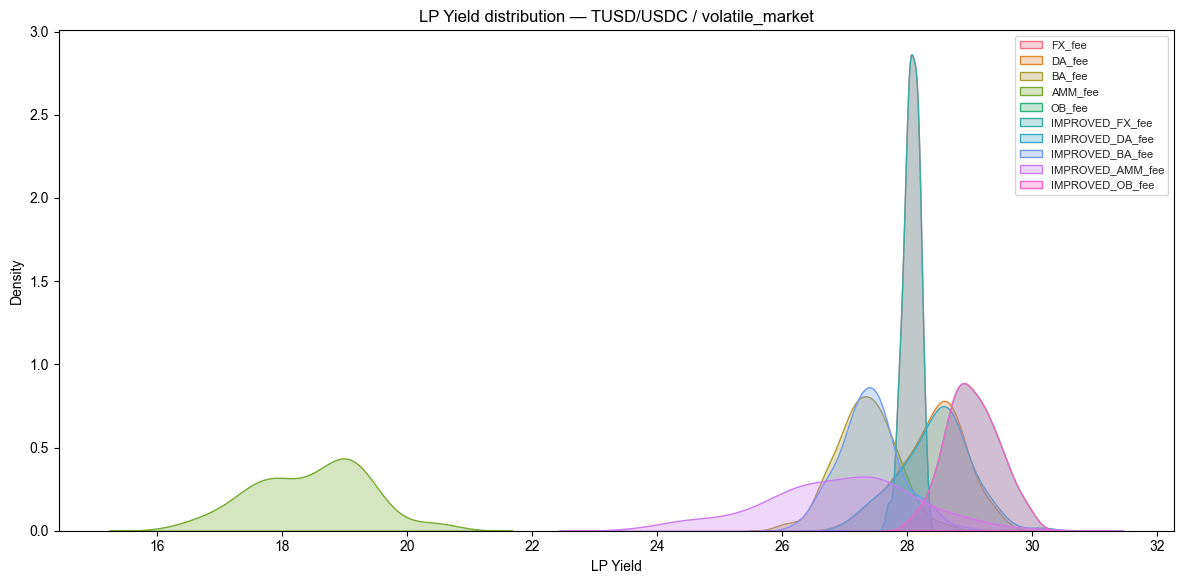

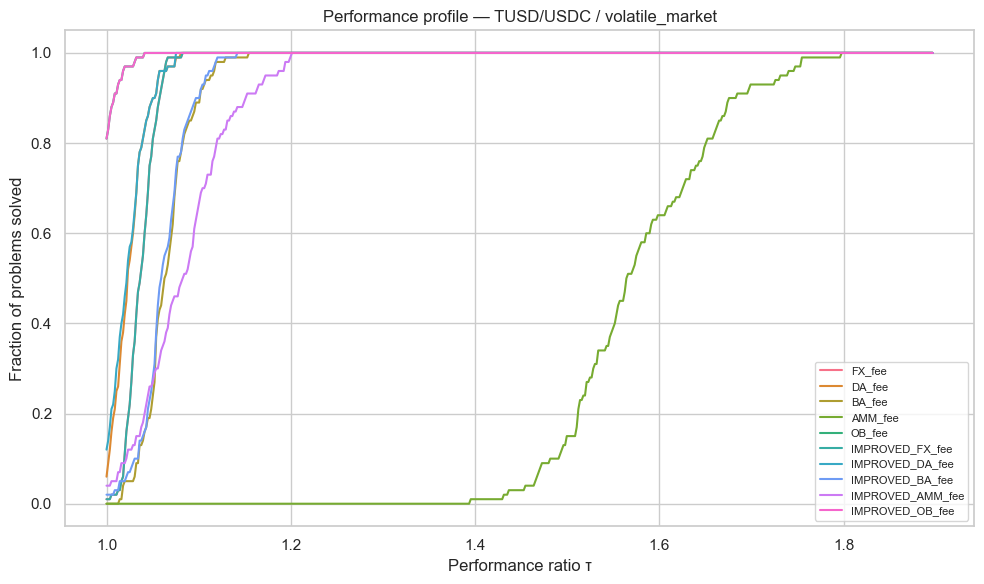

In [18]:
show_stats_for_pair_alias("TUSD/USDC", "volatile_market")
plot_yield_stats("TUSD/USDC", "volatile_market")
plot_performance_profile("TUSD/USDC", "volatile_market")

##### bull_market


=== TUSD/USDC / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,48.04 ± 8.03,53.70 ± 6.24,1.05 ± 0.14,-8163.01 ± 306.21,722.09 ± 23.89,-56.67 ± 1.19,3829.47 ± 199.27,20.16 ± 1.03,-4193.14 ± 375.88
BA_fee,12.21 ± 5.01,14.95 ± 4.81,0.95 ± 0.22,-8167.55 ± 289.27,723.01 ± 24.45,-56.61 ± 0.68,4286.91 ± 155.43,27.31 ± 0.41,-4456.36 ± 270.98
DA_fee,6.71 ± 4.52,9.84 ± 4.66,0.77 ± 0.26,-8174.24 ± 294.18,722.83 ± 24.52,-56.68 ± 0.73,4362.30 ± 179.53,28.60 ± 0.38,-4480.84 ± 378.05
FX_fee,9.56 ± 4.61,11.56 ± 4.56,0.95 ± 0.25,-8175.80 ± 288.24,723.50 ± 24.50,-56.63 ± 0.74,4339.95 ± 155.37,28.14 ± 0.13,-4476.32 ± 323.55
IMPROVED_AMM_fee,0.53 ± 0.78,2.39 ± 1.21,0.06 ± 0.12,-8220.02 ± 320.40,722.38 ± 23.34,-57.04 ± 1.34,4160.87 ± 209.34,27.08 ± 1.33,-4555.06 ± 414.85
IMPROVED_BA_fee,11.34 ± 5.09,14.09 ± 4.64,0.89 ± 0.24,-8176.05 ± 294.40,723.13 ± 24.44,-56.66 ± 0.79,4291.73 ± 157.77,27.37 ± 0.42,-4468.57 ± 286.35
IMPROVED_DA_fee,6.66 ± 4.52,9.80 ± 4.66,0.77 ± 0.26,-8176.96 ± 294.77,722.79 ± 24.53,-56.70 ± 0.73,4365.37 ± 179.51,28.63 ± 0.38,-4488.78 ± 364.98
IMPROVED_FX_fee,9.56 ± 4.61,11.56 ± 4.56,0.95 ± 0.25,-8175.80 ± 288.24,723.50 ± 24.50,-56.63 ± 0.74,4339.95 ± 155.37,28.14 ± 0.13,-4476.32 ± 323.55
IMPROVED_OB_fee,6.46 ± 4.28,8.14 ± 4.53,0.91 ± 0.41,-8179.77 ± 287.74,723.32 ± 24.19,-56.67 ± 0.65,4378.63 ± 172.20,28.95 ± 0.40,-4510.85 ± 299.78


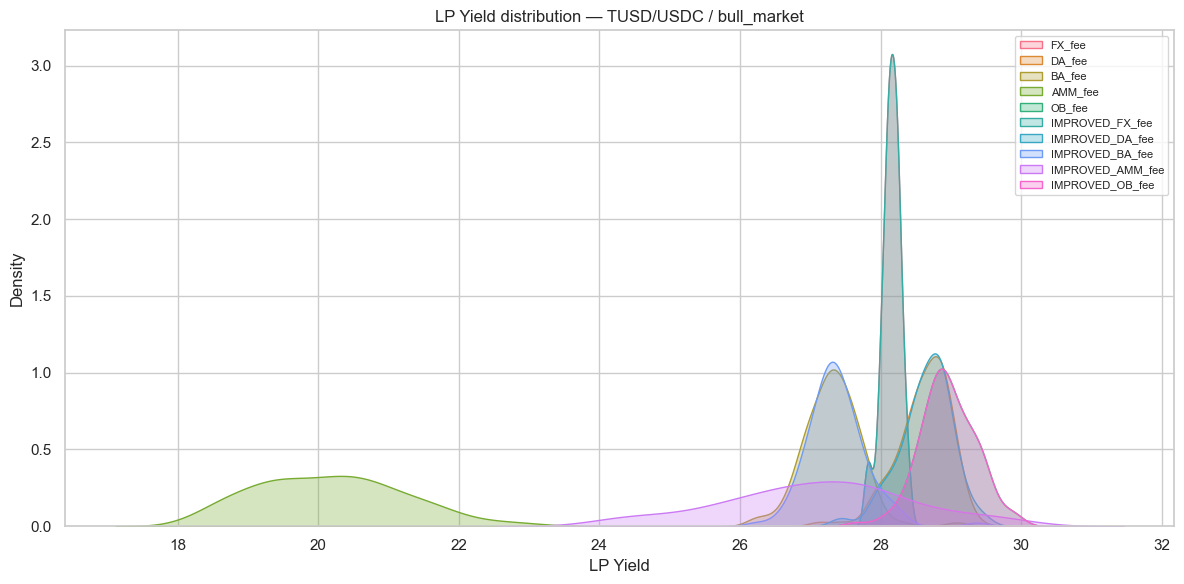

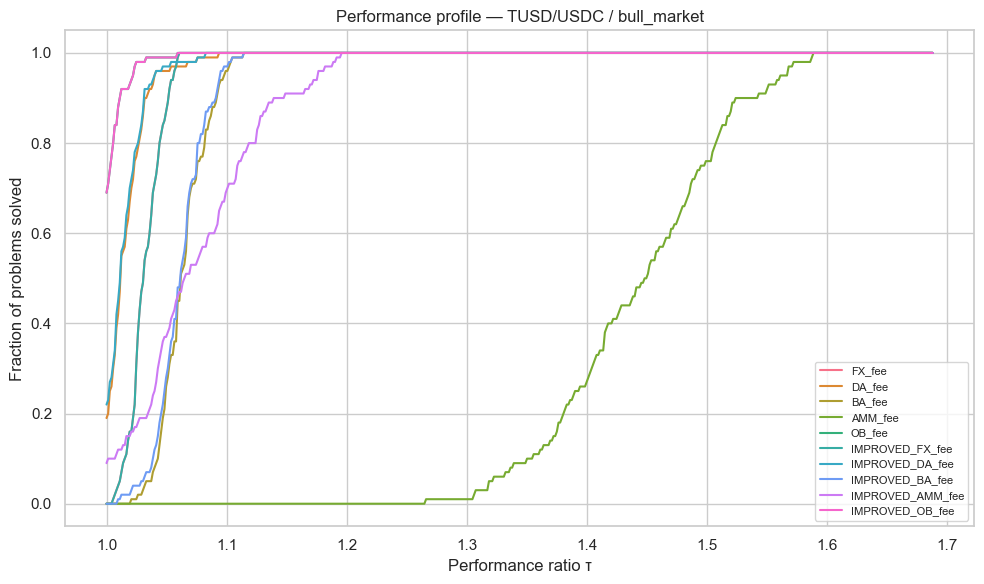

In [19]:
show_stats_for_pair_alias("TUSD/USDC", "bull_market")
plot_yield_stats("TUSD/USDC", "bull_market")
plot_performance_profile("TUSD/USDC", "bull_market")

##### calm_market


=== TUSD/USDC / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,48.80 ± 8.55,54.17 ± 6.62,1.05 ± 0.14,-8172.87 ± 316.46,722.13 ± 24.28,-56.77 ± 1.21,3833.31 ± 198.90,20.15 ± 0.96,-4229.46 ± 309.65
BA_fee,12.20 ± 4.96,14.77 ± 4.31,0.96 ± 0.22,-8174.44 ± 295.65,723.74 ± 24.85,-56.64 ± 0.72,4283.48 ± 156.20,27.30 ± 0.37,-4472.02 ± 233.22
DA_fee,6.75 ± 3.89,9.81 ± 4.51,0.81 ± 0.33,-8173.12 ± 294.83,723.18 ± 24.72,-56.68 ± 0.70,4355.49 ± 178.22,28.57 ± 0.46,-4491.62 ± 303.89
FX_fee,9.43 ± 4.57,11.55 ± 4.65,0.98 ± 0.33,-8174.78 ± 299.06,723.59 ± 24.76,-56.66 ± 0.72,4337.85 ± 160.09,28.15 ± 0.13,-4496.55 ± 254.89
IMPROVED_AMM_fee,0.40 ± 0.53,2.30 ± 1.34,0.07 ± 0.21,-8199.99 ± 353.99,722.66 ± 24.01,-56.92 ± 1.61,4160.06 ± 203.49,27.16 ± 1.28,-4574.67 ± 335.48
IMPROVED_BA_fee,10.87 ± 4.89,13.91 ± 4.15,0.87 ± 0.25,-8178.14 ± 294.14,723.64 ± 24.54,-56.68 ± 0.81,4288.21 ± 158.36,27.38 ± 0.41,-4480.83 ± 248.01
IMPROVED_DA_fee,6.74 ± 3.90,9.80 ± 4.52,0.81 ± 0.33,-8176.07 ± 295.55,723.18 ± 24.71,-56.70 ± 0.71,4358.55 ± 179.18,28.59 ± 0.47,-4496.06 ± 299.86
IMPROVED_FX_fee,9.43 ± 4.57,11.55 ± 4.65,0.98 ± 0.33,-8174.78 ± 299.06,723.59 ± 24.76,-56.66 ± 0.72,4337.85 ± 160.09,28.15 ± 0.13,-4496.55 ± 254.89
IMPROVED_OB_fee,6.67 ± 4.06,8.17 ± 4.41,0.94 ± 0.35,-8188.43 ± 291.44,723.57 ± 24.60,-56.75 ± 0.67,4383.27 ± 176.55,28.98 ± 0.44,-4533.73 ± 240.81


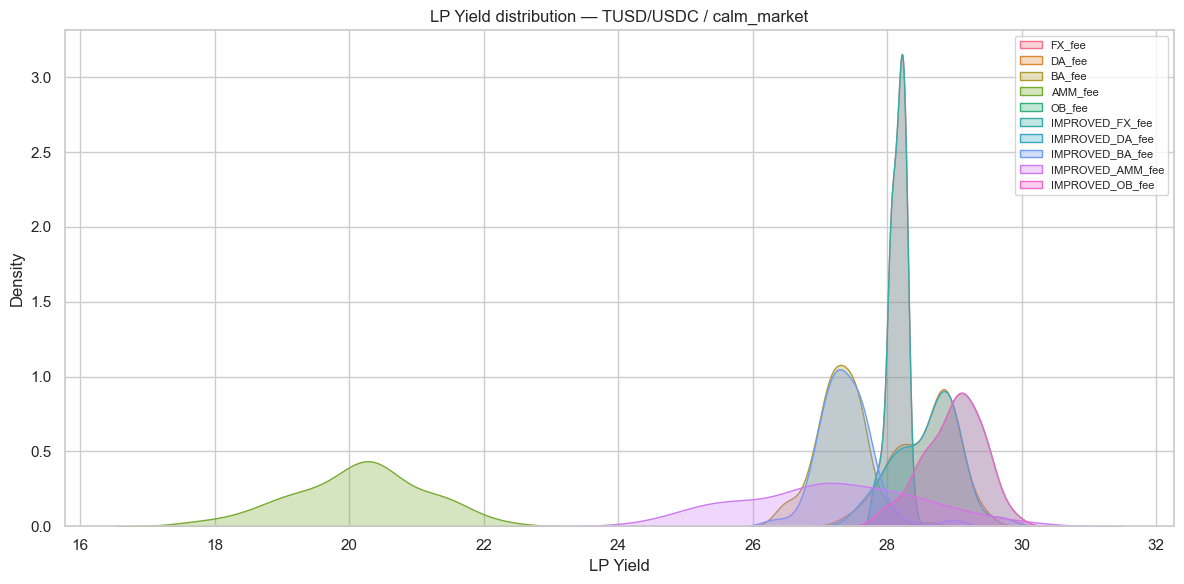

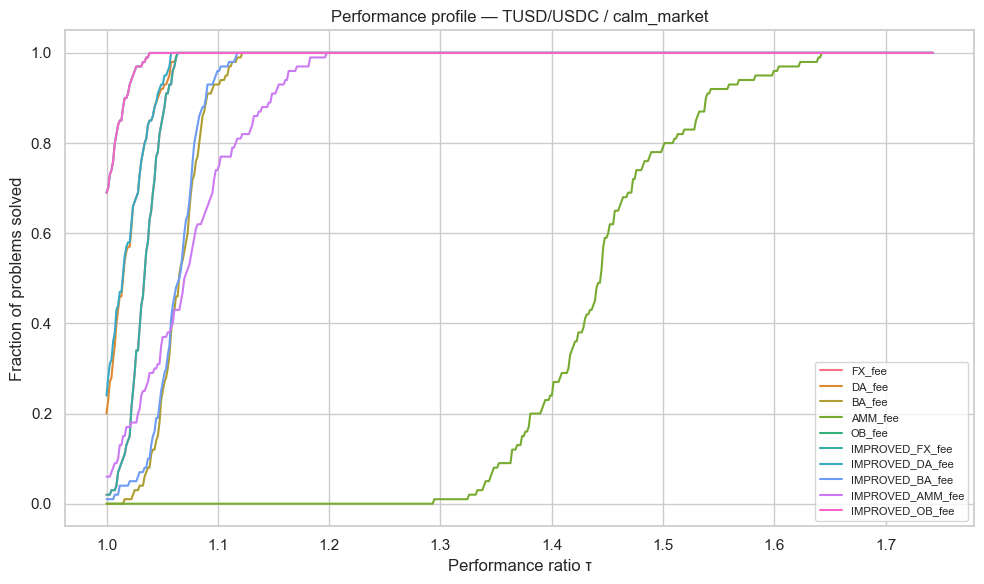

In [20]:
show_stats_for_pair_alias("TUSD/USDC", "calm_market")
plot_yield_stats("TUSD/USDC", "calm_market")
plot_performance_profile("TUSD/USDC", "calm_market")

##### bear_market


=== TUSD/USDC / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,53.74 ± 9.26,57.66 ± 6.14,1.09 ± 0.16,-8189.80 ± 311.23,722.53 ± 24.60,-56.87 ± 1.07,3824.76 ± 195.08,19.78 ± 0.94,-4231.29 ± 331.17
BA_fee,12.90 ± 4.95,15.50 ± 5.03,0.98 ± 0.22,-8173.49 ± 301.56,723.54 ± 24.98,-56.67 ± 0.75,4293.37 ± 161.10,27.27 ± 0.39,-4477.24 ± 249.82
DA_fee,7.26 ± 3.95,10.26 ± 4.66,0.83 ± 0.27,-8171.90 ± 288.22,723.39 ± 24.48,-56.67 ± 0.72,4367.55 ± 175.73,28.57 ± 0.43,-4493.20 ± 327.61
FX_fee,9.43 ± 4.11,12.03 ± 4.53,0.93 ± 0.27,-8173.04 ± 292.46,723.29 ± 24.49,-56.68 ± 0.68,4344.63 ± 155.22,28.14 ± 0.12,-4496.12 ± 276.42
IMPROVED_AMM_fee,0.41 ± 0.59,2.34 ± 1.46,0.04 ± 0.07,-8198.08 ± 348.27,722.80 ± 24.08,-56.91 ± 1.61,4157.77 ± 206.10,27.12 ± 1.25,-4546.46 ± 381.29
IMPROVED_BA_fee,11.92 ± 4.82,14.59 ± 4.85,0.93 ± 0.26,-8178.21 ± 301.01,723.48 ± 24.59,-56.71 ± 0.84,4296.84 ± 161.96,27.34 ± 0.41,-4484.99 ± 257.14
IMPROVED_DA_fee,7.23 ± 3.94,10.22 ± 4.62,0.83 ± 0.27,-8175.02 ± 289.26,723.40 ± 24.48,-56.69 ± 0.72,4370.91 ± 176.89,28.60 ± 0.44,-4497.98 ± 324.90
IMPROVED_FX_fee,9.43 ± 4.11,12.03 ± 4.53,0.93 ± 0.27,-8173.04 ± 292.46,723.29 ± 24.49,-56.68 ± 0.68,4344.63 ± 155.22,28.14 ± 0.12,-4496.12 ± 276.42
IMPROVED_OB_fee,6.64 ± 4.08,8.51 ± 4.68,0.92 ± 0.35,-8182.66 ± 287.60,723.70 ± 24.82,-56.72 ± 0.64,4392.57 ± 173.36,29.00 ± 0.45,-4533.95 ± 258.17


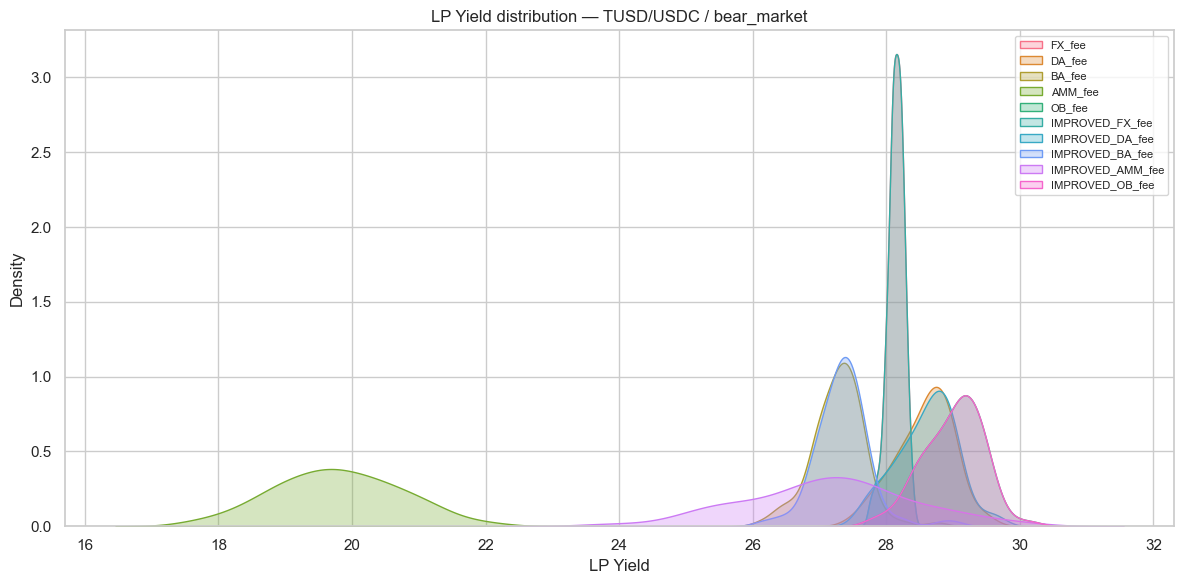

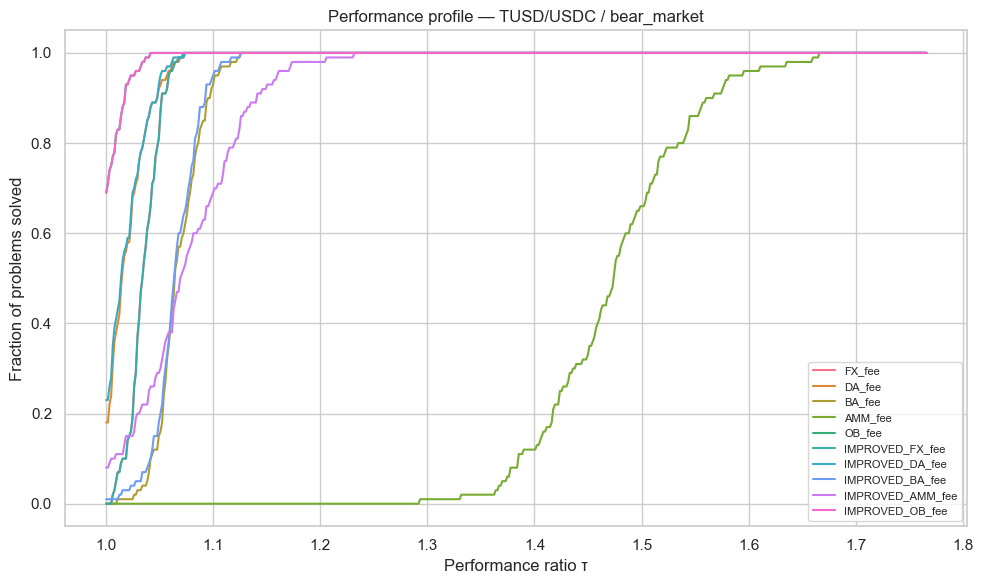

In [21]:
show_stats_for_pair_alias("TUSD/USDC", "bear_market")
plot_yield_stats("TUSD/USDC", "bear_market")
plot_performance_profile("TUSD/USDC", "bear_market")

#### TUSD/USDP

##### volatile_market


=== TUSD/USDP / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,51.79 ± 8.81,57.24 ± 6.98,1.06 ± 0.16,-8174.78 ± 300.81,723.19 ± 23.87,-56.71 ± 1.16,3813.69 ± 190.51,19.75 ± 0.93,-4208.17 ± 296.91
BA_fee,12.65 ± 5.07,15.47 ± 4.67,0.96 ± 0.23,-8177.43 ± 286.81,723.37 ± 24.81,-56.71 ± 0.75,4301.79 ± 161.87,27.34 ± 0.40,-4483.89 ± 217.29
DA_fee,7.41 ± 4.04,10.04 ± 4.08,0.87 ± 0.28,-8179.01 ± 275.29,723.08 ± 24.04,-56.74 ± 0.70,4351.89 ± 172.92,28.51 ± 0.47,-4452.07 ± 309.29
FX_fee,9.15 ± 3.98,11.63 ± 4.29,0.93 ± 0.25,-8169.00 ± 278.32,723.06 ± 24.43,-56.67 ± 0.75,4335.14 ± 152.09,28.15 ± 0.11,-4467.75 ± 248.68
IMPROVED_AMM_fee,0.50 ± 0.83,2.29 ± 1.25,0.10 ± 0.37,-8204.19 ± 335.66,721.91 ± 23.57,-57.02 ± 1.57,4161.68 ± 197.40,27.25 ± 1.29,-4525.88 ± 354.93
IMPROVED_BA_fee,11.64 ± 4.77,14.57 ± 4.42,0.91 ± 0.25,-8179.04 ± 290.63,723.29 ± 24.89,-56.73 ± 0.81,4303.67 ± 163.23,27.41 ± 0.44,-4481.30 ± 229.76
IMPROVED_DA_fee,7.31 ± 3.98,9.99 ± 4.09,0.86 ± 0.28,-8180.31 ± 275.30,723.07 ± 24.05,-56.75 ± 0.71,4353.92 ± 173.28,28.53 ± 0.49,-4454.87 ± 309.79
IMPROVED_FX_fee,9.15 ± 3.98,11.63 ± 4.29,0.93 ± 0.25,-8169.00 ± 278.32,723.06 ± 24.43,-56.67 ± 0.75,4335.14 ± 152.09,28.15 ± 0.11,-4467.75 ± 248.68
IMPROVED_OB_fee,6.36 ± 4.00,7.89 ± 4.01,0.90 ± 0.40,-8169.29 ± 293.39,723.14 ± 24.93,-56.67 ± 0.60,4362.72 ± 180.74,28.92 ± 0.44,-4492.39 ± 250.58


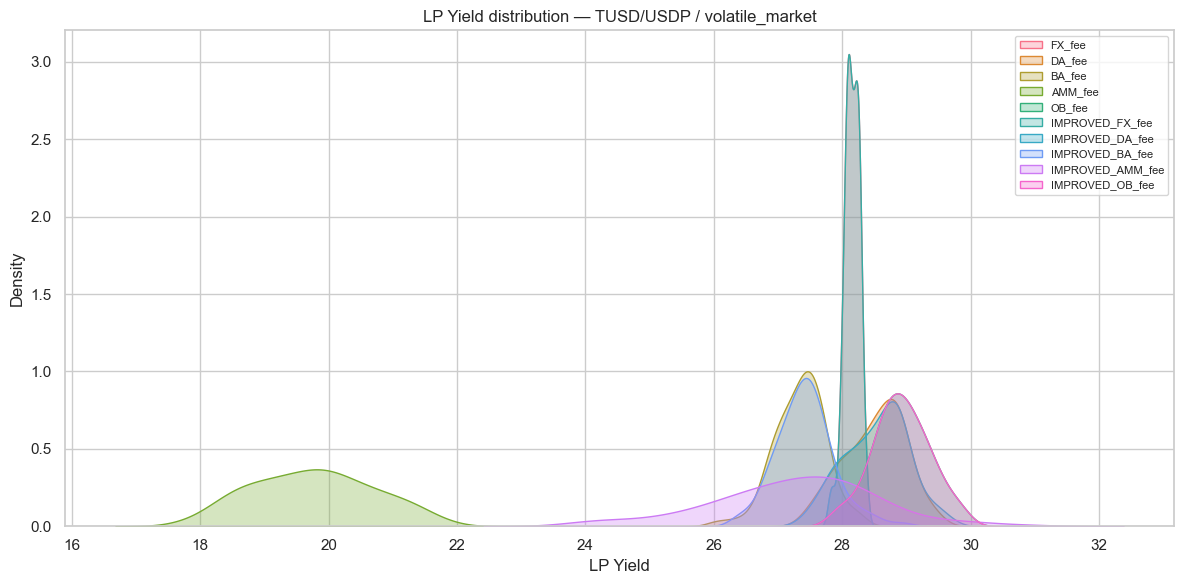

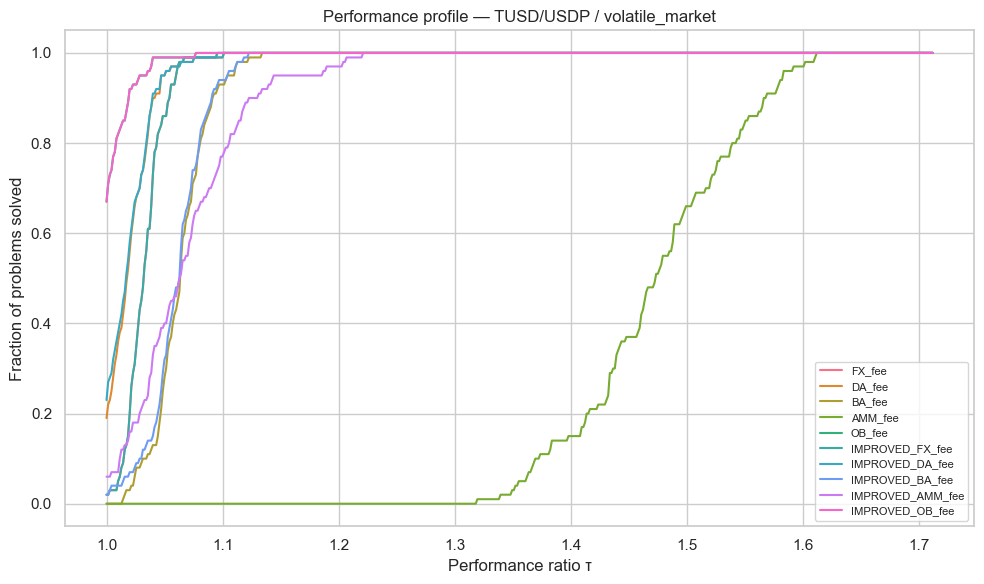

In [22]:
show_stats_for_pair_alias("TUSD/USDP", "volatile_market")
plot_yield_stats("TUSD/USDP", "volatile_market")
plot_performance_profile("TUSD/USDP", "volatile_market")

##### bull_market


=== TUSD/USDP / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,34.09 ± 6.74,39.52 ± 5.08,1.01 ± 0.14,-8173.34 ± 316.84,723.09 ± 24.75,-56.67 ± 1.18,3906.58 ± 197.40,21.95 ± 0.93,-4280.73 ± 230.43
BA_fee,9.84 ± 3.92,11.75 ± 4.10,0.98 ± 0.28,-8173.41 ± 285.87,723.36 ± 24.52,-56.63 ± 0.74,4229.07 ± 151.05,27.40 ± 0.32,-4461.27 ± 170.80
DA_fee,4.30 ± 3.36,6.51 ± 3.53,0.73 ± 0.31,-8185.08 ± 294.82,723.01 ± 24.58,-56.74 ± 0.72,4294.67 ± 168.68,28.68 ± 0.29,-4484.11 ± 235.83
FX_fee,7.16 ± 3.63,8.05 ± 3.45,1.04 ± 0.35,-8166.39 ± 284.78,722.69 ± 24.09,-56.64 ± 0.73,4266.19 ± 151.19,28.24 ± 0.10,-4472.40 ± 189.07
IMPROVED_AMM_fee,0.17 ± 0.29,1.34 ± 0.98,0.03 ± 0.09,-8189.10 ± 332.55,722.17 ± 24.05,-56.84 ± 1.54,4143.05 ± 201.05,27.63 ± 1.17,-4493.15 ± 293.66
IMPROVED_BA_fee,9.02 ± 3.40,10.88 ± 3.50,0.95 ± 0.29,-8175.36 ± 290.93,723.53 ± 24.53,-56.63 ± 0.78,4230.80 ± 153.37,27.47 ± 0.33,-4465.21 ± 179.98
IMPROVED_DA_fee,4.27 ± 3.38,6.46 ± 3.55,0.73 ± 0.32,-8187.42 ± 296.95,722.94 ± 24.60,-56.76 ± 0.74,4298.26 ± 169.66,28.72 ± 0.31,-4489.59 ± 234.25
IMPROVED_FX_fee,7.16 ± 3.63,8.05 ± 3.45,1.04 ± 0.35,-8166.39 ± 284.78,722.69 ± 24.09,-56.64 ± 0.73,4266.19 ± 151.19,28.24 ± 0.10,-4472.40 ± 189.07
IMPROVED_OB_fee,4.51 ± 3.45,5.41 ± 3.40,0.95 ± 0.48,-8182.74 ± 295.68,723.61 ± 24.36,-56.67 ± 0.66,4297.00 ± 172.61,28.84 ± 0.42,-4491.67 ± 224.03


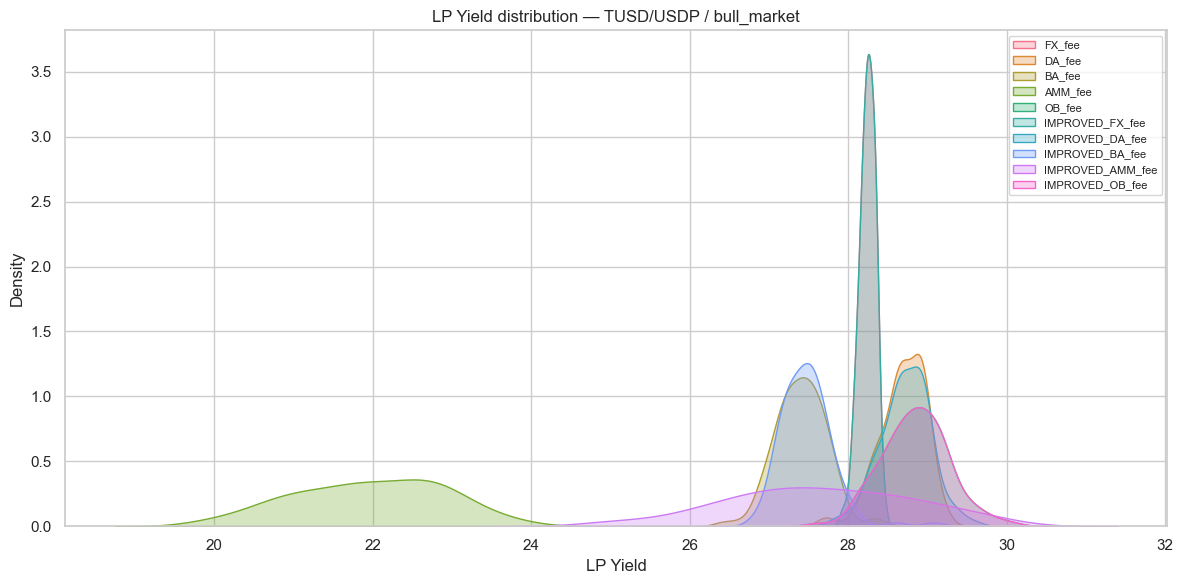

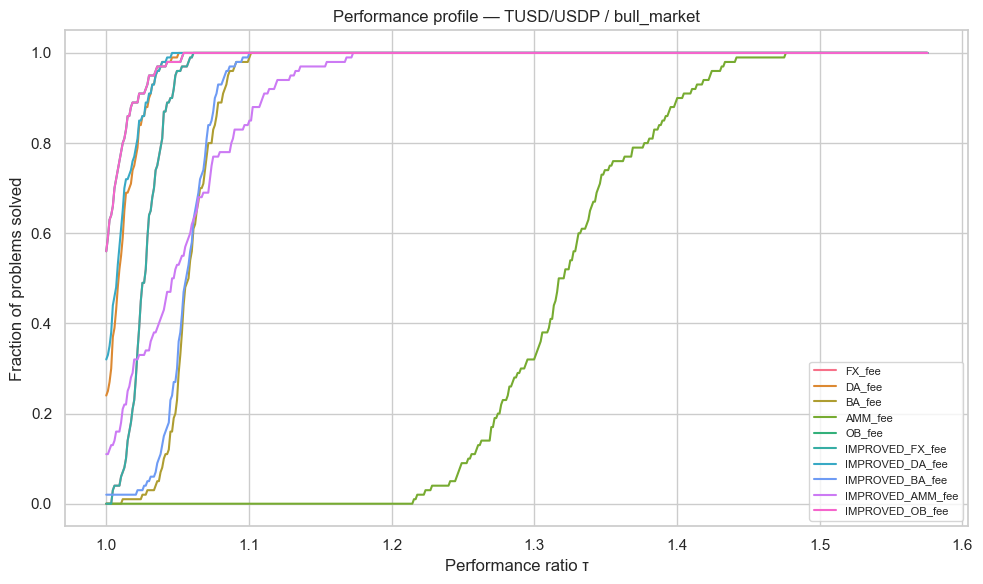

In [23]:
show_stats_for_pair_alias("TUSD/USDP", "bull_market")
plot_yield_stats("TUSD/USDP", "bull_market")
plot_performance_profile("TUSD/USDP", "bull_market")

##### calm_market


=== TUSD/USDP / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,761.73 ± 113.08,196.53 ± 10.48,3.84 ± 0.46,-8209.71 ± 309.01,723.15 ± 24.32,-56.96 ± 1.16,2578.82 ± 252.64,7.56 ± 0.84,-2793.97 ± 2567.81
BA_fee,89.69 ± 19.56,57.83 ± 10.11,1.72 ± 0.18,-8171.88 ± 307.64,722.82 ± 25.10,-56.72 ± 0.82,5263.30 ± 343.38,26.83 ± 1.01,-4348.63 ± 2084.40
DA_fee,85.85 ± 19.56,57.22 ± 10.47,1.67 ± 0.21,-8182.02 ± 295.52,722.95 ± 24.70,-56.78 ± 0.76,5265.68 ± 321.40,26.95 ± 1.06,-4018.49 ± 2712.20
FX_fee,85.27 ± 18.09,56.85 ± 9.82,1.67 ± 0.20,-8171.33 ± 303.02,722.91 ± 24.53,-56.70 ± 0.75,5266.78 ± 252.98,27.00 ± 0.19,-4161.20 ± 2416.01
IMPROVED_AMM_fee,10.35 ± 5.93,14.32 ± 3.96,0.24 ± 0.13,-8203.70 ± 346.11,722.65 ± 24.51,-56.95 ± 1.48,4406.92 ± 245.49,23.40 ± 1.59,-4354.30 ± 2566.30
IMPROVED_BA_fee,82.33 ± 17.92,54.72 ± 9.57,1.61 ± 0.22,-8179.54 ± 306.39,722.60 ± 25.15,-56.79 ± 0.84,5261.39 ± 334.88,26.97 ± 1.12,-4368.05 ± 2112.26
IMPROVED_DA_fee,103.60 ± 95.40,54.21 ± 11.91,2.21 ± 2.38,-8182.95 ± 307.98,722.70 ± 24.69,-56.80 ± 0.96,5236.56 ± 329.86,27.11 ± 1.02,-4075.67 ± 2504.67
IMPROVED_FX_fee,85.27 ± 18.09,56.85 ± 9.82,1.67 ± 0.20,-8171.33 ± 303.02,722.91 ± 24.53,-56.70 ± 0.75,5266.78 ± 252.98,27.00 ± 0.19,-4161.20 ± 2416.01
IMPROVED_OB_fee,60.36 ± 18.19,40.23 ± 10.55,1.67 ± 0.23,-8181.06 ± 301.83,723.48 ± 25.07,-56.72 ± 0.66,5476.68 ± 375.47,30.35 ± 0.49,-4303.91 ± 2358.33


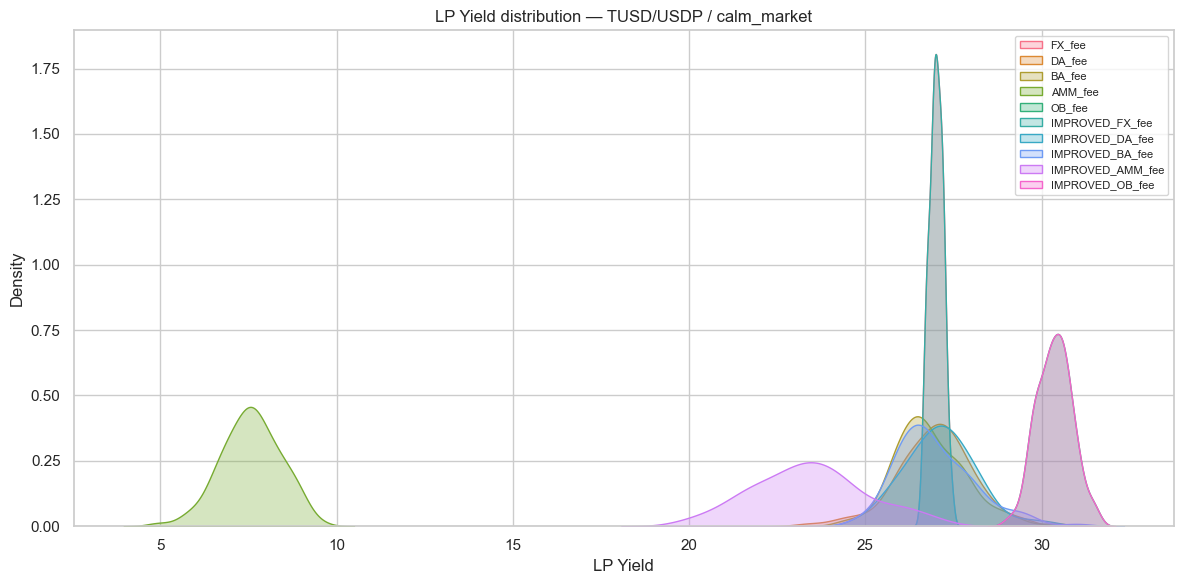

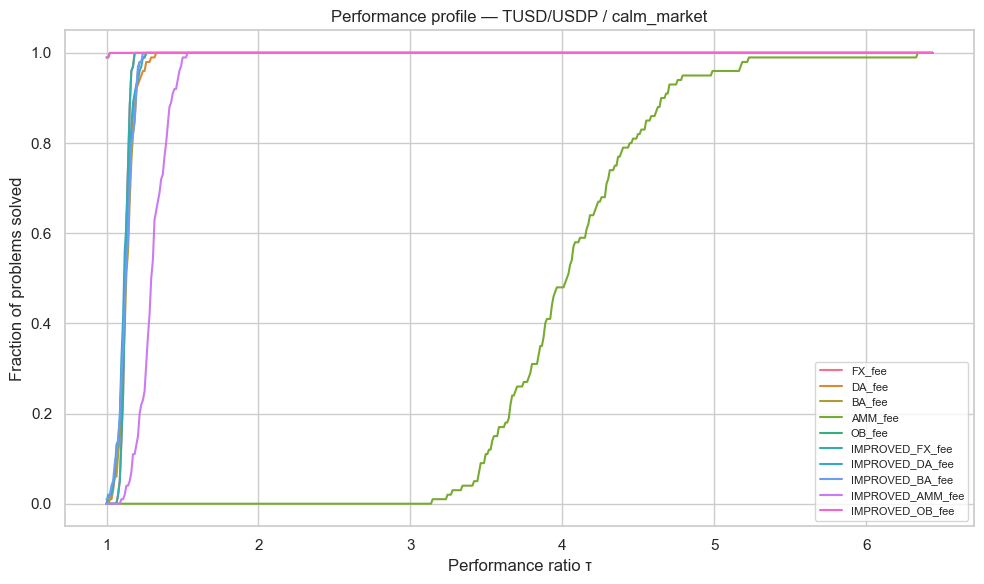

In [24]:
show_stats_for_pair_alias("TUSD/USDP", "calm_market")
plot_yield_stats("TUSD/USDP", "calm_market")
plot_performance_profile("TUSD/USDP", "calm_market")

##### bear_market


=== TUSD/USDP / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,37.98 ± 7.37,45.35 ± 5.56,0.98 ± 0.14,-8155.84 ± 315.45,722.45 ± 23.89,-56.65 ± 1.13,3865.56 ± 195.57,21.18 ± 0.90,-4274.84 ± 233.89
BA_fee,10.17 ± 4.52,13.00 ± 4.07,0.91 ± 0.27,-8172.94 ± 286.40,723.29 ± 24.65,-56.70 ± 0.70,4245.66 ± 152.84,27.36 ± 0.31,-4480.26 ± 173.42
DA_fee,5.05 ± 3.33,7.38 ± 3.77,0.79 ± 0.33,-8174.61 ± 293.84,723.21 ± 25.19,-56.72 ± 0.72,4301.43 ± 172.51,28.61 ± 0.39,-4479.06 ± 228.74
FX_fee,7.07 ± 3.89,8.99 ± 3.72,0.94 ± 0.39,-8163.64 ± 283.40,723.07 ± 24.47,-56.65 ± 0.74,4281.96 ± 148.62,28.22 ± 0.11,-4480.10 ± 185.01
IMPROVED_AMM_fee,0.31 ± 0.50,1.76 ± 1.15,0.04 ± 0.07,-8213.03 ± 339.06,722.69 ± 23.71,-57.03 ± 1.45,4150.69 ± 200.88,27.47 ± 1.20,-4524.05 ± 306.69
IMPROVED_BA_fee,9.20 ± 4.05,12.18 ± 3.69,0.86 ± 0.26,-8175.99 ± 291.39,723.26 ± 24.56,-56.73 ± 0.79,4249.03 ± 155.84,27.44 ± 0.35,-4482.49 ± 186.23
IMPROVED_DA_fee,5.02 ± 3.34,7.35 ± 3.76,0.79 ± 0.33,-8176.92 ± 295.74,723.18 ± 25.19,-56.74 ± 0.75,4304.69 ± 174.78,28.64 ± 0.42,-4482.42 ± 230.51
IMPROVED_FX_fee,7.07 ± 3.89,8.99 ± 3.72,0.94 ± 0.39,-8163.64 ± 283.40,723.07 ± 24.47,-56.65 ± 0.74,4281.96 ± 148.62,28.22 ± 0.11,-4480.10 ± 185.01
IMPROVED_OB_fee,4.64 ± 3.19,6.04 ± 3.53,0.91 ± 0.45,-8178.27 ± 296.49,723.48 ± 24.81,-56.72 ± 0.63,4313.11 ± 170.15,28.89 ± 0.41,-4501.57 ± 206.58


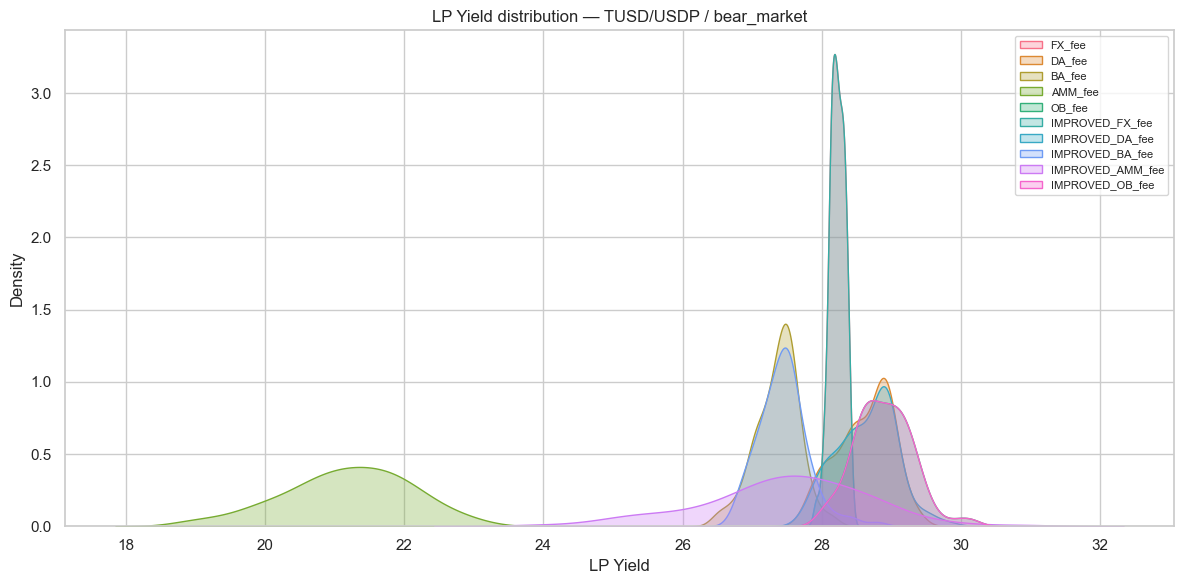

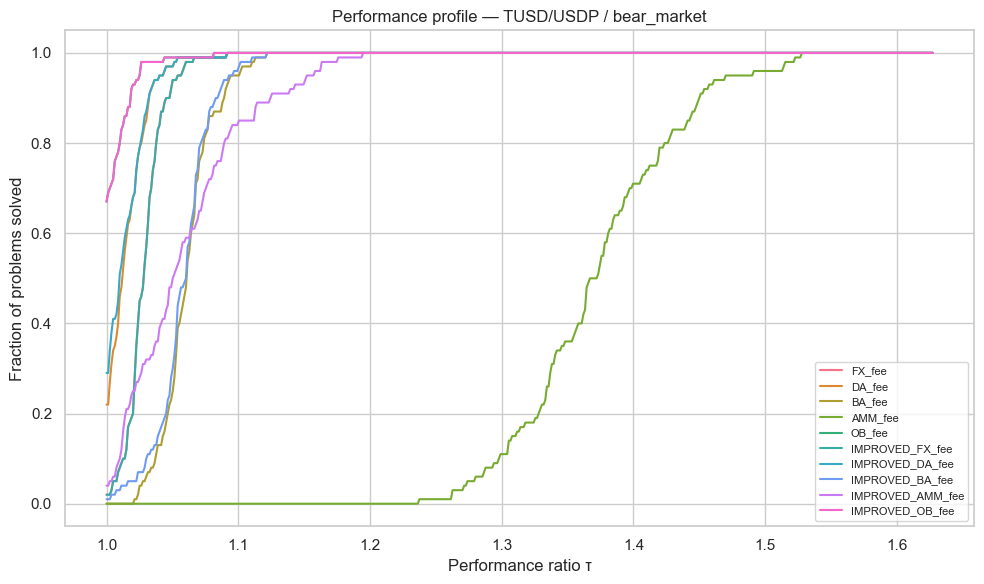

In [25]:
show_stats_for_pair_alias("TUSD/USDP", "bear_market")
plot_yield_stats("TUSD/USDP", "bear_market")
plot_performance_profile("TUSD/USDP", "bear_market")

#### USDC/USDP

##### volatile_market


=== USDC/USDP / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,46.47 ± 8.25,51.86 ± 6.62,1.05 ± 0.16,-8164.93 ± 338.14,722.55 ± 25.05,-56.69 ± 1.23,3833.83 ± 213.95,20.36 ± 0.95,-4237.84 ± 280.93
BA_fee,11.57 ± 4.79,14.35 ± 4.41,0.94 ± 0.23,-8171.49 ± 279.17,723.00 ± 24.50,-56.70 ± 0.74,4274.88 ± 153.72,27.35 ± 0.37,-4479.84 ± 189.25
DA_fee,6.11 ± 3.52,8.87 ± 3.87,0.79 ± 0.27,-8183.31 ± 280.33,723.34 ± 24.39,-56.75 ± 0.69,4331.83 ± 169.38,28.56 ± 0.44,-4469.95 ± 263.34
FX_fee,8.27 ± 3.85,10.53 ± 3.88,0.92 ± 0.31,-8174.51 ± 283.18,723.35 ± 24.59,-56.69 ± 0.74,4314.76 ± 152.58,28.18 ± 0.11,-4478.50 ± 220.88
IMPROVED_AMM_fee,0.44 ± 0.75,2.01 ± 1.23,0.09 ± 0.30,-8195.26 ± 335.54,722.37 ± 23.60,-56.93 ± 1.56,4156.93 ± 196.91,27.40 ± 1.17,-4523.83 ± 351.10
IMPROVED_BA_fee,10.68 ± 4.42,13.46 ± 4.25,0.90 ± 0.24,-8173.55 ± 283.44,723.05 ± 24.43,-56.72 ± 0.78,4278.82 ± 156.14,27.44 ± 0.43,-4477.51 ± 205.34
IMPROVED_DA_fee,6.09 ± 3.53,8.83 ± 3.88,0.79 ± 0.27,-8185.80 ± 281.64,723.32 ± 24.40,-56.77 ± 0.71,4334.95 ± 171.25,28.59 ± 0.47,-4473.62 ± 265.50
IMPROVED_FX_fee,8.27 ± 3.85,10.53 ± 3.88,0.92 ± 0.31,-8174.51 ± 283.18,723.35 ± 24.59,-56.69 ± 0.74,4314.76 ± 152.58,28.18 ± 0.11,-4478.50 ± 220.88
IMPROVED_OB_fee,5.39 ± 3.86,7.11 ± 3.85,0.85 ± 0.43,-8180.38 ± 290.33,723.62 ± 24.53,-56.71 ± 0.66,4343.93 ± 175.50,28.91 ± 0.44,-4497.23 ± 227.80


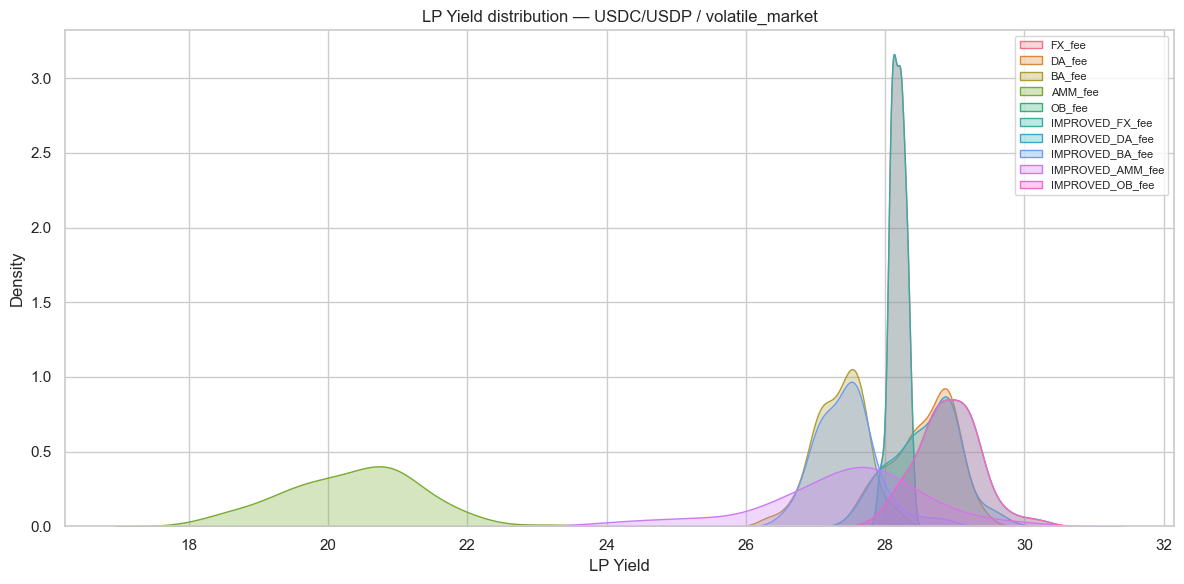

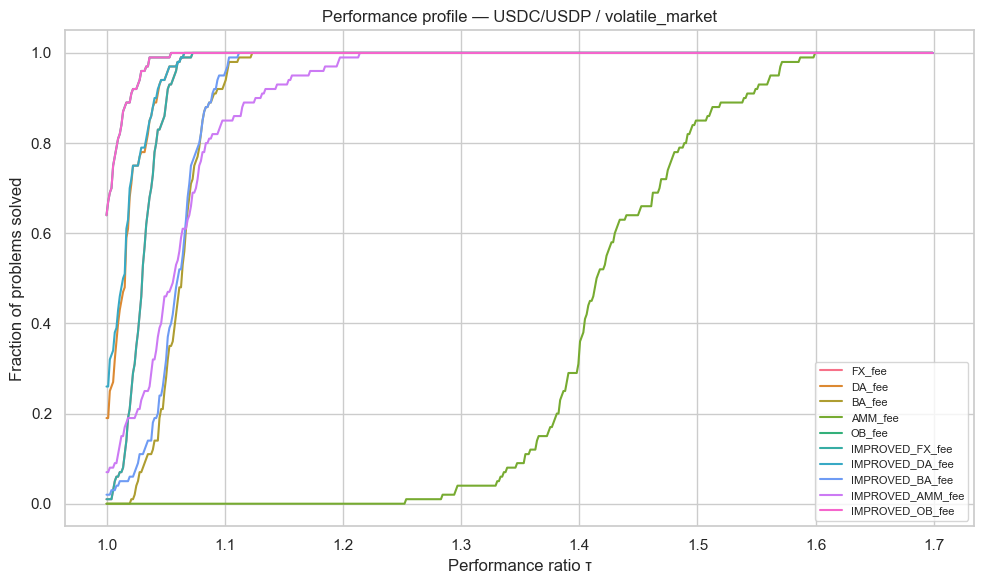

In [26]:
show_stats_for_pair_alias("USDC/USDP", "volatile_market")
plot_yield_stats("USDC/USDP", "volatile_market")
plot_performance_profile("USDC/USDP", "volatile_market")

##### bull_market


=== USDC/USDP / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,41.76 ± 8.97,48.95 ± 5.69,1.00 ± 0.16,-8142.10 ± 322.40,722.55 ± 24.76,-56.54 ± 1.24,3832.58 ± 205.64,20.64 ± 1.03,-4232.35 ± 254.49
BA_fee,10.39 ± 4.30,13.62 ± 4.35,0.90 ± 0.24,-8170.05 ± 279.25,723.18 ± 24.32,-56.69 ± 0.72,4261.15 ± 147.97,27.38 ± 0.35,-4473.63 ± 184.27
DA_fee,5.62 ± 3.23,8.20 ± 3.83,0.79 ± 0.30,-8172.71 ± 293.68,722.85 ± 24.73,-56.73 ± 0.70,4314.50 ± 172.02,28.58 ± 0.43,-4466.35 ± 246.38
FX_fee,7.66 ± 3.58,9.78 ± 3.88,0.93 ± 0.27,-8167.95 ± 278.97,723.31 ± 24.38,-56.66 ± 0.71,4298.94 ± 149.95,28.20 ± 0.11,-4474.94 ± 201.20
IMPROVED_AMM_fee,0.32 ± 0.58,1.82 ± 1.21,0.04 ± 0.07,-8195.69 ± 335.88,722.29 ± 24.19,-56.95 ± 1.52,4147.29 ± 197.34,27.41 ± 1.23,-4505.31 ± 311.29
IMPROVED_BA_fee,9.55 ± 4.05,12.70 ± 4.10,0.86 ± 0.25,-8170.61 ± 284.66,722.94 ± 24.23,-56.71 ± 0.80,4262.34 ± 150.12,27.45 ± 0.39,-4478.46 ± 194.57
IMPROVED_DA_fee,5.58 ± 3.25,8.16 ± 3.84,0.79 ± 0.30,-8174.69 ± 294.84,722.85 ± 24.73,-56.74 ± 0.71,4317.03 ± 173.23,28.60 ± 0.45,-4469.66 ± 247.61
IMPROVED_FX_fee,7.66 ± 3.58,9.78 ± 3.88,0.93 ± 0.27,-8167.95 ± 278.97,723.31 ± 24.38,-56.66 ± 0.71,4298.94 ± 149.95,28.20 ± 0.11,-4474.94 ± 201.20
IMPROVED_OB_fee,5.59 ± 3.93,6.66 ± 3.52,0.95 ± 0.44,-8176.19 ± 285.87,723.27 ± 24.23,-56.72 ± 0.59,4330.08 ± 165.76,28.90 ± 0.46,-4498.88 ± 210.51


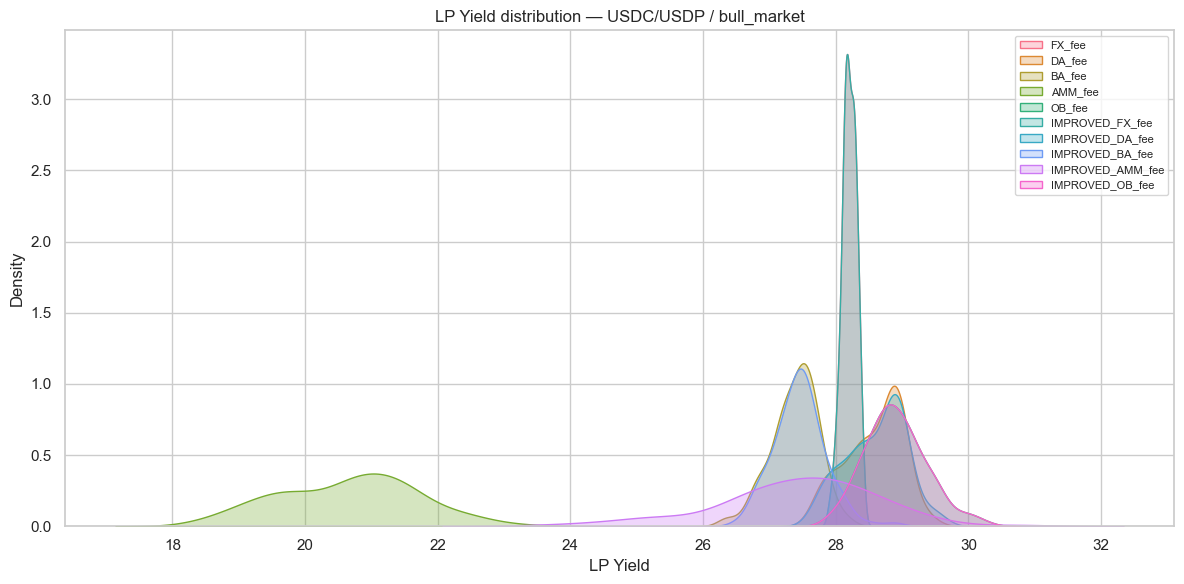

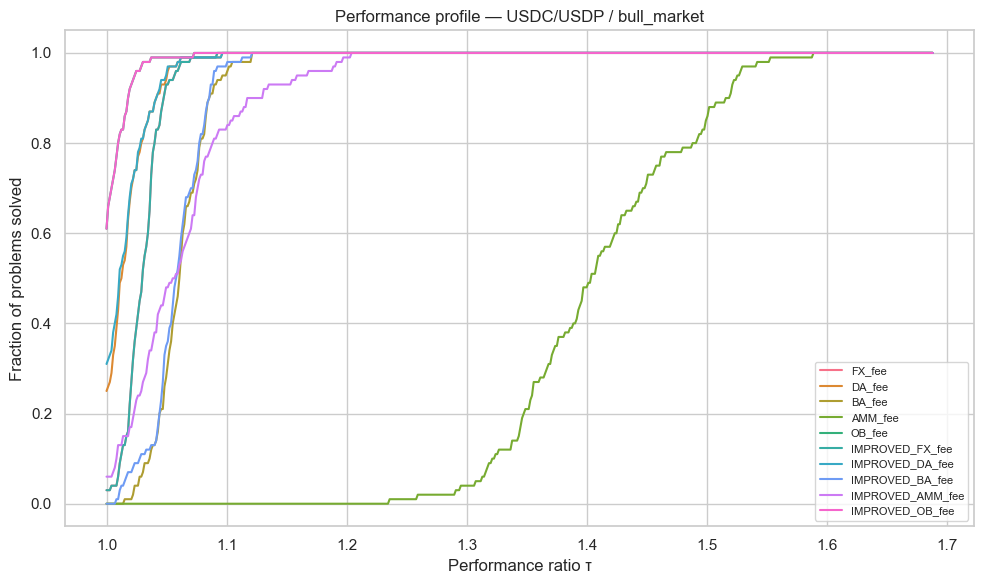

In [27]:
show_stats_for_pair_alias("USDC/USDP", "bull_market")
plot_yield_stats("USDC/USDP", "bull_market")
plot_performance_profile("USDC/USDP", "bull_market")

##### calm_market


=== USDC/USDP / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,788.57 ± 119.09,199.93 ± 11.89,3.90 ± 0.50,-8187.14 ± 330.15,722.22 ± 24.50,-56.85 ± 1.18,2528.22 ± 251.66,7.33 ± 0.81,-2764.91 ± 2656.35
BA_fee,94.40 ± 17.28,58.75 ± 9.29,1.78 ± 0.17,-8169.52 ± 311.48,722.80 ± 25.28,-56.69 ± 0.80,5280.34 ± 336.61,26.77 ± 1.03,-4342.08 ± 2213.51
DA_fee,89.87 ± 21.64,58.23 ± 10.43,1.71 ± 0.21,-8174.54 ± 305.99,722.64 ± 24.82,-56.74 ± 0.80,5289.33 ± 326.01,26.93 ± 1.10,-4012.84 ± 2858.14
FX_fee,91.96 ± 18.98,58.52 ± 9.62,1.74 ± 0.19,-8172.46 ± 305.21,723.26 ± 24.73,-56.67 ± 0.79,5307.63 ± 247.95,26.95 ± 0.19,-4192.29 ± 2563.42
IMPROVED_AMM_fee,11.86 ± 6.83,15.27 ± 4.48,0.26 ± 0.14,-8220.83 ± 374.83,722.43 ± 24.87,-57.08 ± 1.69,4433.06 ± 254.68,23.21 ± 1.59,-4472.70 ± 2647.69
IMPROVED_BA_fee,85.90 ± 17.60,55.57 ± 9.12,1.65 ± 0.23,-8171.44 ± 303.99,722.67 ± 25.06,-56.71 ± 0.81,5278.57 ± 325.65,26.92 ± 1.13,-4356.44 ± 2248.41
IMPROVED_DA_fee,107.20 ± 94.52,55.30 ± 11.62,2.24 ± 2.37,-8177.72 ± 310.62,722.35 ± 24.67,-56.79 ± 0.92,5263.56 ± 329.63,27.07 ± 1.04,-4059.57 ± 2768.22
IMPROVED_FX_fee,91.96 ± 18.98,58.52 ± 9.62,1.74 ± 0.19,-8172.46 ± 305.21,723.26 ± 24.73,-56.67 ± 0.79,5307.63 ± 247.95,26.95 ± 0.19,-4192.29 ± 2563.42
IMPROVED_OB_fee,63.38 ± 19.09,41.51 ± 10.80,1.69 ± 0.20,-8176.86 ± 302.65,723.65 ± 24.90,-56.67 ± 0.69,5521.39 ± 382.20,30.38 ± 0.52,-4312.44 ± 2499.73


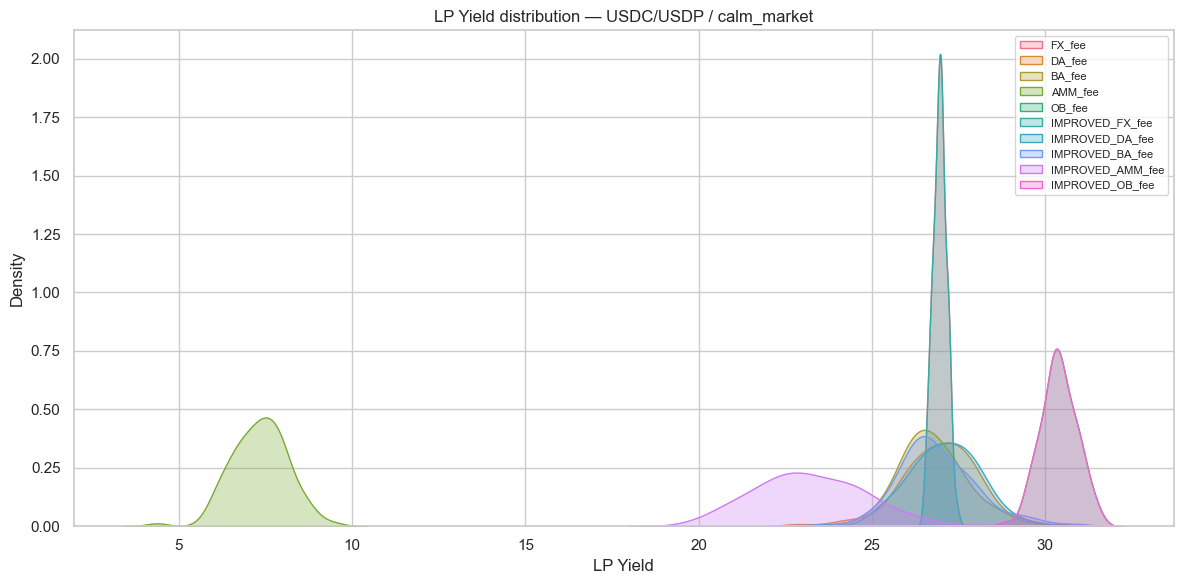

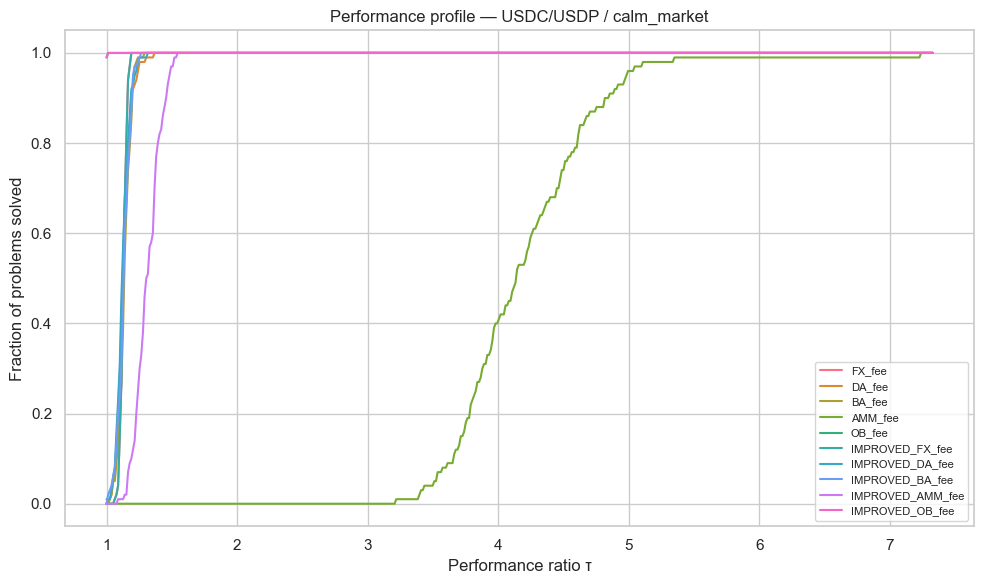

In [28]:
show_stats_for_pair_alias("USDC/USDP", "calm_market")
plot_yield_stats("USDC/USDP", "calm_market")
plot_performance_profile("USDC/USDP", "calm_market")

##### bear_market


=== USDC/USDP / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,42.49 ± 7.60,49.99 ± 5.76,1.00 ± 0.13,-8171.47 ± 313.78,722.93 ± 24.53,-56.72 ± 1.18,3852.35 ± 200.34,20.64 ± 0.96,-4255.93 ± 242.46
BA_fee,11.24 ± 4.51,13.72 ± 4.15,0.96 ± 0.26,-8172.36 ± 273.96,723.32 ± 24.13,-56.69 ± 0.69,4264.14 ± 145.90,27.36 ± 0.35,-4476.81 ± 176.91
DA_fee,5.63 ± 3.35,8.43 ± 3.80,0.76 ± 0.27,-8180.78 ± 292.99,723.20 ± 25.24,-56.76 ± 0.70,4322.21 ± 173.85,28.58 ± 0.41,-4473.99 ± 246.31
FX_fee,8.33 ± 4.14,10.09 ± 3.76,0.96 ± 0.34,-8169.13 ± 283.40,723.14 ± 24.56,-56.68 ± 0.72,4304.59 ± 149.82,28.19 ± 0.11,-4481.48 ± 204.92
IMPROVED_AMM_fee,0.37 ± 0.62,1.92 ± 1.22,0.07 ± 0.20,-8192.75 ± 339.48,722.74 ± 24.09,-56.89 ± 1.49,4156.30 ± 203.91,27.47 ± 1.19,-4507.20 ± 324.05
IMPROVED_BA_fee,10.09 ± 4.04,12.81 ± 3.98,0.90 ± 0.26,-8171.99 ± 278.69,723.07 ± 24.20,-56.71 ± 0.76,4265.29 ± 147.00,27.44 ± 0.40,-4479.92 ± 189.56
IMPROVED_DA_fee,5.58 ± 3.37,8.38 ± 3.80,0.76 ± 0.28,-8182.61 ± 294.16,723.16 ± 25.26,-56.78 ± 0.71,4324.98 ± 175.30,28.61 ± 0.44,-4477.34 ± 247.85
IMPROVED_FX_fee,8.33 ± 4.14,10.09 ± 3.76,0.96 ± 0.34,-8169.13 ± 283.40,723.14 ± 24.56,-56.68 ± 0.72,4304.59 ± 149.82,28.19 ± 0.11,-4481.48 ± 204.92
IMPROVED_OB_fee,5.71 ± 4.32,6.78 ± 3.72,0.91 ± 0.37,-8183.21 ± 293.55,723.58 ± 24.48,-56.74 ± 0.65,4335.76 ± 173.73,28.91 ± 0.42,-4504.94 ± 223.20


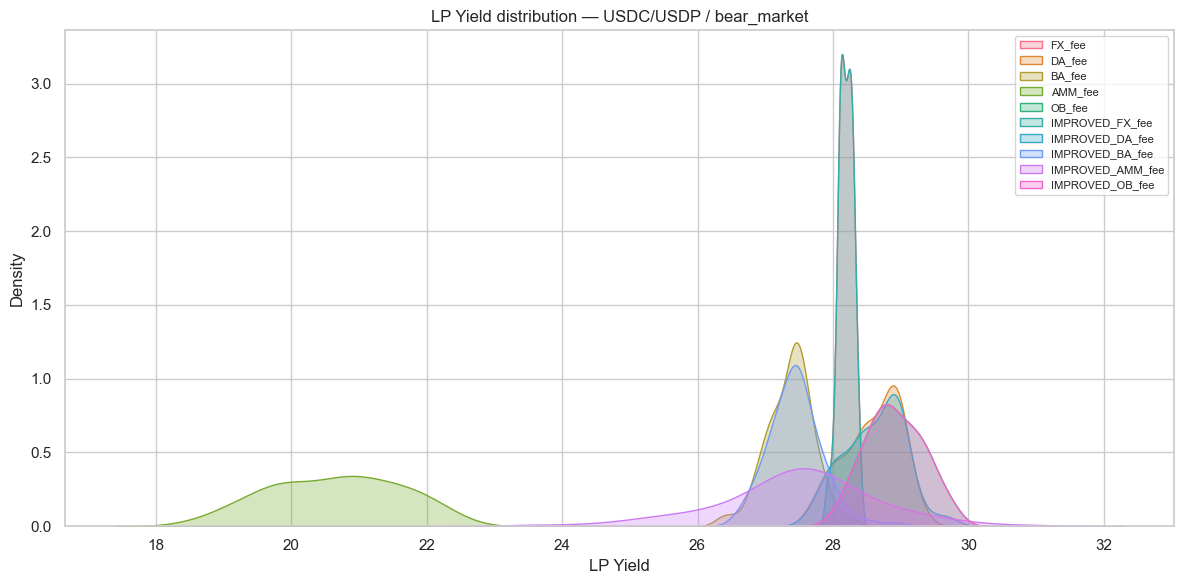

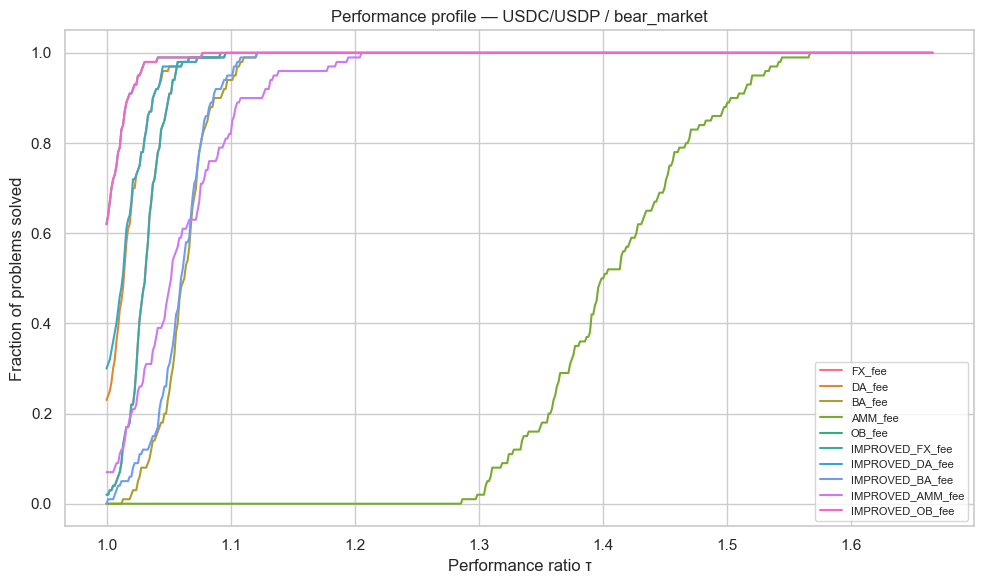

In [29]:
show_stats_for_pair_alias("USDC/USDP", "bear_market")
plot_yield_stats("USDC/USDP", "bear_market")
plot_performance_profile("USDC/USDP", "bear_market")

### Non-stable / Stable

#### BTC/ETH

##### volatile_market


=== BTC/ETH / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,599.40 ± 89.29,176.24 ± 11.11,3.42 ± 0.43,-8222.20 ± 316.46,722.46 ± 24.55,-56.47 ± 1.26,2835.98 ± 238.66,8.87 ± 0.85,-3120.94 ± 2076.19
BA_fee,73.55 ± 16.38,51.63 ± 8.82,1.58 ± 0.18,-8238.16 ± 289.45,723.61 ± 24.44,-56.49 ± 0.96,5195.35 ± 291.25,27.04 ± 0.99,-4538.56 ± 1672.03
DA_fee,69.84 ± 15.33,49.96 ± 9.03,1.56 ± 0.19,-8238.64 ± 301.69,723.69 ± 24.91,-56.49 ± 0.96,5177.94 ± 283.03,27.17 ± 0.99,-4252.26 ± 2211.27
FX_fee,71.21 ± 16.22,50.28 ± 8.98,1.58 ± 0.21,-8228.62 ± 297.29,723.20 ± 24.93,-56.46 ± 1.00,5183.92 ± 231.67,27.16 ± 0.19,-4370.99 ± 1941.05
IMPROVED_AMM_fee,6.93 ± 4.50,12.28 ± 3.65,0.17 ± 0.11,-8253.84 ± 355.53,722.69 ± 23.86,-56.67 ± 1.57,4375.51 ± 212.71,23.44 ± 1.38,-4698.95 ± 1906.66
IMPROVED_BA_fee,69.76 ± 16.52,49.54 ± 9.39,1.52 ± 0.20,-8238.09 ± 280.05,723.21 ± 24.20,-56.53 ± 0.99,5192.00 ± 289.07,27.14 ± 1.06,-4542.95 ± 1694.01
IMPROVED_DA_fee,88.39 ± 115.52,48.57 ± 9.57,2.08 ± 2.95,-8241.73 ± 303.21,723.44 ± 24.97,-56.53 ± 0.99,5166.09 ± 279.74,27.26 ± 1.01,-4264.08 ± 2174.10
IMPROVED_FX_fee,71.21 ± 16.22,50.28 ± 8.98,1.58 ± 0.21,-8228.62 ± 297.29,723.20 ± 24.93,-56.46 ± 1.00,5183.92 ± 231.67,27.16 ± 0.19,-4370.99 ± 1941.05
IMPROVED_OB_fee,49.79 ± 12.63,35.70 ± 9.12,1.57 ± 0.22,-8248.83 ± 296.05,723.15 ± 24.89,-56.60 ± 0.90,5374.25 ± 308.99,30.23 ± 0.47,-4522.41 ± 1804.17


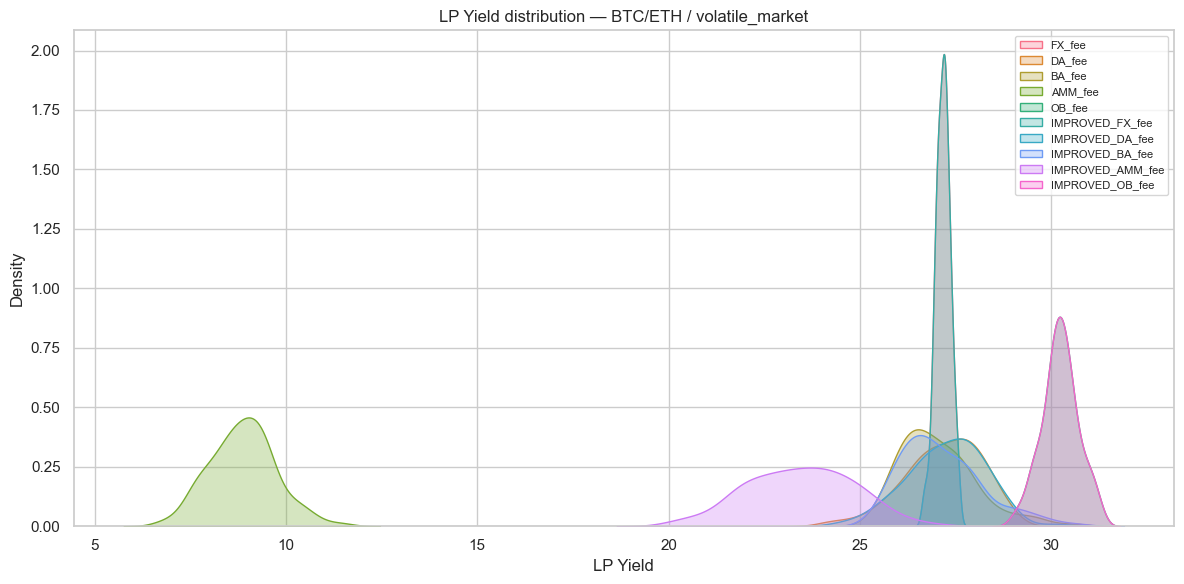

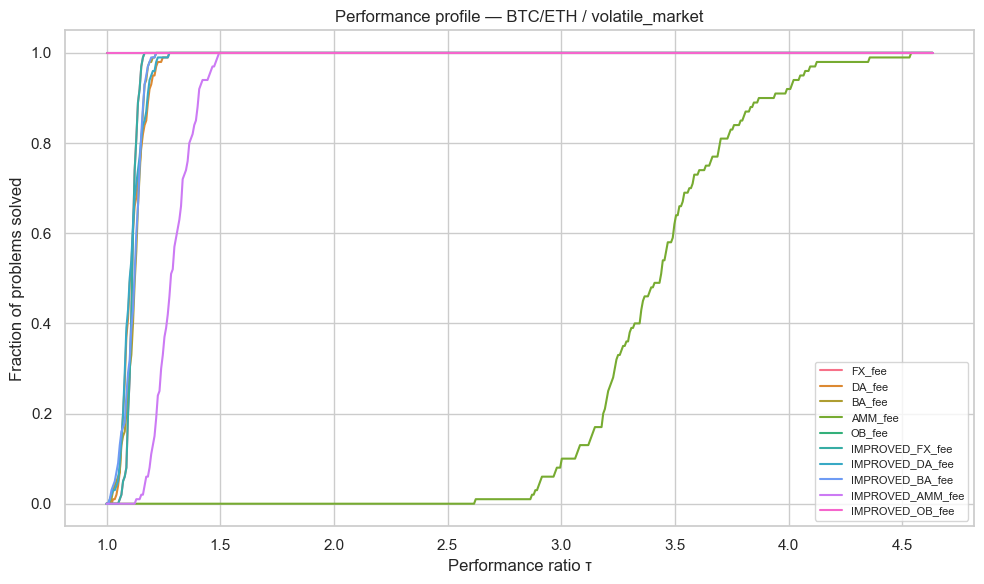

In [30]:
show_stats_for_pair_alias("BTC/ETH", "volatile_market")
plot_yield_stats("BTC/ETH", "volatile_market")
plot_performance_profile("BTC/ETH", "volatile_market")

##### bull_market


=== BTC/ETH / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,352.62 ± 58.36,142.91 ± 9.44,2.62 ± 0.37,-8168.42 ± 311.84,723.24 ± 23.86,-56.92 ± 1.12,3162.16 ± 212.18,11.39 ± 0.81,-3356.95 ± 1588.28
BA_fee,47.67 ± 12.91,39.34 ± 7.97,1.37 ± 0.21,-8161.45 ± 293.07,723.54 ± 25.13,-56.85 ± 0.99,4838.56 ± 266.73,27.17 ± 0.89,-4369.95 ± 1243.98
DA_fee,42.68 ± 11.32,37.06 ± 7.93,1.32 ± 0.19,-8163.28 ± 299.54,723.06 ± 24.54,-56.90 ± 1.04,4837.82 ± 253.14,27.52 ± 0.91,-4151.89 ± 1649.74
FX_fee,44.62 ± 13.17,37.58 ± 7.71,1.34 ± 0.20,-8162.82 ± 301.41,723.11 ± 25.05,-56.89 ± 1.02,4843.16 ± 211.24,27.46 ± 0.19,-4258.55 ± 1447.78
IMPROVED_AMM_fee,4.27 ± 2.79,9.23 ± 3.19,0.14 ± 0.10,-8173.12 ± 354.66,722.52 ± 24.22,-57.02 ± 1.70,4254.32 ± 226.52,24.50 ± 1.37,-4458.79 ± 1537.39
IMPROVED_BA_fee,44.75 ± 12.83,37.64 ± 7.93,1.32 ± 0.23,-8161.58 ± 292.65,723.39 ± 25.06,-56.86 ± 0.99,4832.58 ± 261.58,27.26 ± 0.95,-4374.50 ± 1242.42
IMPROVED_DA_fee,50.76 ± 69.85,36.41 ± 7.95,1.58 ± 1.95,-8167.10 ± 298.75,722.97 ± 24.55,-56.94 ± 1.08,4834.12 ± 246.42,27.58 ± 0.94,-4163.81 ± 1616.94
IMPROVED_FX_fee,44.62 ± 13.17,37.58 ± 7.71,1.34 ± 0.20,-8162.82 ± 301.41,723.11 ± 25.05,-56.89 ± 1.02,4843.16 ± 211.24,27.46 ± 0.19,-4258.55 ± 1447.78
IMPROVED_OB_fee,32.67 ± 11.81,26.65 ± 7.85,1.38 ± 0.25,-8169.79 ± 305.21,723.26 ± 24.29,-56.92 ± 0.89,4975.71 ± 283.55,29.80 ± 0.47,-4372.77 ± 1317.47


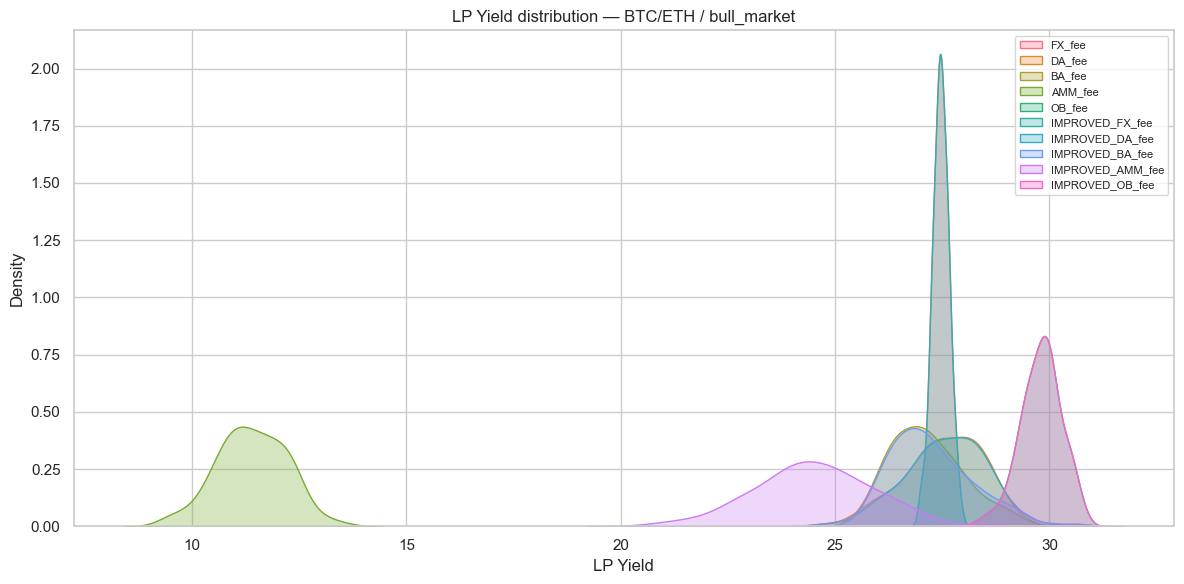

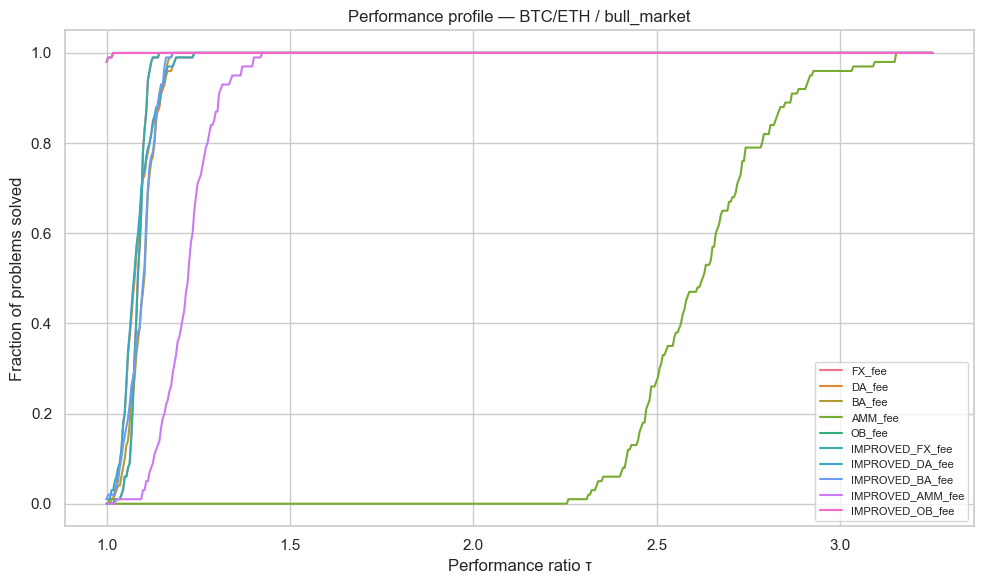

In [31]:
show_stats_for_pair_alias("BTC/ETH", "bull_market")
plot_yield_stats("BTC/ETH", "bull_market")
plot_performance_profile("BTC/ETH", "bull_market")

##### calm_market


=== BTC/ETH / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,585.15 ± 85.76,177.36 ± 10.11,3.36 ± 0.41,-8181.18 ± 294.33,722.85 ± 23.88,-56.81 ± 1.17,2809.16 ± 218.73,8.85 ± 0.80,-1719.12 ± 3092.14
BA_fee,76.89 ± 15.64,53.05 ± 8.07,1.62 ± 0.20,-8183.65 ± 291.30,723.33 ± 24.67,-56.80 ± 0.93,5231.49 ± 345.12,27.31 ± 1.24,-3390.17 ± 2503.76
DA_fee,70.10 ± 13.68,51.79 ± 8.19,1.52 ± 0.18,-8183.89 ± 296.79,722.96 ± 24.69,-56.83 ± 0.99,5102.73 ± 334.06,26.86 ± 1.40,-2740.21 ± 3386.18
FX_fee,73.36 ± 14.23,51.80 ± 8.46,1.59 ± 0.18,-8179.08 ± 287.98,723.04 ± 24.52,-56.79 ± 0.99,5156.88 ± 227.75,27.11 ± 0.18,-3021.27 ± 2932.24
IMPROVED_AMM_fee,7.69 ± 4.52,12.85 ± 3.72,0.19 ± 0.12,-8187.43 ± 370.56,723.04 ± 24.62,-56.85 ± 1.74,4341.30 ± 263.60,23.33 ± 1.50,-3344.56 ± 2866.35
IMPROVED_BA_fee,71.04 ± 16.10,50.59 ± 8.65,1.53 ± 0.23,-8181.30 ± 291.27,722.86 ± 24.43,-56.81 ± 0.96,5229.88 ± 338.26,27.46 ± 1.31,-3375.17 ± 2535.73
IMPROVED_DA_fee,135.16 ± 231.79,46.48 ± 10.92,3.18 ± 5.46,-8196.52 ± 313.97,722.57 ± 25.03,-56.95 ± 1.22,5090.27 ± 333.10,27.21 ± 1.04,-3127.74 ± 2818.14
IMPROVED_FX_fee,73.36 ± 14.23,51.80 ± 8.46,1.59 ± 0.18,-8179.08 ± 287.98,723.04 ± 24.52,-56.79 ± 0.99,5156.88 ± 227.75,27.11 ± 0.18,-3021.27 ± 2932.24
IMPROVED_OB_fee,53.51 ± 14.12,37.90 ± 8.63,1.59 ± 0.24,-8180.62 ± 296.12,722.84 ± 24.85,-56.81 ± 0.89,5377.94 ± 324.41,30.23 ± 0.48,-3256.30 ± 2753.51


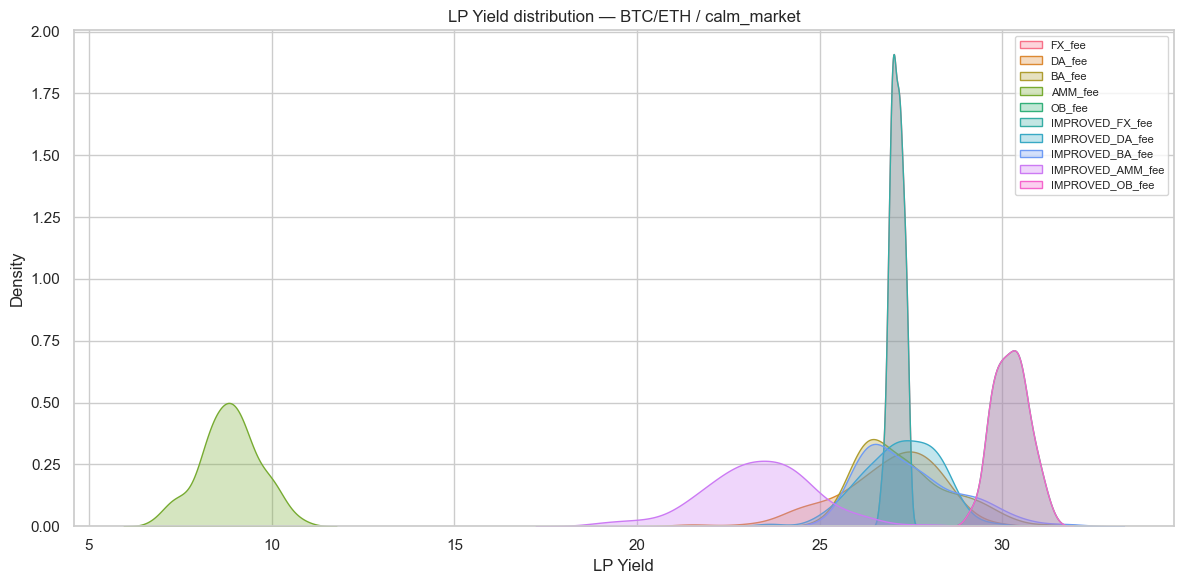

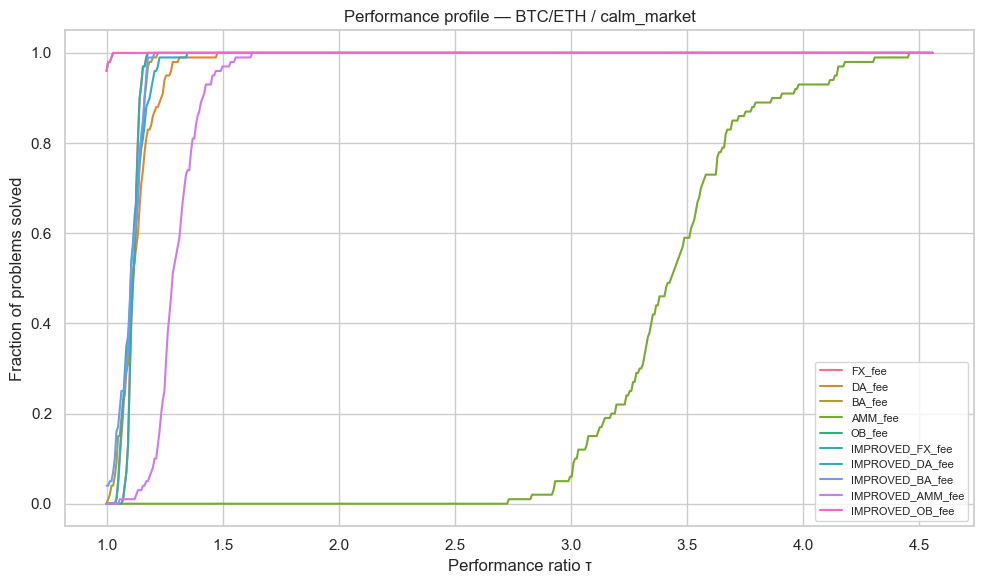

In [32]:
show_stats_for_pair_alias("BTC/ETH", "calm_market")
plot_yield_stats("BTC/ETH", "calm_market")
plot_performance_profile("BTC/ETH", "calm_market")

##### bear_market


=== BTC/ETH / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,307.31 ± 53.72,133.09 ± 9.39,2.49 ± 0.37,-8118.70 ± 294.01,722.62 ± 24.91,-57.31 ± 1.13,3196.76 ± 202.96,12.08 ± 0.88,-2557.67 ± 1936.00
BA_fee,44.08 ± 10.81,37.69 ± 7.11,1.34 ± 0.17,-8104.77 ± 287.09,723.16 ± 24.46,-57.17 ± 0.96,4782.88 ± 273.80,27.41 ± 1.01,-3670.56 ± 1512.91
DA_fee,37.40 ± 9.53,35.06 ± 7.10,1.24 ± 0.17,-8112.19 ± 292.23,722.74 ± 24.71,-57.26 ± 0.97,4728.04 ± 275.25,27.51 ± 1.14,-3267.15 ± 2090.98
FX_fee,39.69 ± 9.26,35.69 ± 7.01,1.29 ± 0.19,-8099.30 ± 292.80,722.96 ± 24.85,-57.15 ± 0.95,4744.37 ± 200.37,27.49 ± 0.17,-3429.40 ± 1800.63
IMPROVED_AMM_fee,3.79 ± 3.42,8.46 ± 2.91,0.14 ± 0.14,-8139.71 ± 340.35,722.82 ± 23.95,-57.45 ± 1.64,4201.69 ± 228.52,24.87 ± 1.38,-3593.26 ± 1828.01
IMPROVED_BA_fee,40.96 ± 11.26,36.07 ± 7.39,1.28 ± 0.23,-8104.25 ± 287.77,723.06 ± 24.08,-57.17 ± 0.97,4780.36 ± 265.42,27.51 ± 1.05,-3667.97 ± 1527.63
IMPROVED_DA_fee,70.10 ± 150.81,32.27 ± 7.78,2.38 ± 4.88,-8134.19 ± 306.63,722.83 ± 25.12,-57.41 ± 1.12,4733.40 ± 263.79,27.78 ± 0.84,-3526.77 ± 1756.11
IMPROVED_FX_fee,39.69 ± 9.26,35.69 ± 7.01,1.29 ± 0.19,-8099.30 ± 292.80,722.96 ± 24.85,-57.15 ± 0.95,4744.37 ± 200.37,27.49 ± 0.17,-3429.40 ± 1800.63
IMPROVED_OB_fee,30.32 ± 10.29,26.30 ± 7.86,1.33 ± 0.24,-8119.47 ± 292.23,723.27 ± 24.84,-57.26 ± 0.84,4905.10 ± 279.60,29.79 ± 0.47,-3633.22 ± 1621.39


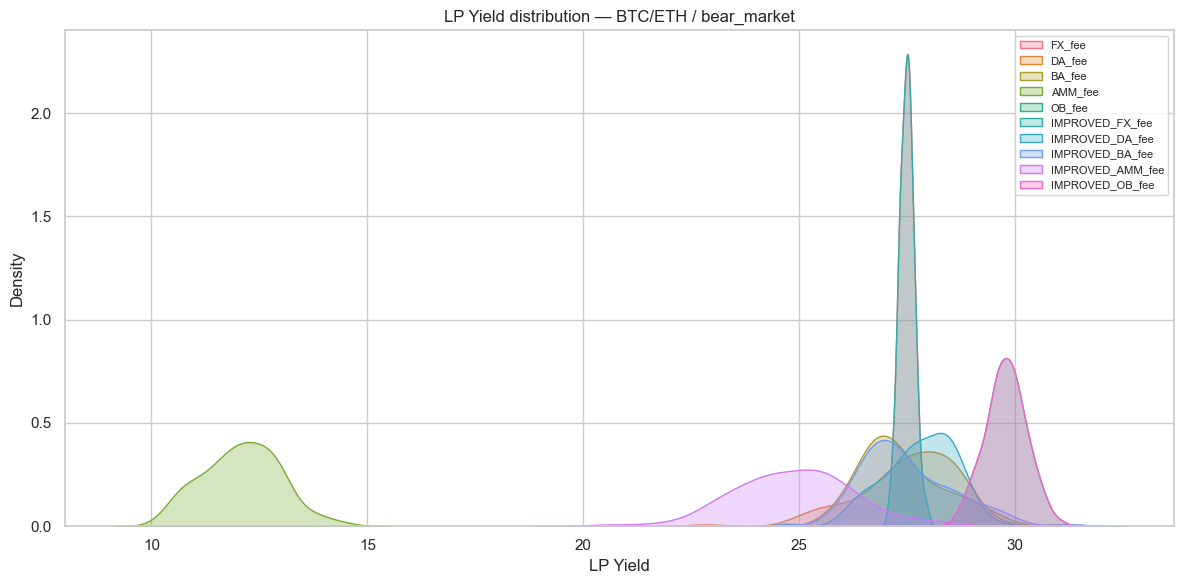

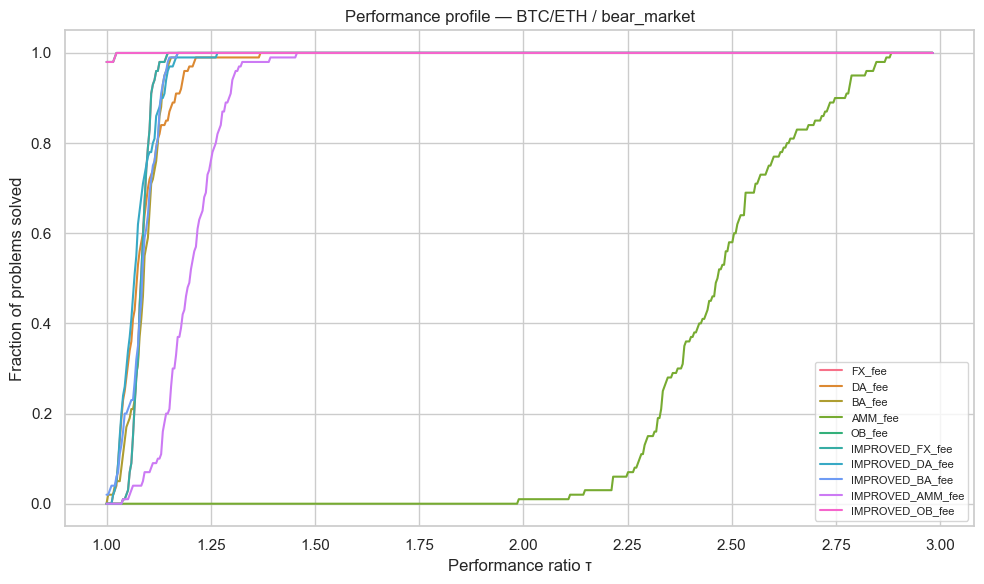

In [33]:
show_stats_for_pair_alias("BTC/ETH", "bear_market")
plot_yield_stats("BTC/ETH", "bear_market")
plot_performance_profile("BTC/ETH", "bear_market")

#### BTC/BNB

##### volatile_market


=== BTC/BNB / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,1188.65 ± 156.78,234.88 ± 13.21,4.76 ± 0.51,-8223.35 ± 307.97,722.84 ± 23.53,-56.55 ± 1.08,2034.67 ± 280.84,5.17 ± 0.80,-2296.32 ± 2849.14
BA_fee,139.88 ± 23.73,77.13 ± 10.05,1.97 ± 0.18,-8238.22 ± 293.46,723.15 ± 24.53,-56.63 ± 0.91,5782.53 ± 359.00,26.70 ± 1.15,-4523.22 ± 2386.21
DA_fee,138.18 ± 25.42,78.29 ± 11.19,1.92 ± 0.18,-8244.23 ± 306.58,723.25 ± 24.63,-56.66 ± 0.90,5725.15 ± 351.81,26.34 ± 1.12,-4041.03 ± 3168.13
FX_fee,141.58 ± 24.41,77.81 ± 10.78,1.97 ± 0.18,-8243.68 ± 307.18,723.42 ± 25.08,-56.65 ± 0.93,5768.18 ± 273.31,26.55 ± 0.19,-4284.62 ± 2814.45
IMPROVED_AMM_fee,16.94 ± 9.09,20.45 ± 4.77,0.27 ± 0.15,-8246.30 ± 368.82,723.07 ± 24.76,-56.69 ± 1.67,4565.57 ± 269.27,21.85 ± 1.53,-4653.86 ± 2863.33
IMPROVED_BA_fee,130.26 ± 25.31,73.25 ± 10.76,1.87 ± 0.23,-8237.37 ± 289.80,723.05 ± 24.26,-56.64 ± 0.95,5778.12 ± 353.63,26.88 ± 1.27,-4536.71 ± 2434.40
IMPROVED_DA_fee,181.20 ± 204.73,73.32 ± 14.53,2.73 ± 3.18,-8260.24 ± 318.99,723.17 ± 25.03,-56.78 ± 1.08,5682.69 ± 374.07,26.54 ± 1.05,-4127.77 ± 3027.89
IMPROVED_FX_fee,141.58 ± 24.41,77.81 ± 10.78,1.97 ± 0.18,-8243.68 ± 307.18,723.42 ± 25.08,-56.65 ± 0.93,5768.18 ± 273.31,26.55 ± 0.19,-4284.62 ± 2814.45
IMPROVED_OB_fee,101.27 ± 23.49,55.32 ± 10.58,1.98 ± 0.23,-8239.39 ± 289.19,723.90 ± 24.70,-56.58 ± 0.83,6067.84 ± 383.10,30.83 ± 0.49,-4495.46 ± 2709.13


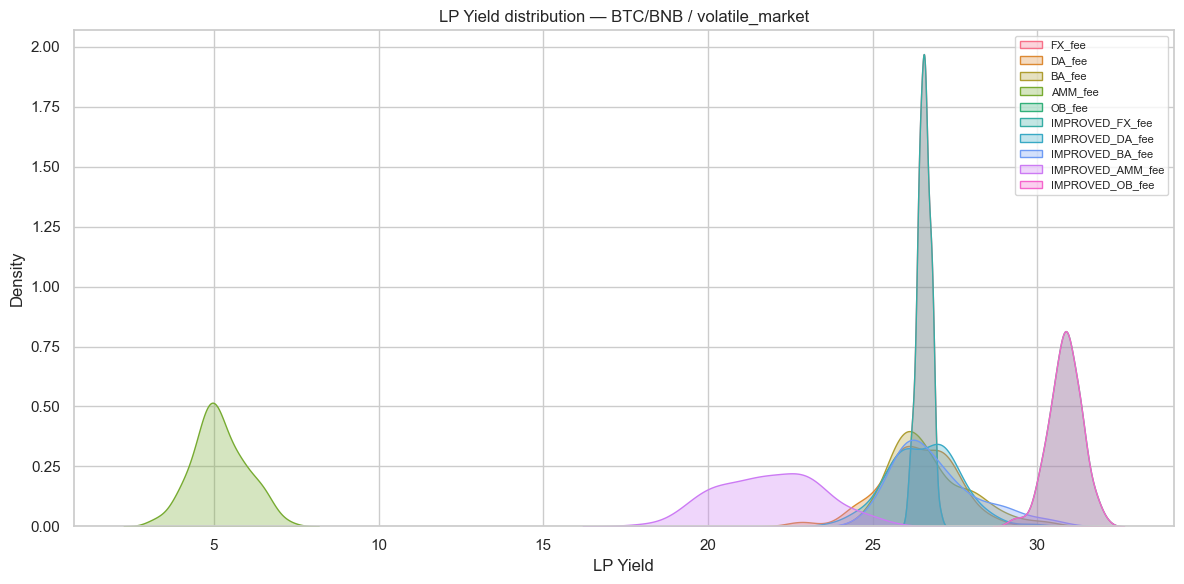

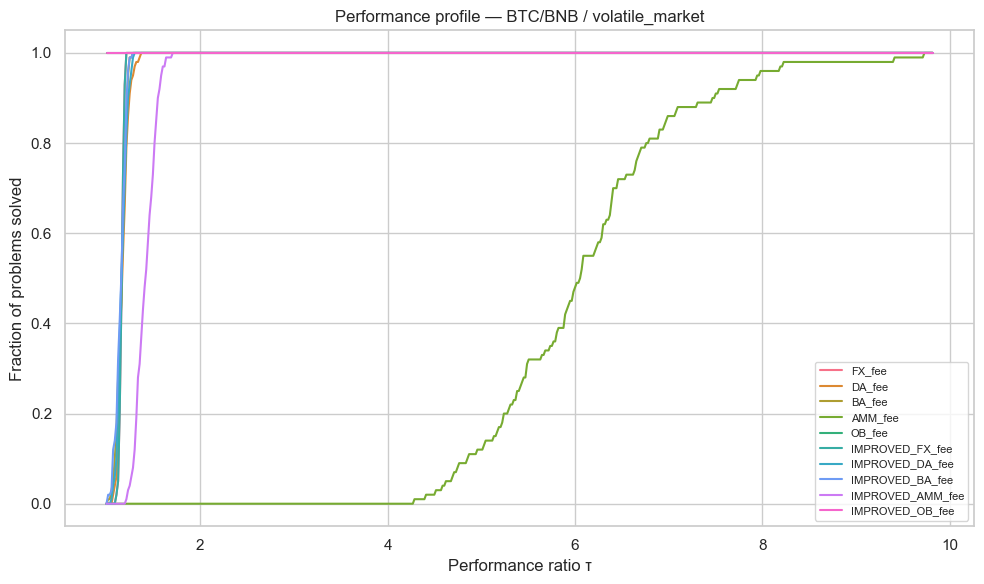

In [34]:
show_stats_for_pair_alias("BTC/BNB", "volatile_market")
plot_yield_stats("BTC/BNB", "volatile_market")
plot_performance_profile("BTC/BNB", "volatile_market")

##### bull_market


=== BTC/BNB / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,558.33 ± 88.92,172.68 ± 9.00,3.30 ± 0.43,-8164.10 ± 302.83,722.87 ± 23.96,-56.96 ± 1.15,2831.29 ± 221.32,9.09 ± 0.78,-3085.04 ± 1783.34
BA_fee,69.65 ± 16.12,50.20 ± 8.67,1.55 ± 0.18,-8164.90 ± 295.27,723.11 ± 25.56,-56.94 ± 0.92,5074.56 ± 283.06,27.00 ± 0.97,-4396.39 ± 1434.82
DA_fee,64.16 ± 15.56,48.43 ± 9.10,1.49 ± 0.19,-8170.06 ± 292.34,723.12 ± 24.24,-56.98 ± 0.91,5049.31 ± 273.94,27.13 ± 0.94,-4108.24 ± 1940.49
FX_fee,67.28 ± 15.32,48.83 ± 8.88,1.55 ± 0.18,-8163.68 ± 289.70,723.04 ± 24.59,-56.94 ± 0.93,5074.27 ± 226.89,27.18 ± 0.19,-4265.48 ± 1694.41
IMPROVED_AMM_fee,6.85 ± 4.83,11.78 ± 3.40,0.18 ± 0.12,-8166.67 ± 343.71,722.74 ± 24.82,-56.98 ± 1.63,4318.56 ± 243.21,23.83 ± 1.39,-4440.40 ± 1750.96
IMPROVED_BA_fee,65.43 ± 16.04,48.01 ± 8.73,1.49 ± 0.21,-8165.64 ± 293.17,722.76 ± 25.23,-56.98 ± 0.95,5068.50 ± 277.17,27.11 ± 1.05,-4402.60 ± 1444.38
IMPROVED_DA_fee,72.86 ± 91.30,46.70 ± 9.76,1.75 ± 2.24,-8175.07 ± 293.31,722.92 ± 24.23,-57.03 ± 0.99,5037.75 ± 280.83,27.22 ± 0.94,-4128.84 ± 1876.94
IMPROVED_FX_fee,67.28 ± 15.32,48.83 ± 8.88,1.55 ± 0.18,-8163.68 ± 289.70,723.04 ± 24.59,-56.94 ± 0.93,5074.27 ± 226.89,27.18 ± 0.19,-4265.48 ± 1694.41
IMPROVED_OB_fee,47.60 ± 13.61,34.51 ± 8.38,1.55 ± 0.25,-8172.32 ± 288.65,723.72 ± 24.46,-56.94 ± 0.79,5245.74 ± 297.96,30.11 ± 0.48,-4395.28 ± 1565.96


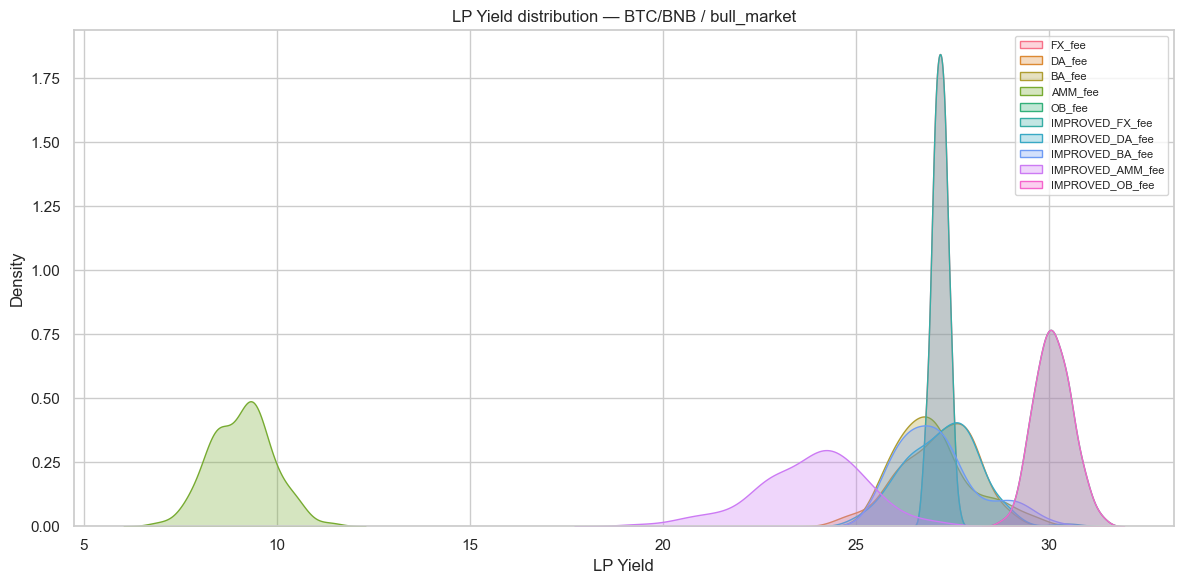

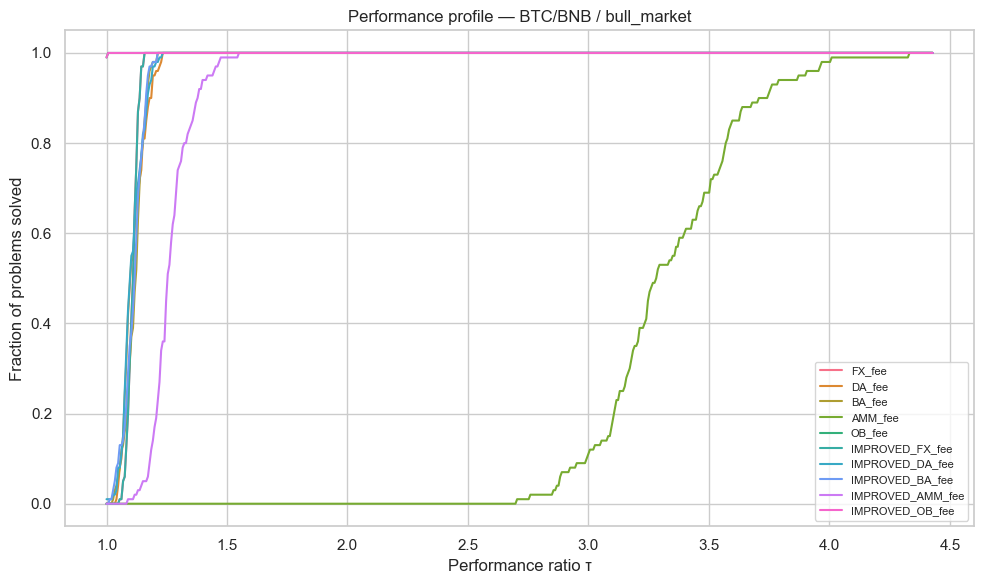

In [35]:
show_stats_for_pair_alias("BTC/BNB", "bull_market")
plot_yield_stats("BTC/BNB", "bull_market")
plot_performance_profile("BTC/BNB", "bull_market")

##### calm_market


=== BTC/BNB / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,731.63 ± 105.85,192.43 ± 11.76,3.78 ± 0.43,-8168.19 ± 305.69,722.08 ± 24.48,-56.67 ± 1.21,2591.64 ± 253.45,7.70 ± 0.89,-2321.31 ± 2673.69
BA_fee,88.82 ± 16.26,58.06 ± 8.84,1.70 ± 0.20,-8197.58 ± 299.09,723.16 ± 24.82,-56.79 ± 0.92,5321.96 ± 348.11,27.06 ± 1.15,-4042.06 ± 2142.57
DA_fee,84.77 ± 17.94,57.48 ± 9.63,1.64 ± 0.17,-8203.48 ± 294.34,722.95 ± 24.67,-56.85 ± 0.88,5252.97 ± 330.47,26.83 ± 1.27,-3545.09 ± 2959.45
FX_fee,86.79 ± 15.41,57.52 ± 8.91,1.68 ± 0.18,-8196.24 ± 288.32,723.21 ± 24.72,-56.79 ± 0.86,5289.18 ± 238.26,26.98 ± 0.17,-3782.18 ± 2537.18
IMPROVED_AMM_fee,9.64 ± 5.74,14.64 ± 3.93,0.21 ± 0.12,-8209.91 ± 316.88,722.07 ± 23.81,-56.98 ± 1.57,4390.25 ± 230.36,22.97 ± 1.59,-4102.00 ± 2506.47
IMPROVED_BA_fee,82.88 ± 15.06,55.06 ± 8.94,1.62 ± 0.20,-8201.97 ± 308.09,722.98 ± 24.86,-56.84 ± 1.04,5318.65 ± 346.64,27.21 ± 1.21,-4046.31 ± 2169.68
IMPROVED_DA_fee,123.81 ± 179.58,53.18 ± 11.55,2.72 ± 4.49,-8216.56 ± 313.58,722.91 ± 24.69,-56.94 ± 1.12,5233.88 ± 342.81,27.08 ± 1.00,-3764.03 ± 2545.42
IMPROVED_FX_fee,86.79 ± 15.41,57.52 ± 8.91,1.68 ± 0.18,-8196.24 ± 288.32,723.21 ± 24.72,-56.79 ± 0.86,5289.18 ± 238.26,26.98 ± 0.17,-3782.18 ± 2537.18
IMPROVED_OB_fee,61.34 ± 15.58,41.02 ± 8.65,1.66 ± 0.20,-8194.39 ± 288.91,723.42 ± 24.97,-56.75 ± 0.81,5497.93 ± 320.72,30.32 ± 0.46,-3956.30 ± 2422.43


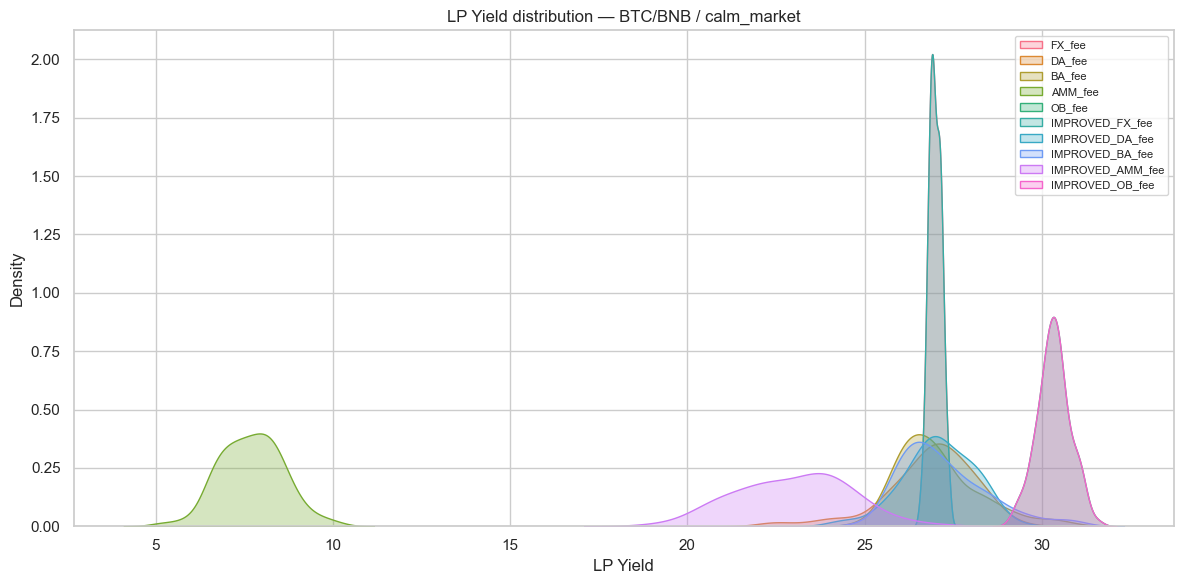

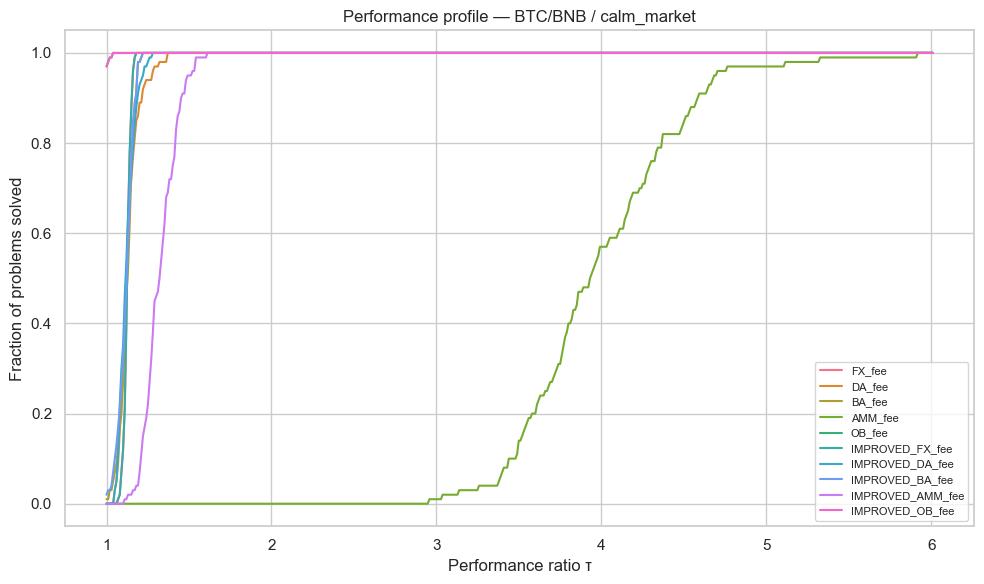

In [36]:
show_stats_for_pair_alias("BTC/BNB", "calm_market")
plot_yield_stats("BTC/BNB", "calm_market")
plot_performance_profile("BTC/BNB", "calm_market")

##### bear_market


=== BTC/BNB / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,1200.43 ± 150.61,235.88 ± 13.77,4.86 ± 0.52,-8078.06 ± 302.81,722.24 ± 24.17,-57.22 ± 1.00,1890.43 ± 231.11,4.89 ± 0.67,815.05 ± 5536.38
BA_fee,144.54 ± 24.75,79.31 ± 10.12,2.00 ± 0.20,-8100.65 ± 287.10,723.07 ± 24.35,-57.32 ± 0.92,5804.51 ± 436.35,27.19 ± 1.55,-1730.08 ± 4788.56
DA_fee,142.43 ± 24.45,79.70 ± 10.38,1.97 ± 0.22,-8109.00 ± 292.82,723.06 ± 24.31,-57.38 ± 1.00,5548.01 ± 475.36,25.97 ± 1.82,-761.64 ± 5996.71
FX_fee,143.76 ± 23.78,79.63 ± 10.28,1.99 ± 0.19,-8093.01 ± 280.25,723.02 ± 24.32,-57.28 ± 0.96,5651.54 ± 262.71,26.46 ± 0.19,-1172.38 ± 5403.62
IMPROVED_AMM_fee,21.86 ± 10.98,22.84 ± 5.21,0.34 ± 0.18,-8099.79 ± 344.27,722.59 ± 24.37,-57.36 ± 1.68,4542.15 ± 289.20,21.96 ± 1.72,-1733.52 ± 5449.08
IMPROVED_BA_fee,132.58 ± 29.53,74.63 ± 11.24,1.88 ± 0.26,-8101.83 ± 295.33,722.62 ± 24.30,-57.36 ± 0.97,5789.59 ± 422.86,27.41 ± 1.68,-1698.06 ± 4893.85
IMPROVED_DA_fee,295.80 ± 365.35,69.75 ± 16.90,4.79 ± 6.26,-8132.51 ± 306.96,723.40 ± 24.92,-57.53 ± 1.34,5520.79 ± 485.88,26.46 ± 1.33,-1472.96 ± 5040.29
IMPROVED_FX_fee,143.76 ± 23.78,79.63 ± 10.28,1.99 ± 0.19,-8093.01 ± 280.25,723.02 ± 24.32,-57.28 ± 0.96,5651.54 ± 262.71,26.46 ± 0.19,-1172.38 ± 5403.62
IMPROVED_OB_fee,104.95 ± 21.40,58.46 ± 10.86,1.98 ± 0.21,-8095.89 ± 290.14,723.20 ± 24.95,-57.28 ± 0.94,6021.94 ± 379.96,30.96 ± 0.47,-1529.71 ± 5220.64


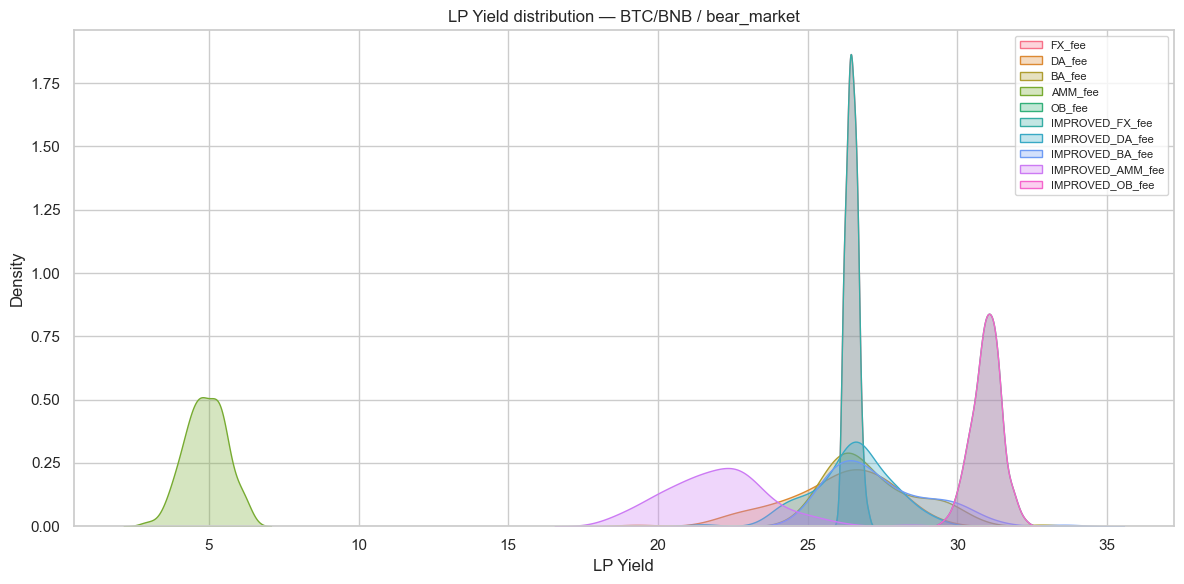

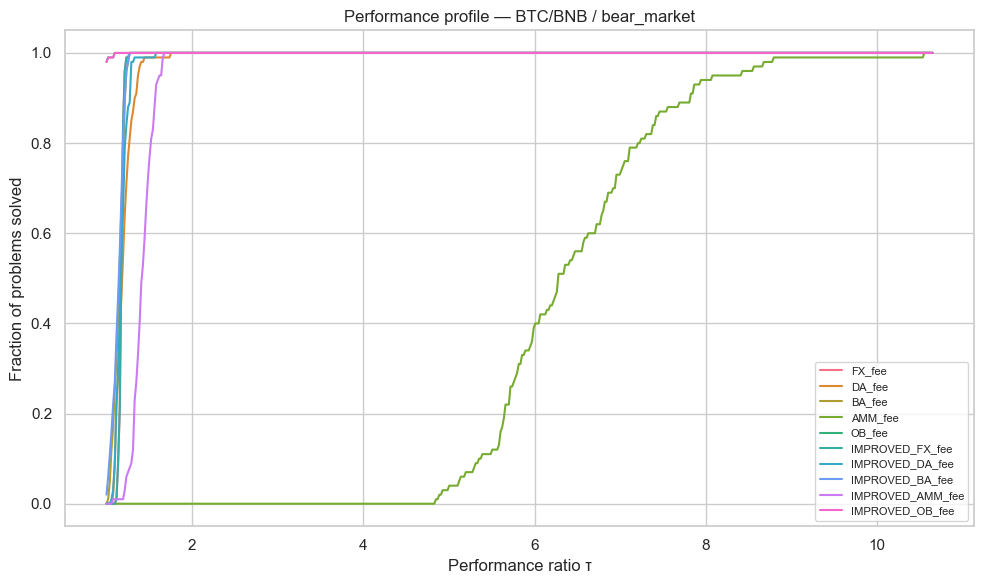

In [37]:
show_stats_for_pair_alias("BTC/BNB", "bear_market")
plot_yield_stats("BTC/BNB", "bear_market")
plot_performance_profile("BTC/BNB", "bear_market")

#### ETH/BNB

##### volatile_market


=== ETH/BNB / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,1367.07 ± 169.58,248.61 ± 11.71,5.09 ± 0.56,-8252.91 ± 306.56,722.71 ± 24.16,-56.66 ± 1.07,1837.78 ± 267.69,4.45 ± 0.69,-1863.21 ± 3581.31
BA_fee,159.15 ± 25.47,82.98 ± 11.25,2.06 ± 0.17,-8240.37 ± 289.67,723.23 ± 24.64,-56.54 ± 0.87,5948.52 ± 437.82,26.69 ± 1.27,-4301.16 ± 2931.21
DA_fee,155.29 ± 28.02,84.19 ± 12.45,1.99 ± 0.18,-8251.23 ± 299.33,723.01 ± 24.37,-56.63 ± 0.87,5843.74 ± 399.90,26.16 ± 1.29,-3702.98 ± 4020.00
FX_fee,158.99 ± 28.19,83.12 ± 11.45,2.06 ± 0.19,-8242.07 ± 287.88,722.99 ± 24.44,-56.57 ± 0.84,5893.40 ± 291.03,26.44 ± 0.20,-3998.62 ± 3443.36
IMPROVED_AMM_fee,19.05 ± 9.07,22.12 ± 5.20,0.27 ± 0.13,-8283.12 ± 334.68,723.42 ± 24.88,-56.83 ± 1.54,4605.47 ± 301.45,21.44 ± 1.42,-4437.23 ± 3498.09
IMPROVED_BA_fee,146.86 ± 26.42,78.97 ± 11.35,1.94 ± 0.23,-8248.75 ± 299.90,723.30 ± 24.98,-56.60 ± 0.90,5946.75 ± 430.03,26.85 ± 1.41,-4328.16 ± 2987.99
IMPROVED_DA_fee,210.13 ± 271.40,77.43 ± 16.33,3.02 ± 4.39,-8270.00 ± 305.33,722.60 ± 24.28,-56.79 ± 1.02,5799.54 ± 414.12,26.41 ± 1.11,-3906.55 ± 3556.49
IMPROVED_FX_fee,158.99 ± 28.19,83.12 ± 11.45,2.06 ± 0.19,-8242.07 ± 287.88,722.99 ± 24.44,-56.57 ± 0.84,5893.40 ± 291.03,26.44 ± 0.20,-3998.62 ± 3443.36
IMPROVED_OB_fee,115.97 ± 27.24,59.37 ± 11.19,2.09 ± 0.26,-8244.90 ± 291.57,723.22 ± 24.61,-56.57 ± 0.82,6219.09 ± 416.51,30.92 ± 0.48,-4229.57 ± 3343.88


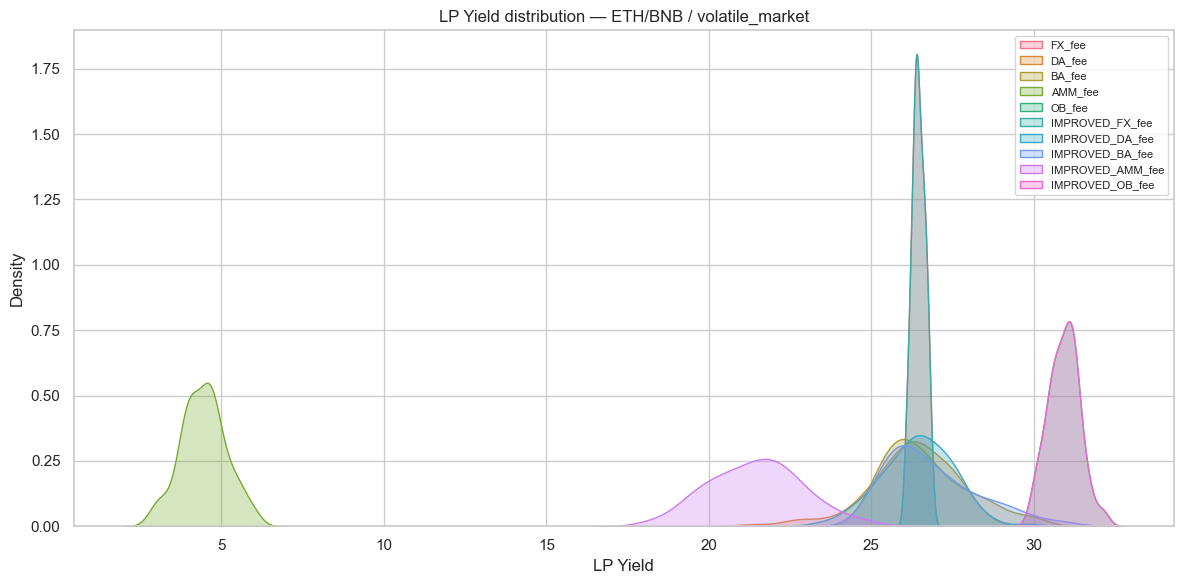

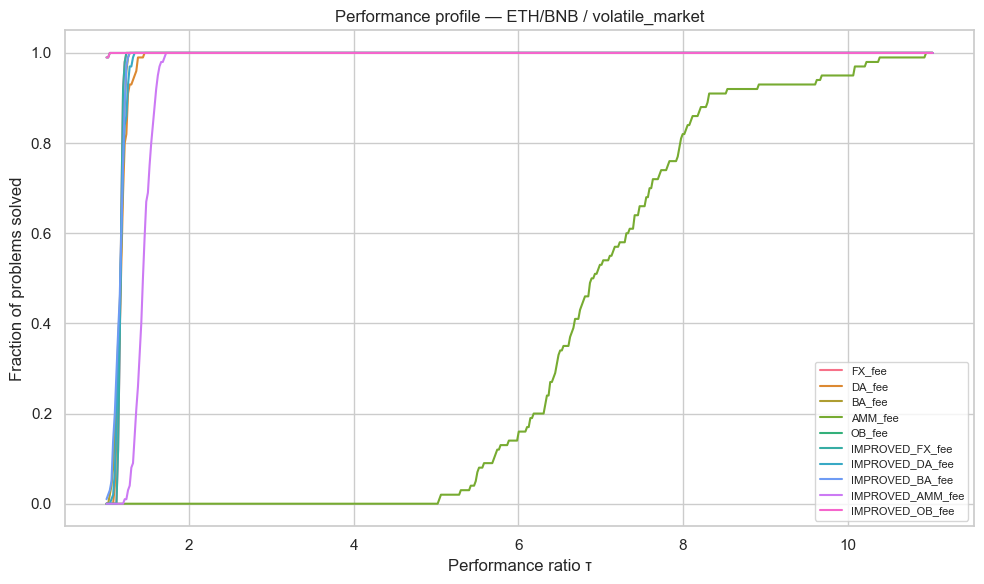

In [38]:
show_stats_for_pair_alias("ETH/BNB", "volatile_market")
plot_yield_stats("ETH/BNB", "volatile_market")
plot_performance_profile("ETH/BNB", "volatile_market")

##### bull_market


=== ETH/BNB / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,771.59 ± 109.07,197.55 ± 10.83,3.88 ± 0.48,-8188.52 ± 312.18,723.15 ± 23.77,-56.99 ± 1.13,2547.99 ± 248.48,7.45 ± 0.80,-2782.50 ± 2243.79
BA_fee,92.46 ± 20.35,59.46 ± 9.96,1.72 ± 0.20,-8176.22 ± 289.03,723.36 ± 24.96,-56.89 ± 0.93,5301.76 ± 354.87,26.88 ± 1.11,-4386.22 ± 1779.49
DA_fee,88.61 ± 19.72,58.24 ± 10.25,1.69 ± 0.19,-8186.97 ± 295.59,723.11 ± 24.58,-56.99 ± 0.88,5255.90 ± 311.79,26.84 ± 1.11,-3997.07 ± 2503.48
FX_fee,90.48 ± 18.27,58.35 ± 10.18,1.72 ± 0.18,-8179.70 ± 284.08,723.33 ± 24.17,-56.92 ± 0.91,5287.17 ± 259.06,26.95 ± 0.20,-4205.34 ± 2127.88
IMPROVED_AMM_fee,9.61 ± 5.16,14.73 ± 4.22,0.20 ± 0.10,-8200.12 ± 343.49,722.99 ± 24.60,-57.09 ± 1.52,4382.52 ± 256.96,22.96 ± 1.52,-4529.20 ± 2195.35
IMPROVED_BA_fee,86.55 ± 19.11,56.34 ± 9.65,1.65 ± 0.22,-8187.58 ± 294.52,723.31 ± 24.91,-56.97 ± 0.99,5298.79 ± 354.64,27.02 ± 1.20,-4403.39 ± 1782.66
IMPROVED_DA_fee,118.10 ± 161.39,54.83 ± 11.49,2.41 ± 3.40,-8197.33 ± 294.16,722.83 ± 24.68,-57.09 ± 1.03,5234.87 ± 317.42,27.00 ± 1.01,-4096.40 ± 2259.90
IMPROVED_FX_fee,90.48 ± 18.27,58.35 ± 10.18,1.72 ± 0.18,-8179.70 ± 284.08,723.33 ± 24.17,-56.92 ± 0.91,5287.17 ± 259.06,26.95 ± 0.20,-4205.34 ± 2127.88
IMPROVED_OB_fee,64.27 ± 17.24,41.76 ± 9.14,1.71 ± 0.24,-8185.16 ± 289.34,723.58 ± 24.69,-56.93 ± 0.84,5503.26 ± 318.37,30.34 ± 0.46,-4370.63 ± 2031.58


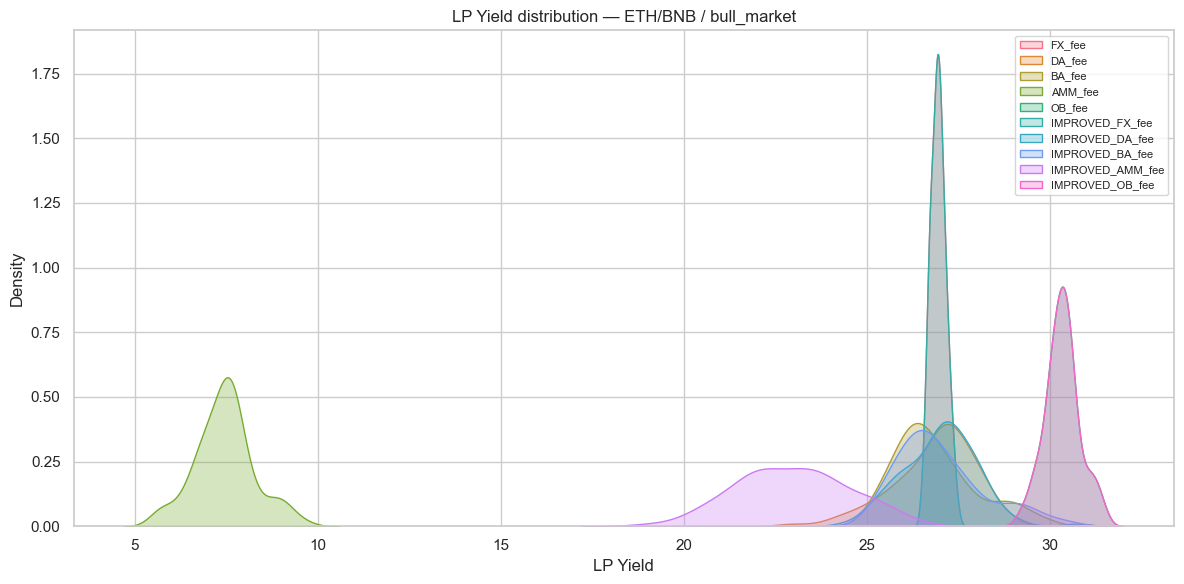

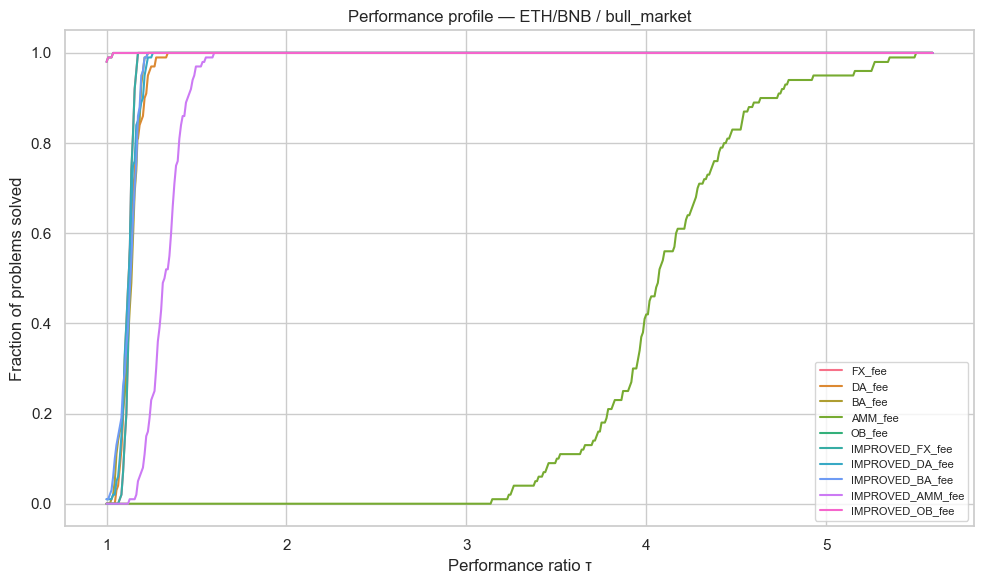

In [39]:
show_stats_for_pair_alias("ETH/BNB", "bull_market")
plot_yield_stats("ETH/BNB", "bull_market")
plot_performance_profile("ETH/BNB", "bull_market")

##### calm_market


=== ETH/BNB / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,810.50 ± 109.13,199.87 ± 9.81,4.00 ± 0.48,-8154.73 ± 309.24,723.13 ± 24.53,-56.78 ± 1.13,2468.90 ± 238.25,7.14 ± 0.73,-2611.61 ± 2493.15
BA_fee,96.04 ± 18.09,60.57 ± 9.34,1.76 ± 0.19,-8173.76 ± 293.59,723.26 ± 24.64,-56.91 ± 0.91,5334.77 ± 334.28,26.91 ± 1.11,-4284.54 ± 2034.96
DA_fee,91.72 ± 18.96,60.33 ± 9.97,1.69 ± 0.18,-8178.86 ± 299.50,723.20 ± 24.47,-56.96 ± 0.94,5289.49 ± 314.96,26.76 ± 1.05,-3890.55 ± 2734.84
FX_fee,93.34 ± 18.21,60.26 ± 9.83,1.72 ± 0.17,-8171.32 ± 300.85,723.27 ± 24.86,-56.89 ± 0.93,5323.32 ± 254.51,26.92 ± 0.20,-4085.61 ± 2420.94
IMPROVED_AMM_fee,10.14 ± 5.07,15.03 ± 4.21,0.22 ± 0.11,-8187.56 ± 340.00,722.99 ± 24.53,-57.03 ± 1.61,4387.87 ± 225.62,22.96 ± 1.67,-4431.22 ± 2397.45
IMPROVED_BA_fee,89.67 ± 18.60,57.57 ± 8.98,1.68 ± 0.23,-8175.57 ± 291.33,723.08 ± 24.66,-56.94 ± 0.94,5327.13 ± 330.61,27.06 ± 1.21,-4286.23 ± 2059.87
IMPROVED_DA_fee,112.60 ± 129.22,57.74 ± 11.00,2.18 ± 2.69,-8191.27 ± 307.51,723.18 ± 24.48,-57.04 ± 1.09,5274.36 ± 319.43,26.90 ± 1.06,-3929.65 ± 2662.35
IMPROVED_FX_fee,93.34 ± 18.21,60.26 ± 9.83,1.72 ± 0.17,-8171.32 ± 300.85,723.27 ± 24.86,-56.89 ± 0.93,5323.32 ± 254.51,26.92 ± 0.20,-4085.61 ± 2420.94
IMPROVED_OB_fee,66.98 ± 17.17,43.00 ± 9.55,1.73 ± 0.23,-8182.48 ± 291.17,723.83 ± 25.02,-56.93 ± 0.82,5546.77 ± 324.51,30.39 ± 0.46,-4275.92 ± 2274.96


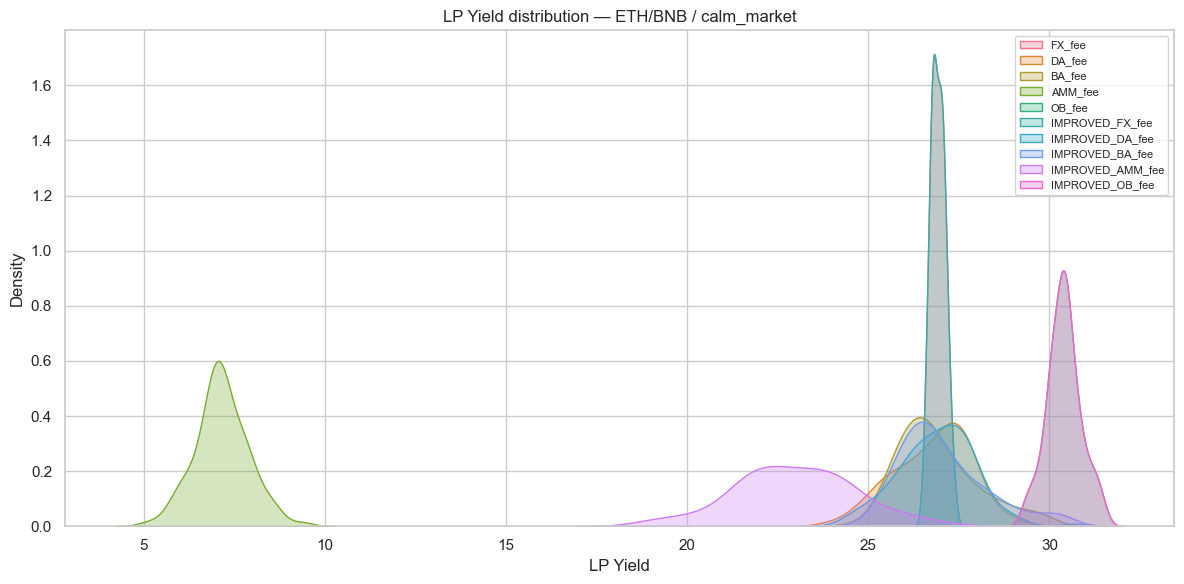

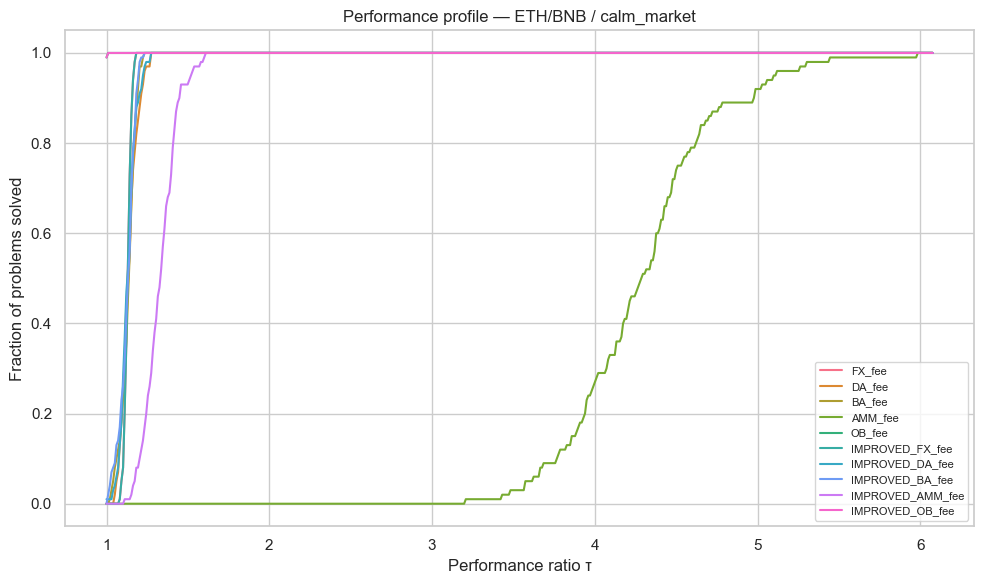

In [40]:
show_stats_for_pair_alias("ETH/BNB", "calm_market")
plot_yield_stats("ETH/BNB", "calm_market")
plot_performance_profile("ETH/BNB", "calm_market")

##### bear_market


=== ETH/BNB / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,1252.12 ± 149.85,238.81 ± 12.85,4.99 ± 0.49,-8068.22 ± 290.05,722.99 ± 24.20,-57.35 ± 1.00,1821.44 ± 238.34,4.67 ± 0.68,-1438.39 ± 3591.81
BA_fee,151.85 ± 24.81,80.37 ± 10.51,2.07 ± 0.19,-8082.83 ± 292.19,723.29 ± 24.30,-57.43 ± 1.01,5709.56 ± 382.32,26.69 ± 1.24,-3728.29 ± 3066.67
DA_fee,147.84 ± 22.30,81.75 ± 10.40,2.00 ± 0.15,-8093.85 ± 298.19,723.38 ± 24.62,-57.50 ± 1.03,5627.65 ± 387.71,26.19 ± 1.34,-3181.39 ± 3905.27
FX_fee,148.85 ± 25.40,81.04 ± 10.49,2.02 ± 0.17,-8072.62 ± 290.51,722.39 ± 24.34,-57.42 ± 1.00,5659.03 ± 264.46,26.43 ± 0.19,-3423.80 ± 3483.09
IMPROVED_AMM_fee,20.87 ± 9.84,22.78 ± 4.76,0.32 ± 0.15,-8094.29 ± 363.84,722.54 ± 23.91,-57.56 ± 1.81,4527.00 ± 256.58,21.96 ± 1.50,-3966.33 ± 3441.06
IMPROVED_BA_fee,139.06 ± 27.29,75.95 ± 11.34,1.94 ± 0.23,-8087.76 ± 292.54,723.43 ± 24.28,-57.46 ± 1.04,5702.30 ± 375.04,26.89 ± 1.35,-3751.02 ± 3080.44
IMPROVED_DA_fee,217.15 ± 265.59,74.96 ± 15.50,3.39 ± 4.65,-8100.29 ± 306.00,723.08 ± 24.77,-57.57 ± 1.10,5591.71 ± 410.57,26.50 ± 1.06,-3485.54 ± 3420.08
IMPROVED_FX_fee,148.85 ± 25.40,81.04 ± 10.49,2.02 ± 0.17,-8072.62 ± 290.51,722.39 ± 24.34,-57.42 ± 1.00,5659.03 ± 264.46,26.43 ± 0.19,-3423.80 ± 3483.09
IMPROVED_OB_fee,106.70 ± 22.56,58.71 ± 10.38,2.00 ± 0.21,-8082.94 ± 290.32,723.55 ± 25.01,-57.41 ± 0.90,6009.22 ± 368.12,30.95 ± 0.44,-3671.26 ± 3367.40


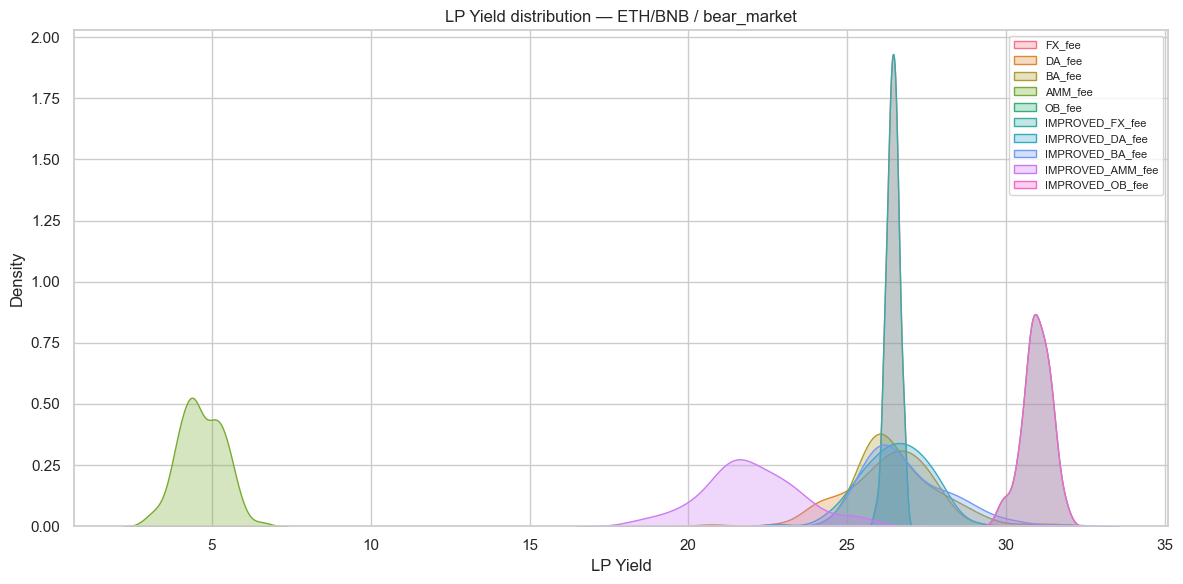

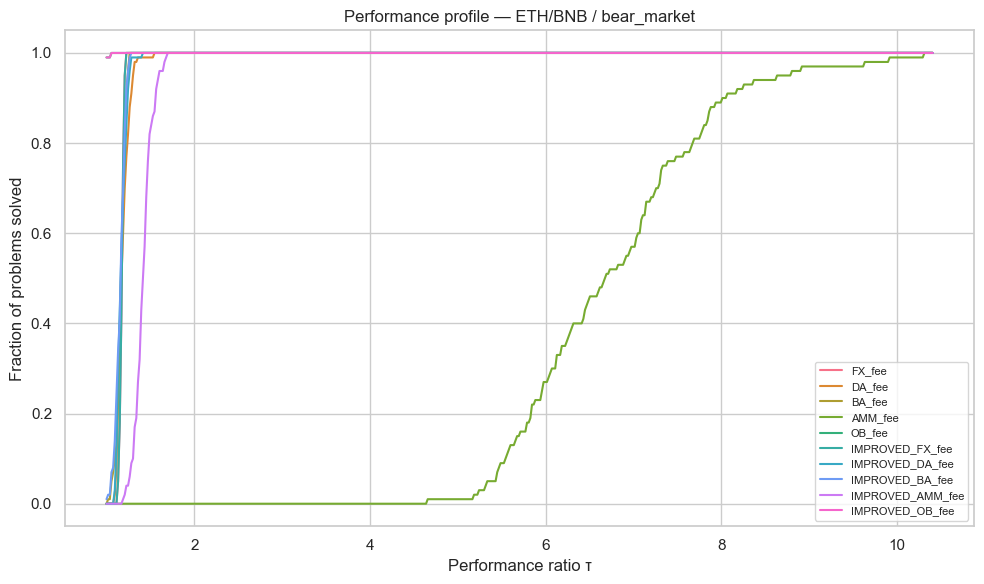

In [41]:
show_stats_for_pair_alias("ETH/BNB", "bear_market")
plot_yield_stats("ETH/BNB", "bear_market")
plot_performance_profile("ETH/BNB", "bear_market")

### Non-stable / Non-stable

#### ETH/BTC

##### volatile_market


=== ETH/BTC / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,599.40 ± 89.29,176.24 ± 11.11,3.42 ± 0.43,-8222.20 ± 316.46,722.46 ± 24.55,-56.47 ± 1.26,2835.98 ± 238.66,8.87 ± 0.85,-3120.94 ± 2076.19
BA_fee,73.55 ± 16.38,51.63 ± 8.82,1.58 ± 0.18,-8238.16 ± 289.45,723.61 ± 24.44,-56.49 ± 0.96,5195.35 ± 291.25,27.04 ± 0.99,-4538.56 ± 1672.03
DA_fee,69.84 ± 15.33,49.96 ± 9.03,1.56 ± 0.19,-8238.64 ± 301.69,723.69 ± 24.91,-56.49 ± 0.96,5177.94 ± 283.03,27.17 ± 0.99,-4252.26 ± 2211.27
FX_fee,71.21 ± 16.22,50.28 ± 8.98,1.58 ± 0.21,-8228.62 ± 297.29,723.20 ± 24.93,-56.46 ± 1.00,5183.92 ± 231.67,27.16 ± 0.19,-4370.99 ± 1941.05
IMPROVED_AMM_fee,6.93 ± 4.50,12.28 ± 3.65,0.17 ± 0.11,-8253.84 ± 355.53,722.69 ± 23.86,-56.67 ± 1.57,4375.51 ± 212.71,23.44 ± 1.38,-4698.95 ± 1906.66
IMPROVED_BA_fee,69.76 ± 16.52,49.54 ± 9.39,1.52 ± 0.20,-8238.09 ± 280.05,723.21 ± 24.20,-56.53 ± 0.99,5192.00 ± 289.07,27.14 ± 1.06,-4542.95 ± 1694.01
IMPROVED_DA_fee,88.39 ± 115.52,48.57 ± 9.57,2.08 ± 2.95,-8241.73 ± 303.21,723.44 ± 24.97,-56.53 ± 0.99,5166.09 ± 279.74,27.26 ± 1.01,-4264.08 ± 2174.10
IMPROVED_FX_fee,71.21 ± 16.22,50.28 ± 8.98,1.58 ± 0.21,-8228.62 ± 297.29,723.20 ± 24.93,-56.46 ± 1.00,5183.92 ± 231.67,27.16 ± 0.19,-4370.99 ± 1941.05
IMPROVED_OB_fee,49.79 ± 12.63,35.70 ± 9.12,1.57 ± 0.22,-8248.83 ± 296.05,723.15 ± 24.89,-56.60 ± 0.90,5374.25 ± 308.99,30.23 ± 0.47,-4522.41 ± 1804.17


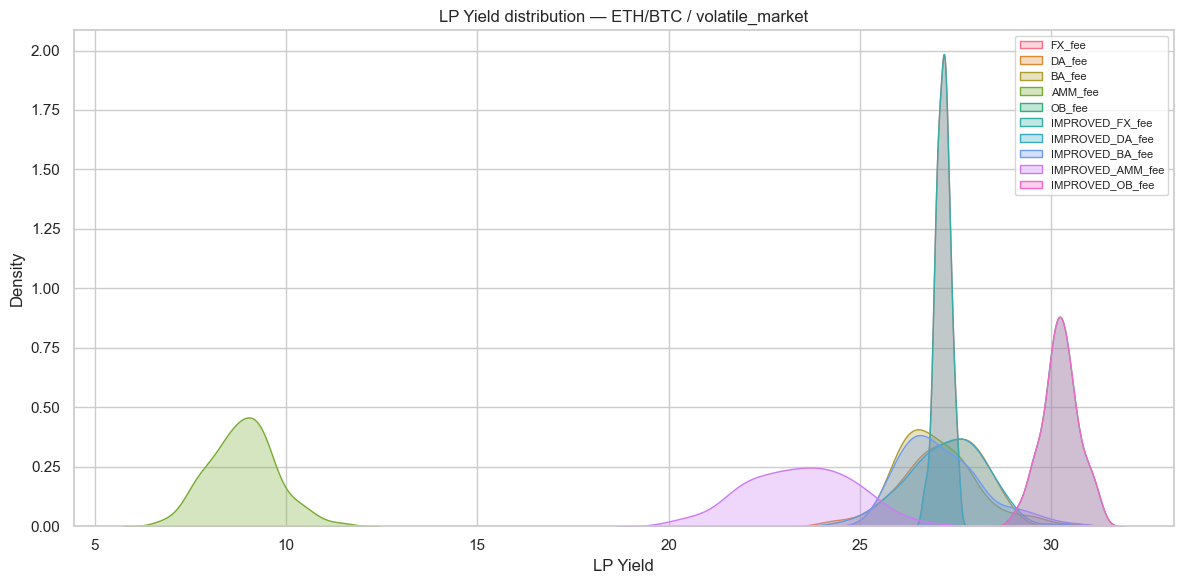

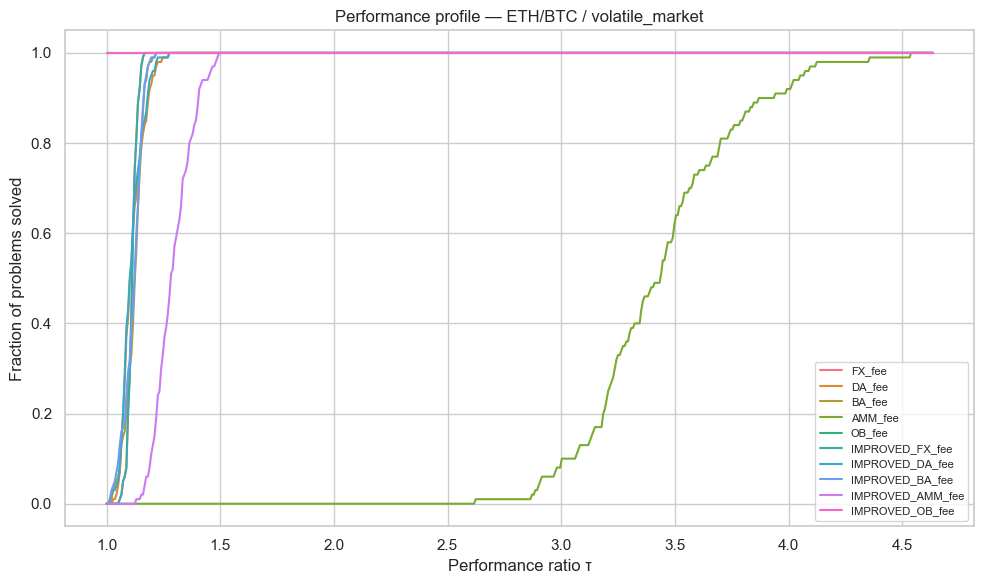

In [42]:
show_stats_for_pair_alias("ETH/BTC", "volatile_market")
plot_yield_stats("ETH/BTC", "volatile_market")
plot_performance_profile("ETH/BTC", "volatile_market")

##### bull_market


=== ETH/BTC / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,352.62 ± 58.36,142.91 ± 9.44,2.62 ± 0.37,-8168.42 ± 311.84,723.24 ± 23.86,-56.92 ± 1.12,3162.16 ± 212.18,11.39 ± 0.81,-3356.95 ± 1588.28
BA_fee,47.67 ± 12.91,39.34 ± 7.97,1.37 ± 0.21,-8161.45 ± 293.07,723.54 ± 25.13,-56.85 ± 0.99,4838.56 ± 266.73,27.17 ± 0.89,-4369.95 ± 1243.98
DA_fee,42.68 ± 11.32,37.06 ± 7.93,1.32 ± 0.19,-8163.28 ± 299.54,723.06 ± 24.54,-56.90 ± 1.04,4837.82 ± 253.14,27.52 ± 0.91,-4151.89 ± 1649.74
FX_fee,44.62 ± 13.17,37.58 ± 7.71,1.34 ± 0.20,-8162.82 ± 301.41,723.11 ± 25.05,-56.89 ± 1.02,4843.16 ± 211.24,27.46 ± 0.19,-4258.55 ± 1447.78
IMPROVED_AMM_fee,4.27 ± 2.79,9.23 ± 3.19,0.14 ± 0.10,-8173.12 ± 354.66,722.52 ± 24.22,-57.02 ± 1.70,4254.32 ± 226.52,24.50 ± 1.37,-4458.79 ± 1537.39
IMPROVED_BA_fee,44.75 ± 12.83,37.64 ± 7.93,1.32 ± 0.23,-8161.58 ± 292.65,723.39 ± 25.06,-56.86 ± 0.99,4832.58 ± 261.58,27.26 ± 0.95,-4374.50 ± 1242.42
IMPROVED_DA_fee,50.76 ± 69.85,36.41 ± 7.95,1.58 ± 1.95,-8167.10 ± 298.75,722.97 ± 24.55,-56.94 ± 1.08,4834.12 ± 246.42,27.58 ± 0.94,-4163.81 ± 1616.94
IMPROVED_FX_fee,44.62 ± 13.17,37.58 ± 7.71,1.34 ± 0.20,-8162.82 ± 301.41,723.11 ± 25.05,-56.89 ± 1.02,4843.16 ± 211.24,27.46 ± 0.19,-4258.55 ± 1447.78
IMPROVED_OB_fee,32.67 ± 11.81,26.65 ± 7.85,1.38 ± 0.25,-8169.79 ± 305.21,723.26 ± 24.29,-56.92 ± 0.89,4975.71 ± 283.55,29.80 ± 0.47,-4372.77 ± 1317.47


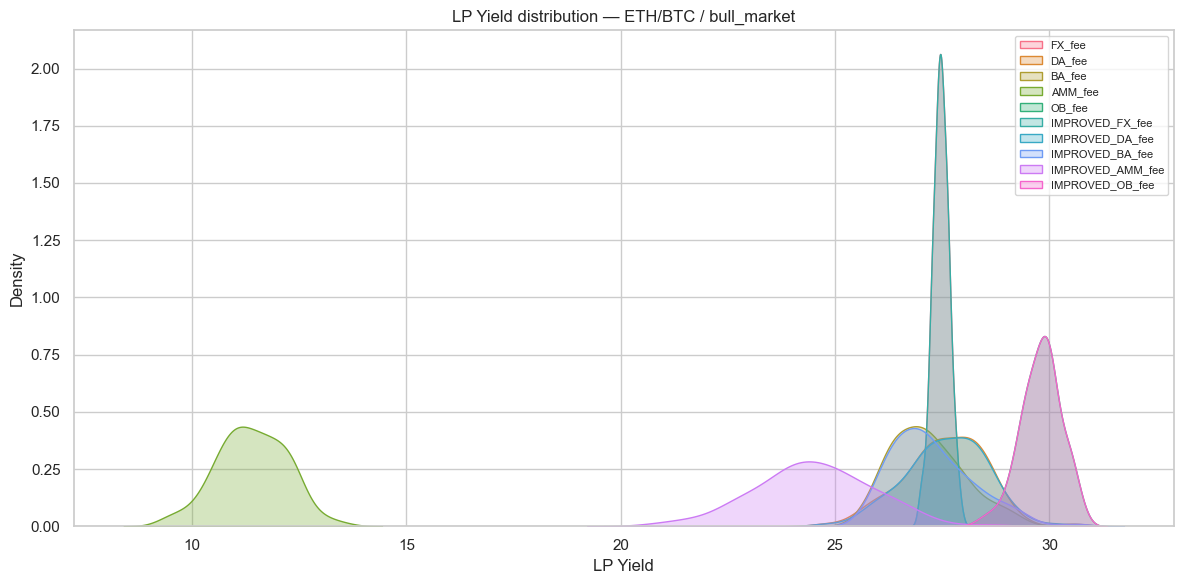

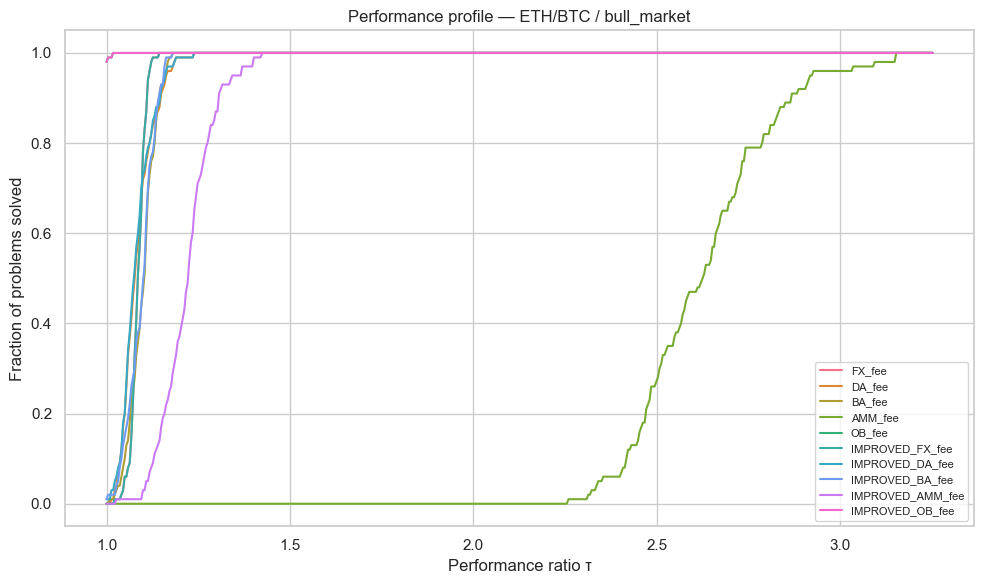

In [43]:
show_stats_for_pair_alias("ETH/BTC", "bull_market")
plot_yield_stats("ETH/BTC", "bull_market")
plot_performance_profile("ETH/BTC", "bull_market")

##### calm_market


=== ETH/BTC / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,585.15 ± 85.76,177.36 ± 10.11,3.36 ± 0.41,-8181.18 ± 294.33,722.85 ± 23.88,-56.81 ± 1.17,2809.16 ± 218.73,8.85 ± 0.80,-1719.12 ± 3092.14
BA_fee,76.89 ± 15.64,53.05 ± 8.07,1.62 ± 0.20,-8183.65 ± 291.30,723.33 ± 24.67,-56.80 ± 0.93,5231.49 ± 345.12,27.31 ± 1.24,-3390.17 ± 2503.76
DA_fee,70.10 ± 13.68,51.79 ± 8.19,1.52 ± 0.18,-8183.89 ± 296.79,722.96 ± 24.69,-56.83 ± 0.99,5102.73 ± 334.06,26.86 ± 1.40,-2740.21 ± 3386.18
FX_fee,73.36 ± 14.23,51.80 ± 8.46,1.59 ± 0.18,-8179.08 ± 287.98,723.04 ± 24.52,-56.79 ± 0.99,5156.88 ± 227.75,27.11 ± 0.18,-3021.27 ± 2932.24
IMPROVED_AMM_fee,7.69 ± 4.52,12.85 ± 3.72,0.19 ± 0.12,-8187.43 ± 370.56,723.04 ± 24.62,-56.85 ± 1.74,4341.30 ± 263.60,23.33 ± 1.50,-3344.56 ± 2866.35
IMPROVED_BA_fee,71.04 ± 16.10,50.59 ± 8.65,1.53 ± 0.23,-8181.30 ± 291.27,722.86 ± 24.43,-56.81 ± 0.96,5229.88 ± 338.26,27.46 ± 1.31,-3375.17 ± 2535.73
IMPROVED_DA_fee,135.16 ± 231.79,46.48 ± 10.92,3.18 ± 5.46,-8196.52 ± 313.97,722.57 ± 25.03,-56.95 ± 1.22,5090.27 ± 333.10,27.21 ± 1.04,-3127.74 ± 2818.14
IMPROVED_FX_fee,73.36 ± 14.23,51.80 ± 8.46,1.59 ± 0.18,-8179.08 ± 287.98,723.04 ± 24.52,-56.79 ± 0.99,5156.88 ± 227.75,27.11 ± 0.18,-3021.27 ± 2932.24
IMPROVED_OB_fee,53.51 ± 14.12,37.90 ± 8.63,1.59 ± 0.24,-8180.62 ± 296.12,722.84 ± 24.85,-56.81 ± 0.89,5377.94 ± 324.41,30.23 ± 0.48,-3256.30 ± 2753.51


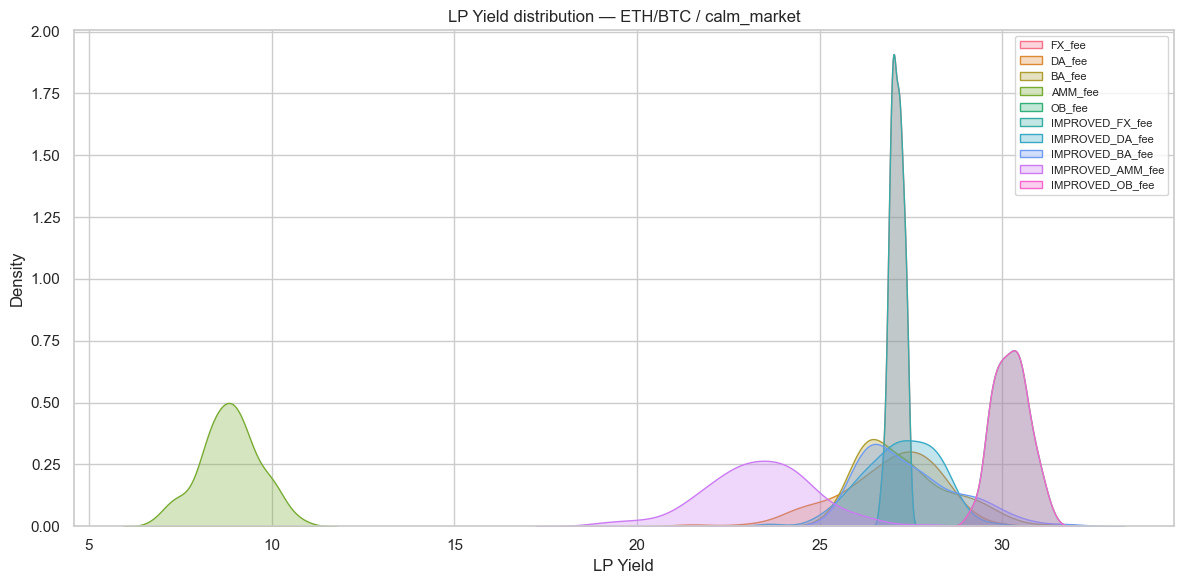

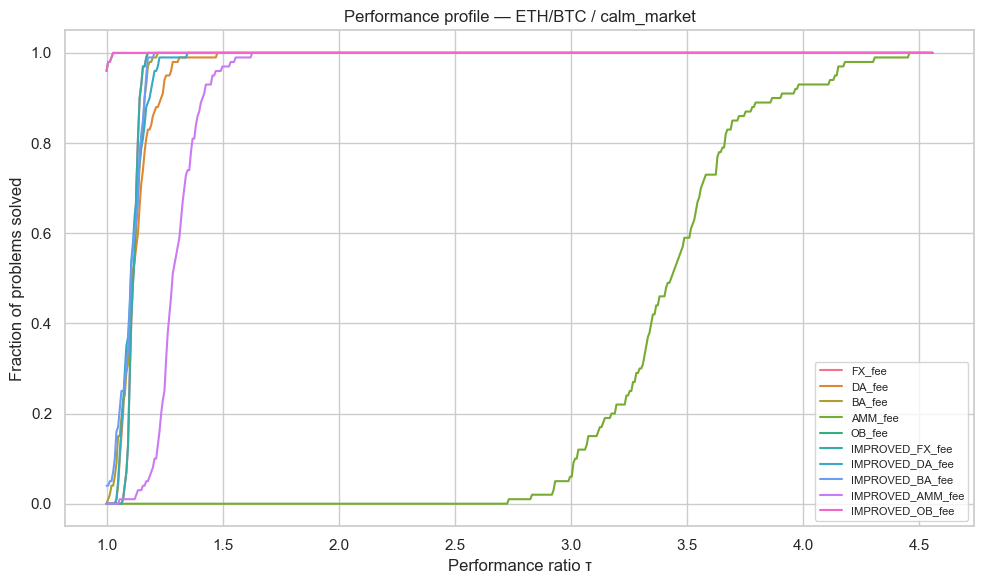

In [44]:
show_stats_for_pair_alias("ETH/BTC", "calm_market")
plot_yield_stats("ETH/BTC", "calm_market")
plot_performance_profile("ETH/BTC", "calm_market")

##### bear_market


=== ETH/BTC / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,307.31 ± 53.72,133.09 ± 9.39,2.49 ± 0.37,-8118.70 ± 294.01,722.62 ± 24.91,-57.31 ± 1.13,3196.76 ± 202.96,12.08 ± 0.88,-2557.67 ± 1936.00
BA_fee,44.08 ± 10.81,37.69 ± 7.11,1.34 ± 0.17,-8104.77 ± 287.09,723.16 ± 24.46,-57.17 ± 0.96,4782.88 ± 273.80,27.41 ± 1.01,-3670.56 ± 1512.91
DA_fee,37.40 ± 9.53,35.06 ± 7.10,1.24 ± 0.17,-8112.19 ± 292.23,722.74 ± 24.71,-57.26 ± 0.97,4728.04 ± 275.25,27.51 ± 1.14,-3267.15 ± 2090.98
FX_fee,39.69 ± 9.26,35.69 ± 7.01,1.29 ± 0.19,-8099.30 ± 292.80,722.96 ± 24.85,-57.15 ± 0.95,4744.37 ± 200.37,27.49 ± 0.17,-3429.40 ± 1800.63
IMPROVED_AMM_fee,3.79 ± 3.42,8.46 ± 2.91,0.14 ± 0.14,-8139.71 ± 340.35,722.82 ± 23.95,-57.45 ± 1.64,4201.69 ± 228.52,24.87 ± 1.38,-3593.26 ± 1828.01
IMPROVED_BA_fee,40.96 ± 11.26,36.07 ± 7.39,1.28 ± 0.23,-8104.25 ± 287.77,723.06 ± 24.08,-57.17 ± 0.97,4780.36 ± 265.42,27.51 ± 1.05,-3667.97 ± 1527.63
IMPROVED_DA_fee,70.10 ± 150.81,32.27 ± 7.78,2.38 ± 4.88,-8134.19 ± 306.63,722.83 ± 25.12,-57.41 ± 1.12,4733.40 ± 263.79,27.78 ± 0.84,-3526.77 ± 1756.11
IMPROVED_FX_fee,39.69 ± 9.26,35.69 ± 7.01,1.29 ± 0.19,-8099.30 ± 292.80,722.96 ± 24.85,-57.15 ± 0.95,4744.37 ± 200.37,27.49 ± 0.17,-3429.40 ± 1800.63
IMPROVED_OB_fee,30.32 ± 10.29,26.30 ± 7.86,1.33 ± 0.24,-8119.47 ± 292.23,723.27 ± 24.84,-57.26 ± 0.84,4905.10 ± 279.60,29.79 ± 0.47,-3633.22 ± 1621.39


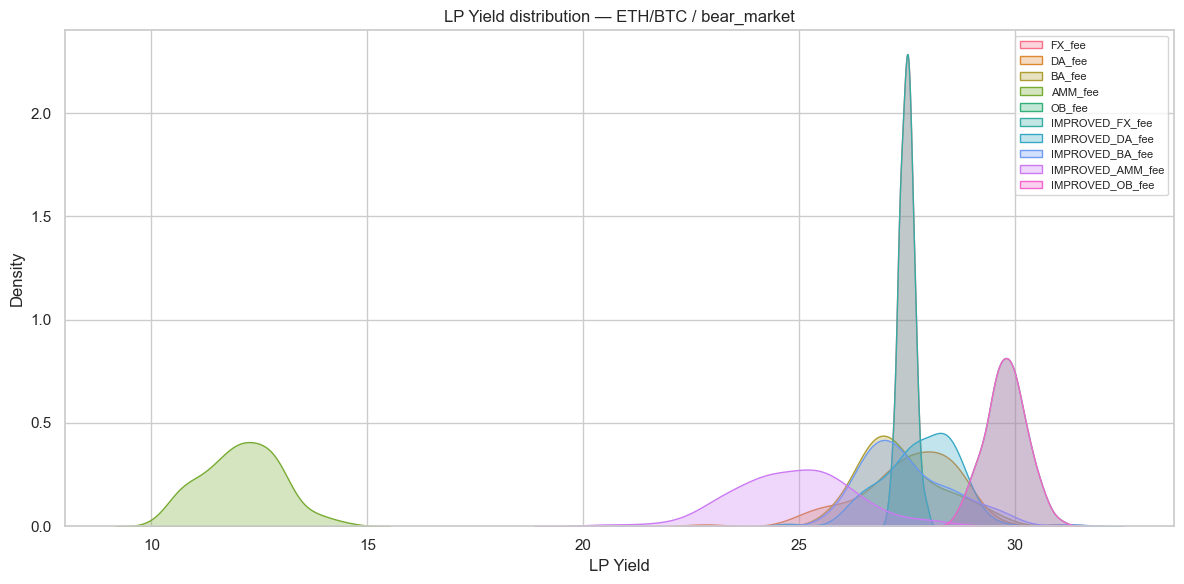

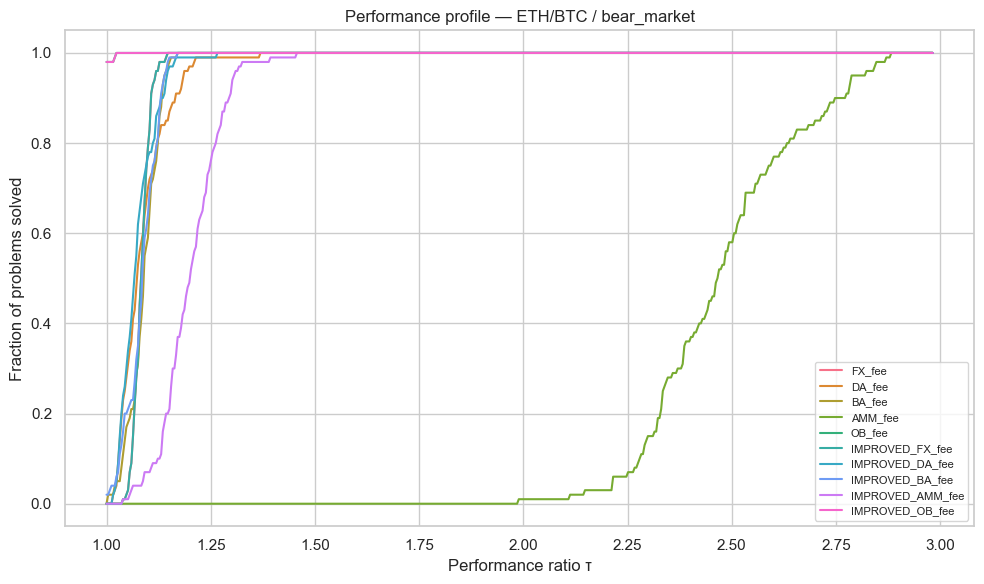

In [45]:
show_stats_for_pair_alias("ETH/BTC", "bear_market")
plot_yield_stats("ETH/BTC", "bear_market")
plot_performance_profile("ETH/BTC", "bear_market")

#### BNB/ETH

##### volatile_market


=== BNB/ETH / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,1367.07 ± 169.58,248.61 ± 11.71,5.09 ± 0.56,-8252.91 ± 306.56,722.71 ± 24.16,-56.66 ± 1.07,1837.78 ± 267.69,4.45 ± 0.69,-1863.21 ± 3581.31
BA_fee,159.15 ± 25.47,82.98 ± 11.25,2.06 ± 0.17,-8240.37 ± 289.67,723.23 ± 24.64,-56.54 ± 0.87,5948.52 ± 437.82,26.69 ± 1.27,-4301.16 ± 2931.21
DA_fee,155.29 ± 28.02,84.19 ± 12.45,1.99 ± 0.18,-8251.23 ± 299.33,723.01 ± 24.37,-56.63 ± 0.87,5843.74 ± 399.90,26.16 ± 1.29,-3702.98 ± 4020.00
FX_fee,158.99 ± 28.19,83.12 ± 11.45,2.06 ± 0.19,-8242.07 ± 287.88,722.99 ± 24.44,-56.57 ± 0.84,5893.40 ± 291.03,26.44 ± 0.20,-3998.62 ± 3443.36
IMPROVED_AMM_fee,19.05 ± 9.07,22.12 ± 5.20,0.27 ± 0.13,-8283.12 ± 334.68,723.42 ± 24.88,-56.83 ± 1.54,4605.47 ± 301.45,21.44 ± 1.42,-4437.23 ± 3498.09
IMPROVED_BA_fee,146.86 ± 26.42,78.97 ± 11.35,1.94 ± 0.23,-8248.75 ± 299.90,723.30 ± 24.98,-56.60 ± 0.90,5946.75 ± 430.03,26.85 ± 1.41,-4328.16 ± 2987.99
IMPROVED_DA_fee,210.13 ± 271.40,77.43 ± 16.33,3.02 ± 4.39,-8270.00 ± 305.33,722.60 ± 24.28,-56.79 ± 1.02,5799.54 ± 414.12,26.41 ± 1.11,-3906.55 ± 3556.49
IMPROVED_FX_fee,158.99 ± 28.19,83.12 ± 11.45,2.06 ± 0.19,-8242.07 ± 287.88,722.99 ± 24.44,-56.57 ± 0.84,5893.40 ± 291.03,26.44 ± 0.20,-3998.62 ± 3443.36
IMPROVED_OB_fee,115.97 ± 27.24,59.37 ± 11.19,2.09 ± 0.26,-8244.90 ± 291.57,723.22 ± 24.61,-56.57 ± 0.82,6219.09 ± 416.51,30.92 ± 0.48,-4229.57 ± 3343.88


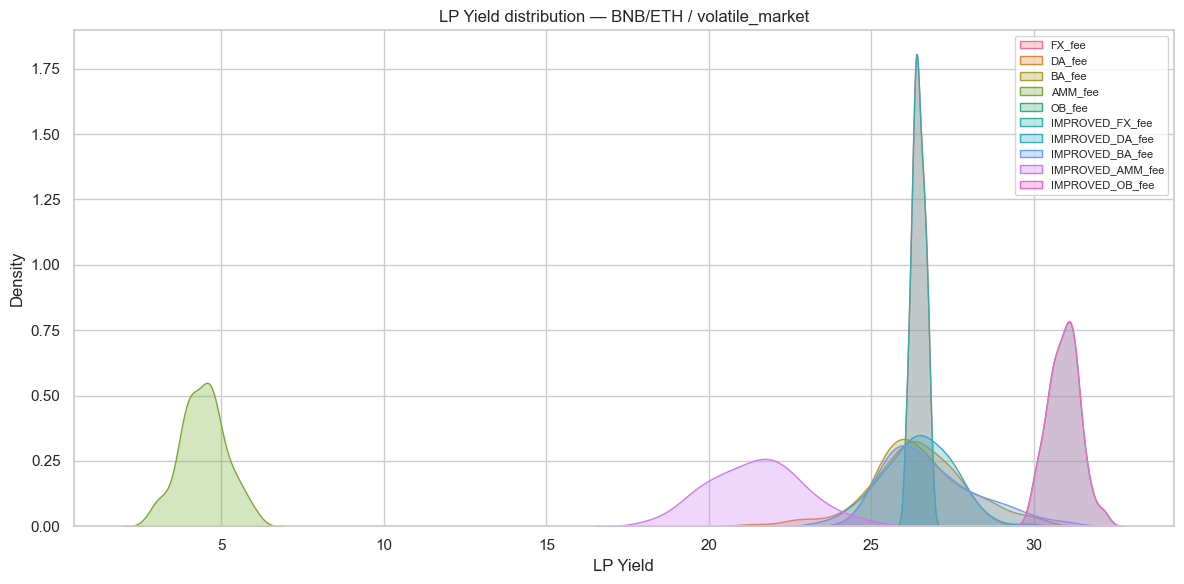

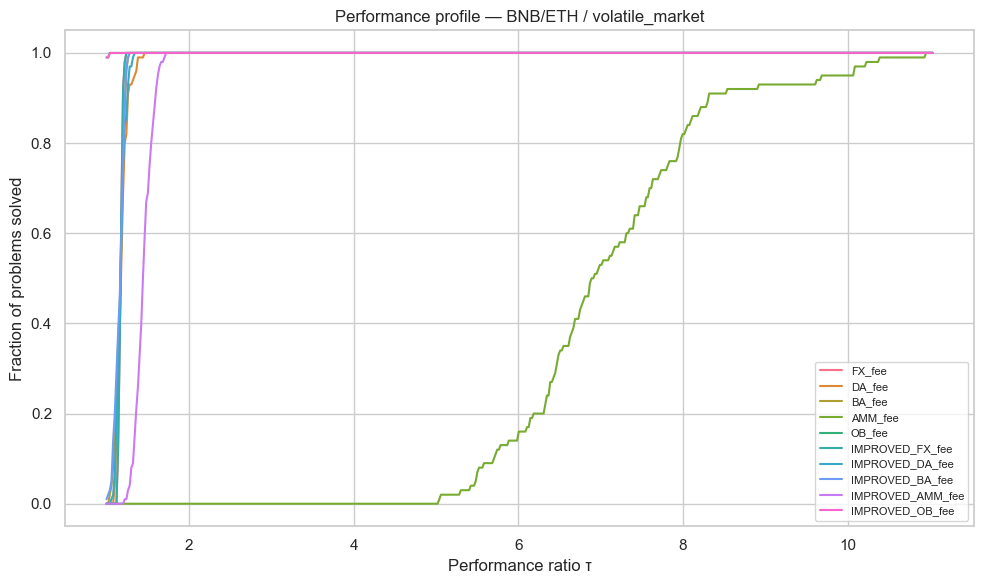

In [46]:
show_stats_for_pair_alias("BNB/ETH", "volatile_market")
plot_yield_stats("BNB/ETH", "volatile_market")
plot_performance_profile("BNB/ETH", "volatile_market")

##### bull_market


=== BNB/ETH / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,771.59 ± 109.07,197.55 ± 10.83,3.88 ± 0.48,-8188.52 ± 312.18,723.15 ± 23.77,-56.99 ± 1.13,2547.99 ± 248.48,7.45 ± 0.80,-2782.50 ± 2243.79
BA_fee,92.46 ± 20.35,59.46 ± 9.96,1.72 ± 0.20,-8176.22 ± 289.03,723.36 ± 24.96,-56.89 ± 0.93,5301.76 ± 354.87,26.88 ± 1.11,-4386.22 ± 1779.49
DA_fee,88.61 ± 19.72,58.24 ± 10.25,1.69 ± 0.19,-8186.97 ± 295.59,723.11 ± 24.58,-56.99 ± 0.88,5255.90 ± 311.79,26.84 ± 1.11,-3997.07 ± 2503.48
FX_fee,90.48 ± 18.27,58.35 ± 10.18,1.72 ± 0.18,-8179.70 ± 284.08,723.33 ± 24.17,-56.92 ± 0.91,5287.17 ± 259.06,26.95 ± 0.20,-4205.34 ± 2127.88
IMPROVED_AMM_fee,9.61 ± 5.16,14.73 ± 4.22,0.20 ± 0.10,-8200.12 ± 343.49,722.99 ± 24.60,-57.09 ± 1.52,4382.52 ± 256.96,22.96 ± 1.52,-4529.20 ± 2195.35
IMPROVED_BA_fee,86.55 ± 19.11,56.34 ± 9.65,1.65 ± 0.22,-8187.58 ± 294.52,723.31 ± 24.91,-56.97 ± 0.99,5298.79 ± 354.64,27.02 ± 1.20,-4403.39 ± 1782.66
IMPROVED_DA_fee,118.10 ± 161.39,54.83 ± 11.49,2.41 ± 3.40,-8197.33 ± 294.16,722.83 ± 24.68,-57.09 ± 1.03,5234.87 ± 317.42,27.00 ± 1.01,-4096.40 ± 2259.90
IMPROVED_FX_fee,90.48 ± 18.27,58.35 ± 10.18,1.72 ± 0.18,-8179.70 ± 284.08,723.33 ± 24.17,-56.92 ± 0.91,5287.17 ± 259.06,26.95 ± 0.20,-4205.34 ± 2127.88
IMPROVED_OB_fee,64.27 ± 17.24,41.76 ± 9.14,1.71 ± 0.24,-8185.16 ± 289.34,723.58 ± 24.69,-56.93 ± 0.84,5503.26 ± 318.37,30.34 ± 0.46,-4370.63 ± 2031.58


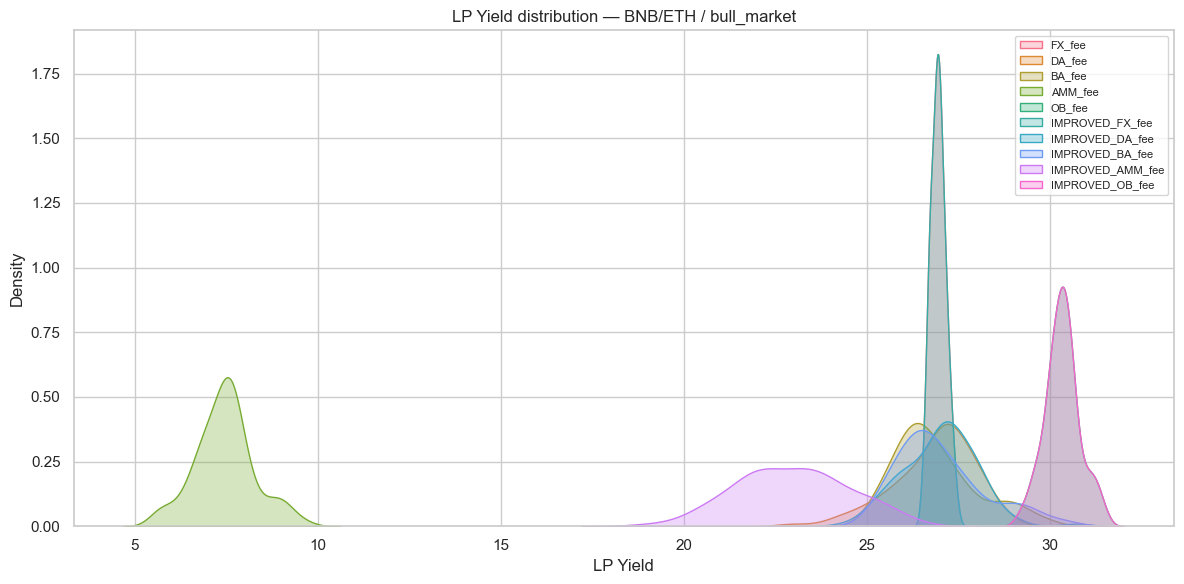

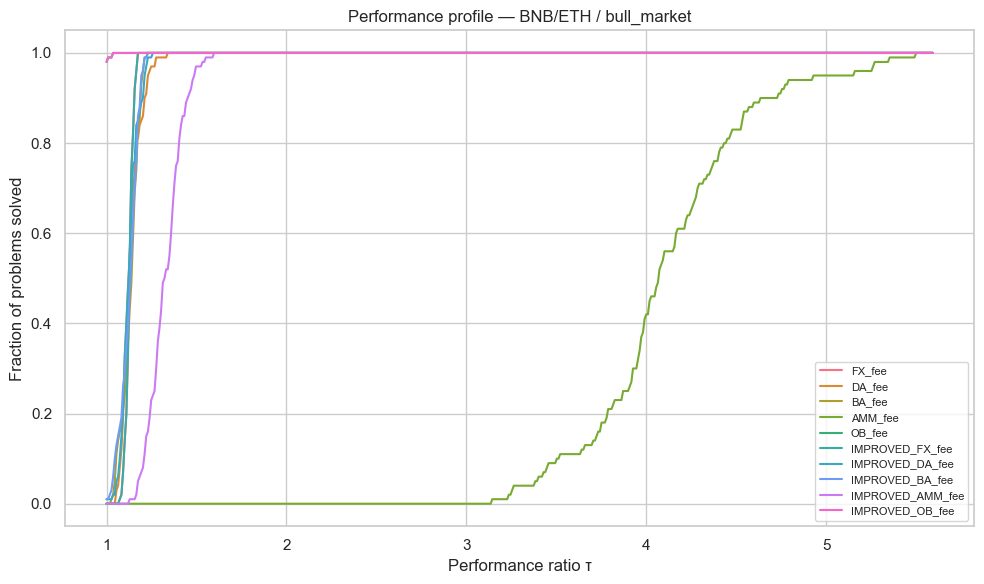

In [47]:
show_stats_for_pair_alias("BNB/ETH", "bull_market")
plot_yield_stats("BNB/ETH", "bull_market")
plot_performance_profile("BNB/ETH", "bull_market")

##### calm_market


=== BNB/ETH / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,810.50 ± 109.13,199.87 ± 9.81,4.00 ± 0.48,-8154.73 ± 309.24,723.13 ± 24.53,-56.78 ± 1.13,2468.90 ± 238.25,7.14 ± 0.73,-2611.61 ± 2493.15
BA_fee,96.04 ± 18.09,60.57 ± 9.34,1.76 ± 0.19,-8173.76 ± 293.59,723.26 ± 24.64,-56.91 ± 0.91,5334.77 ± 334.28,26.91 ± 1.11,-4284.54 ± 2034.96
DA_fee,91.72 ± 18.96,60.33 ± 9.97,1.69 ± 0.18,-8178.86 ± 299.50,723.20 ± 24.47,-56.96 ± 0.94,5289.49 ± 314.96,26.76 ± 1.05,-3890.55 ± 2734.84
FX_fee,93.34 ± 18.21,60.26 ± 9.83,1.72 ± 0.17,-8171.32 ± 300.85,723.27 ± 24.86,-56.89 ± 0.93,5323.32 ± 254.51,26.92 ± 0.20,-4085.61 ± 2420.94
IMPROVED_AMM_fee,10.14 ± 5.07,15.03 ± 4.21,0.22 ± 0.11,-8187.56 ± 340.00,722.99 ± 24.53,-57.03 ± 1.61,4387.87 ± 225.62,22.96 ± 1.67,-4431.22 ± 2397.45
IMPROVED_BA_fee,89.67 ± 18.60,57.57 ± 8.98,1.68 ± 0.23,-8175.57 ± 291.33,723.08 ± 24.66,-56.94 ± 0.94,5327.13 ± 330.61,27.06 ± 1.21,-4286.23 ± 2059.87
IMPROVED_DA_fee,112.60 ± 129.22,57.74 ± 11.00,2.18 ± 2.69,-8191.27 ± 307.51,723.18 ± 24.48,-57.04 ± 1.09,5274.36 ± 319.43,26.90 ± 1.06,-3929.65 ± 2662.35
IMPROVED_FX_fee,93.34 ± 18.21,60.26 ± 9.83,1.72 ± 0.17,-8171.32 ± 300.85,723.27 ± 24.86,-56.89 ± 0.93,5323.32 ± 254.51,26.92 ± 0.20,-4085.61 ± 2420.94
IMPROVED_OB_fee,66.98 ± 17.17,43.00 ± 9.55,1.73 ± 0.23,-8182.48 ± 291.17,723.83 ± 25.02,-56.93 ± 0.82,5546.77 ± 324.51,30.39 ± 0.46,-4275.92 ± 2274.96


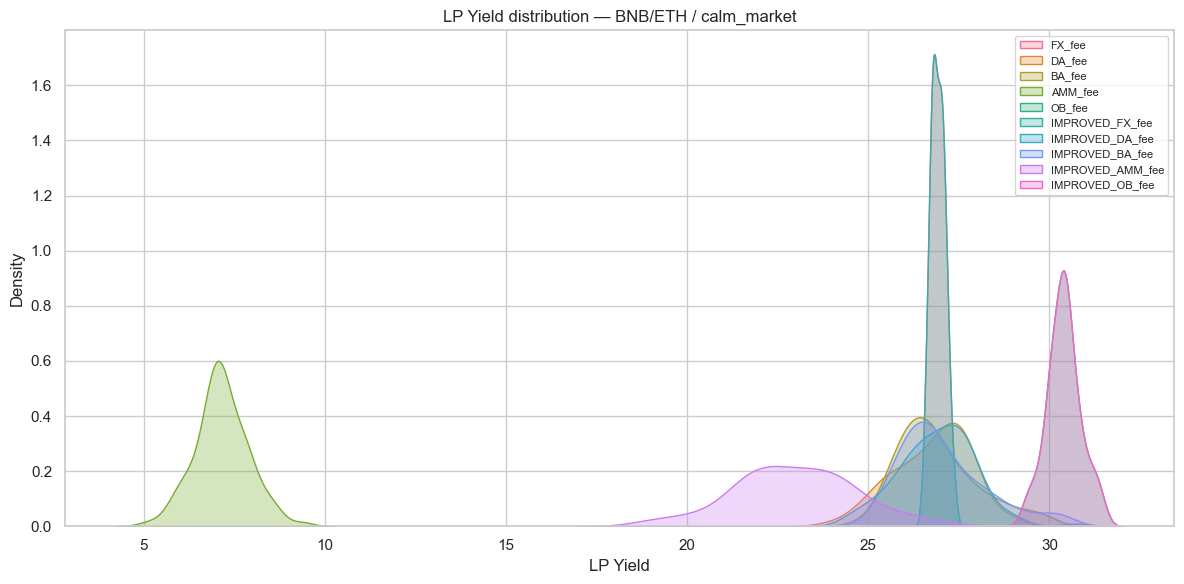

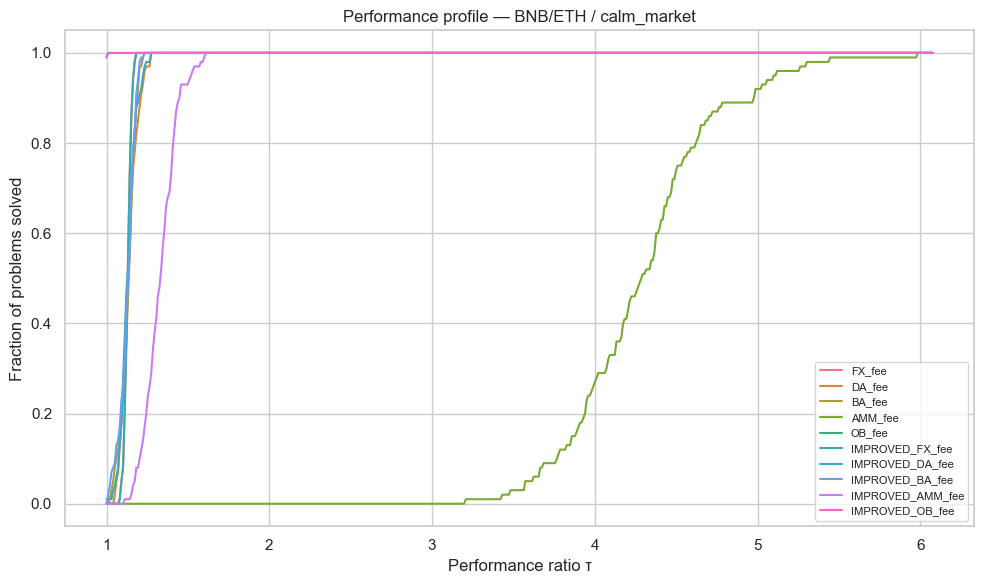

In [48]:
show_stats_for_pair_alias("BNB/ETH", "calm_market")
plot_yield_stats("BNB/ETH", "calm_market")
plot_performance_profile("BNB/ETH", "calm_market")

##### bear_market


=== BNB/ETH / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,1252.12 ± 149.85,238.81 ± 12.85,4.99 ± 0.49,-8068.22 ± 290.05,722.99 ± 24.20,-57.35 ± 1.00,1821.44 ± 238.34,4.67 ± 0.68,-1438.39 ± 3591.81
BA_fee,151.85 ± 24.81,80.37 ± 10.51,2.07 ± 0.19,-8082.83 ± 292.19,723.29 ± 24.30,-57.43 ± 1.01,5709.56 ± 382.32,26.69 ± 1.24,-3728.29 ± 3066.67
DA_fee,147.84 ± 22.30,81.75 ± 10.40,2.00 ± 0.15,-8093.85 ± 298.19,723.38 ± 24.62,-57.50 ± 1.03,5627.65 ± 387.71,26.19 ± 1.34,-3181.39 ± 3905.27
FX_fee,148.85 ± 25.40,81.04 ± 10.49,2.02 ± 0.17,-8072.62 ± 290.51,722.39 ± 24.34,-57.42 ± 1.00,5659.03 ± 264.46,26.43 ± 0.19,-3423.80 ± 3483.09
IMPROVED_AMM_fee,20.87 ± 9.84,22.78 ± 4.76,0.32 ± 0.15,-8094.29 ± 363.84,722.54 ± 23.91,-57.56 ± 1.81,4527.00 ± 256.58,21.96 ± 1.50,-3966.33 ± 3441.06
IMPROVED_BA_fee,139.06 ± 27.29,75.95 ± 11.34,1.94 ± 0.23,-8087.76 ± 292.54,723.43 ± 24.28,-57.46 ± 1.04,5702.30 ± 375.04,26.89 ± 1.35,-3751.02 ± 3080.44
IMPROVED_DA_fee,217.15 ± 265.59,74.96 ± 15.50,3.39 ± 4.65,-8100.29 ± 306.00,723.08 ± 24.77,-57.57 ± 1.10,5591.71 ± 410.57,26.50 ± 1.06,-3485.54 ± 3420.08
IMPROVED_FX_fee,148.85 ± 25.40,81.04 ± 10.49,2.02 ± 0.17,-8072.62 ± 290.51,722.39 ± 24.34,-57.42 ± 1.00,5659.03 ± 264.46,26.43 ± 0.19,-3423.80 ± 3483.09
IMPROVED_OB_fee,106.70 ± 22.56,58.71 ± 10.38,2.00 ± 0.21,-8082.94 ± 290.32,723.55 ± 25.01,-57.41 ± 0.90,6009.22 ± 368.12,30.95 ± 0.44,-3671.26 ± 3367.40


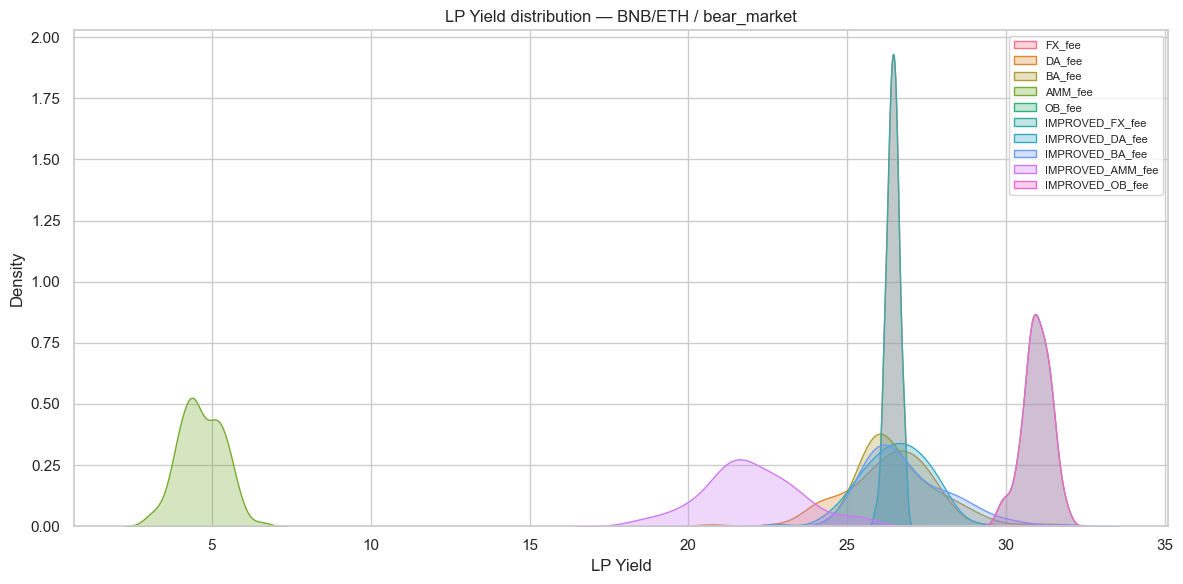

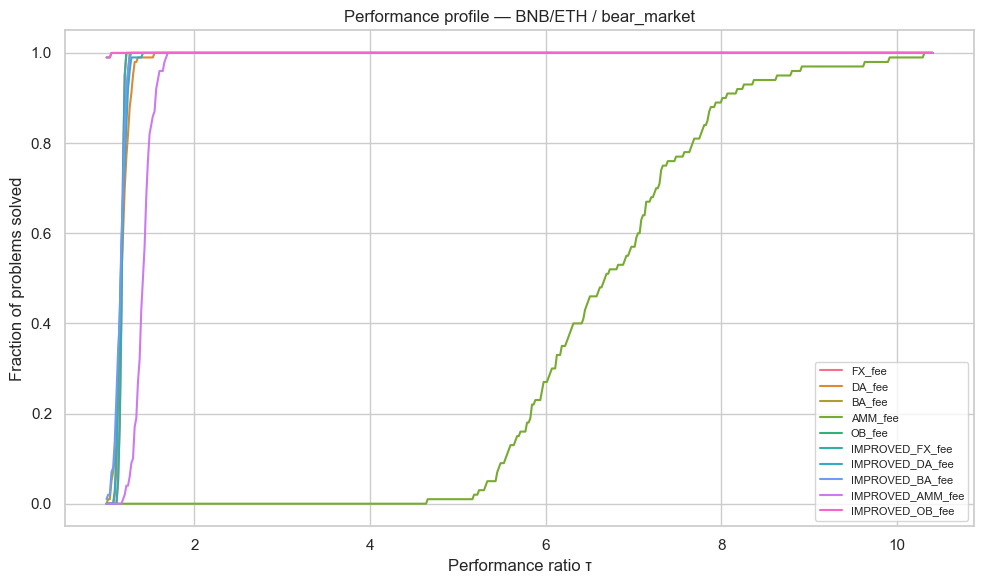

In [49]:
show_stats_for_pair_alias("BNB/ETH", "bear_market")
plot_yield_stats("BNB/ETH", "bear_market")
plot_performance_profile("BNB/ETH", "bear_market")

#### DOGE/BTC

##### volatile_market


=== DOGE/BTC / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,20084.58 ± 1444.61,344.11 ± 31.73,22.61 ± 1.03,-8391.75 ± 379.62,722.60 ± 24.63,-55.69 ± 1.74,-5172.37 ± 2132.82,-4.96 ± 1.99,91707.37 ± 124604.70
BA_fee,10264.47 ± 946.78,396.48 ± 36.00,14.58 ± 1.45,-8385.19 ± 379.39,722.60 ± 24.86,-55.63 ± 1.51,14854.37 ± 3811.11,17.23 ± 3.80,79260.22 ± 120238.63
DA_fee,9528.02 ± 1177.43,438.05 ± 42.43,12.48 ± 1.49,-8389.52 ± 338.61,722.39 ± 24.11,-55.68 ± 1.39,14794.72 ± 2437.28,16.18 ± 2.56,82635.86 ± 127465.45
FX_fee,8216.21 ± 837.77,478.18 ± 72.42,10.52 ± 1.54,-8395.35 ± 340.83,722.98 ± 24.05,-55.66 ± 1.27,17321.91 ± 2132.56,18.39 ± 1.05,80131.82 ± 123397.10
IMPROVED_AMM_fee,1484.35 ± 231.64,267.20 ± 21.72,2.11 ± 0.31,-8456.03 ± 405.90,722.53 ± 24.18,-56.09 ± 1.60,14699.34 ± 1385.11,17.19 ± 1.50,71750.81 ± 122919.65
IMPROVED_BA_fee,4639.07 ± 679.04,372.43 ± 31.23,6.91 ± 0.88,-8427.88 ± 394.25,722.65 ± 24.40,-55.90 ± 1.52,20229.92 ± 3159.71,24.57 ± 3.22,73882.17 ± 121146.47
IMPROVED_DA_fee,8467.50 ± 2219.27,424.96 ± 64.44,11.62 ± 4.32,-8394.64 ± 346.55,722.32 ± 24.22,-55.72 ± 1.48,16195.20 ± 1690.08,18.13 ± 1.43,80165.86 ± 124986.17
IMPROVED_FX_fee,8215.45 ± 836.85,478.18 ± 72.42,10.52 ± 1.54,-8395.35 ± 340.83,722.98 ± 24.05,-55.66 ± 1.27,17322.68 ± 2131.93,18.39 ± 1.05,80131.03 ± 123397.58
IMPROVED_OB_fee,4123.54 ± 349.03,482.68 ± 28.93,6.70 ± 0.22,-8400.21 ± 343.38,723.02 ± 24.58,-55.69 ± 1.22,25453.08 ± 1678.61,33.21 ± 0.19,75709.01 ± 123773.15


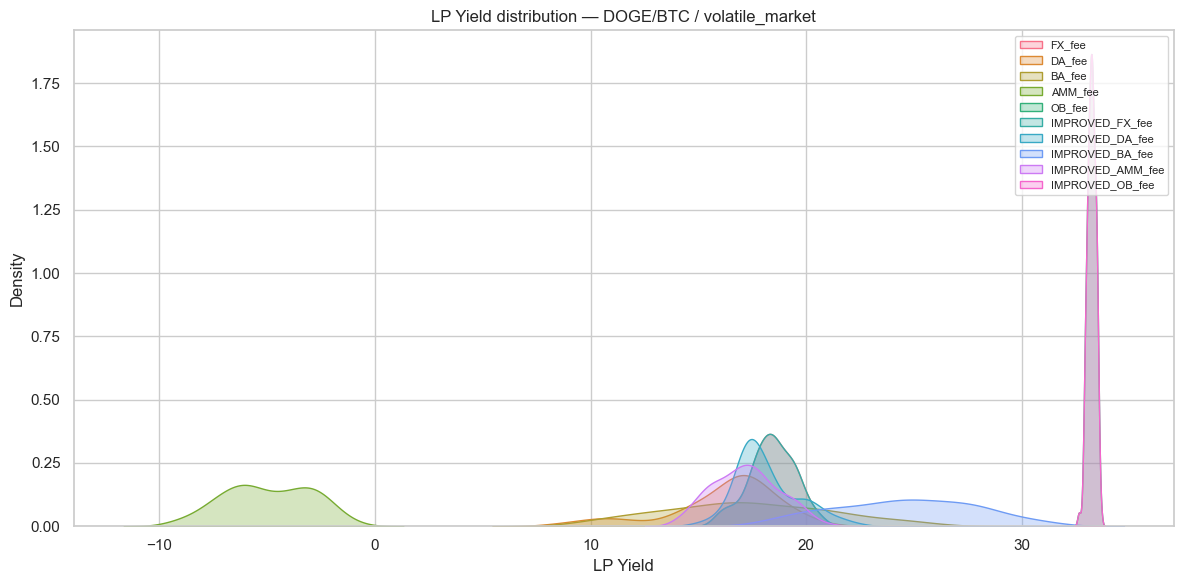

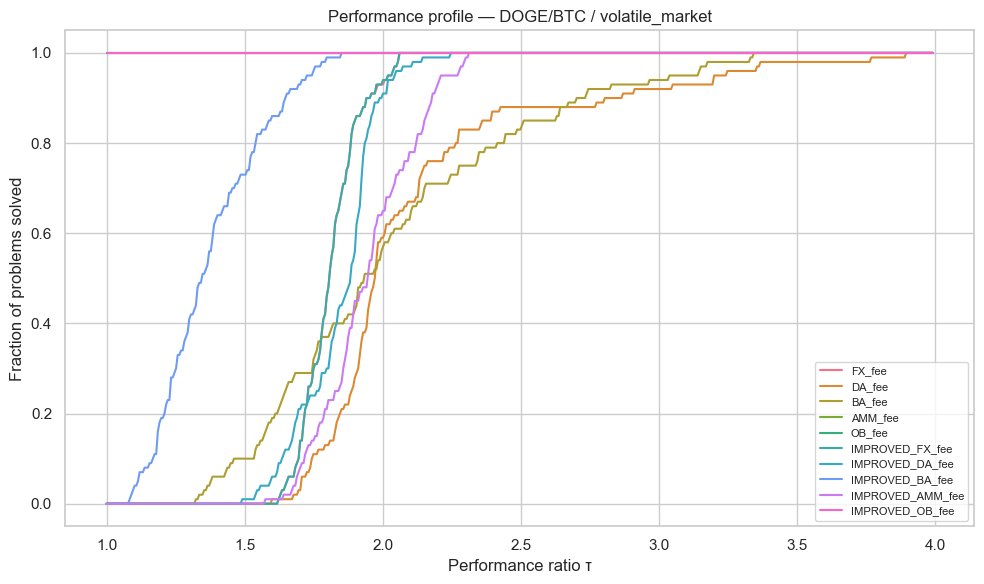

In [50]:
show_stats_for_pair_alias("DOGE/BTC", "volatile_market")
plot_yield_stats("DOGE/BTC", "volatile_market")
plot_performance_profile("DOGE/BTC", "volatile_market")

##### bull_market


=== DOGE/BTC / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,6096.36 ± 627.36,100.61 ± 10.22,22.04 ± 0.66,-8120.94 ± 342.14,722.35 ± 24.90,-56.90 ± 1.61,-1512.28 ± 693.91,-3.54 ± 1.47,2656.50 ± 10196.77
BA_fee,1578.39 ± 262.99,134.12 ± 17.49,9.01 ± 1.37,-8140.58 ± 319.30,722.78 ± 24.70,-56.98 ± 1.08,7304.24 ± 901.41,22.91 ± 2.41,-2132.88 ± 9452.48
DA_fee,1394.46 ± 314.22,147.56 ± 20.93,7.50 ± 1.58,-8148.65 ± 324.13,722.70 ± 24.54,-57.05 ± 1.13,7390.74 ± 765.06,22.43 ± 1.74,-1600.21 ± 10809.71
FX_fee,815.29 ± 141.00,184.46 ± 19.64,4.16 ± 0.68,-8151.08 ± 307.40,723.29 ± 25.01,-57.02 ± 1.04,8229.20 ± 493.72,24.25 ± 0.34,-2195.37 ± 10313.89
IMPROVED_AMM_fee,120.99 ± 34.95,63.77 ± 9.90,0.71 ± 0.20,-8177.53 ± 341.56,722.90 ± 24.76,-57.24 ± 1.77,5851.00 ± 511.52,18.62 ± 1.72,-3527.79 ± 10368.14
IMPROVED_BA_fee,800.45 ± 195.21,131.16 ± 17.27,4.62 ± 0.96,-8160.60 ± 321.53,723.21 ± 24.87,-57.09 ± 1.09,8064.35 ± 870.18,25.55 ± 2.43,-2918.04 ± 9530.59
IMPROVED_DA_fee,1291.52 ± 323.25,146.22 ± 22.64,7.05 ± 2.05,-8152.79 ± 327.67,722.66 ± 24.57,-57.08 ± 1.15,7502.98 ± 720.42,22.87 ± 1.46,-1809.15 ± 10667.98
IMPROVED_FX_fee,815.29 ± 141.00,184.46 ± 19.64,4.16 ± 0.68,-8151.08 ± 307.40,723.29 ± 25.01,-57.02 ± 1.04,8229.20 ± 493.72,24.25 ± 0.34,-2195.37 ± 10313.89
IMPROVED_OB_fee,479.50 ± 69.07,143.83 ± 18.05,3.33 ± 0.25,-8158.09 ± 314.43,723.56 ± 25.19,-57.05 ± 0.94,9362.66 ± 714.59,32.60 ± 0.39,-2807.26 ± 10260.97


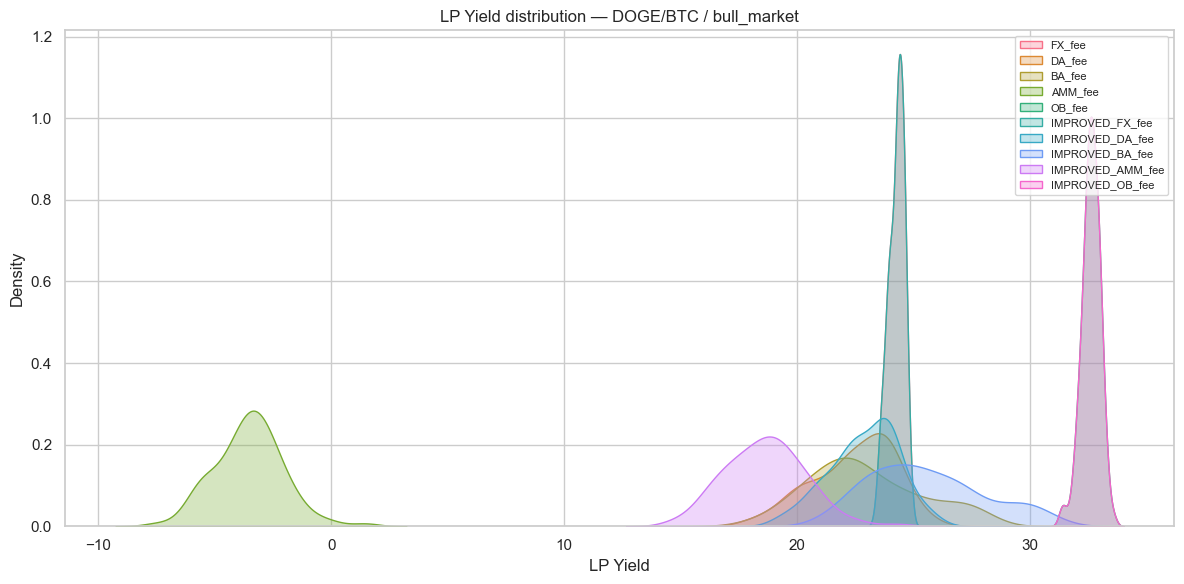

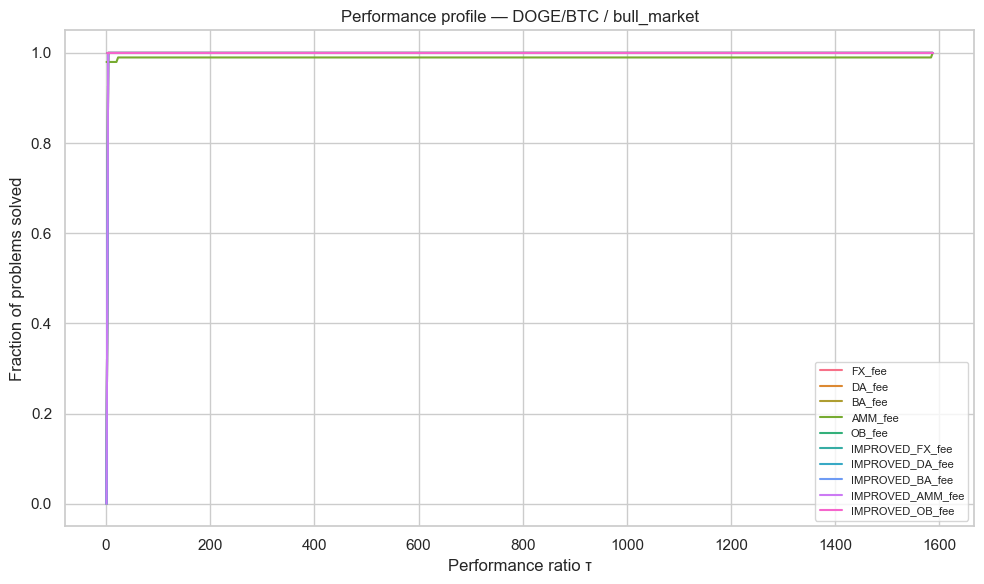

In [51]:
show_stats_for_pair_alias("DOGE/BTC", "bull_market")
plot_yield_stats("DOGE/BTC", "bull_market")
plot_performance_profile("DOGE/BTC", "bull_market")

##### calm_market


=== DOGE/BTC / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,3143.11 ± 458.47,37.22 ± 5.91,26.15 ± 0.66,-8156.34 ± 350.01,723.14 ± 24.39,-56.85 ± 1.54,1107.68 ± 495.36,4.31 ± 2.06,2715.87 ± 8892.55
BA_fee,887.16 ± 252.33,60.50 ± 13.13,10.55 ± 2.38,-8183.15 ± 298.57,723.28 ± 23.50,-57.03 ± 1.19,5600.39 ± 698.39,24.65 ± 2.99,35.16 ± 8104.89
DA_fee,953.69 ± 263.13,56.52 ± 9.31,11.01 ± 2.13,-8168.21 ± 318.43,723.31 ± 24.65,-56.91 ± 1.04,5294.09 ± 514.24,23.10 ± 2.13,712.22 ± 8965.05
FX_fee,891.24 ± 153.28,53.56 ± 8.38,10.17 ± 0.64,-8166.72 ± 300.05,722.95 ± 24.45,-56.94 ± 1.07,5555.91 ± 284.85,24.06 ± 0.52,385.88 ± 8762.46
IMPROVED_AMM_fee,32.65 ± 15.06,29.73 ± 7.21,0.38 ± 0.17,-8170.35 ± 332.24,722.95 ± 24.53,-56.97 ± 1.83,4782.97 ± 335.97,20.85 ± 1.65,-570.15 ± 8411.83
IMPROVED_BA_fee,514.52 ± 208.67,59.60 ± 12.99,6.25 ± 2.50,-8186.53 ± 300.92,723.13 ± 23.67,-57.06 ± 1.24,5968.04 ± 687.22,26.38 ± 2.85,-302.04 ± 8178.09
IMPROVED_DA_fee,803.90 ± 187.85,56.50 ± 9.28,9.31 ± 1.34,-8168.47 ± 319.36,723.28 ± 24.69,-56.91 ± 1.04,5442.79 ± 449.58,23.75 ± 1.76,564.17 ± 8902.89
IMPROVED_FX_fee,891.24 ± 153.28,53.56 ± 8.38,10.17 ± 0.64,-8166.72 ± 300.05,722.95 ± 24.45,-56.94 ± 1.07,5555.91 ± 284.85,24.06 ± 0.52,385.88 ± 8762.46
IMPROVED_OB_fee,167.56 ± 34.27,76.75 ± 14.06,2.33 ± 0.21,-8177.81 ± 306.60,723.60 ± 25.89,-56.96 ± 0.98,6777.68 ± 471.69,31.43 ± 0.42,-264.18 ± 8528.55


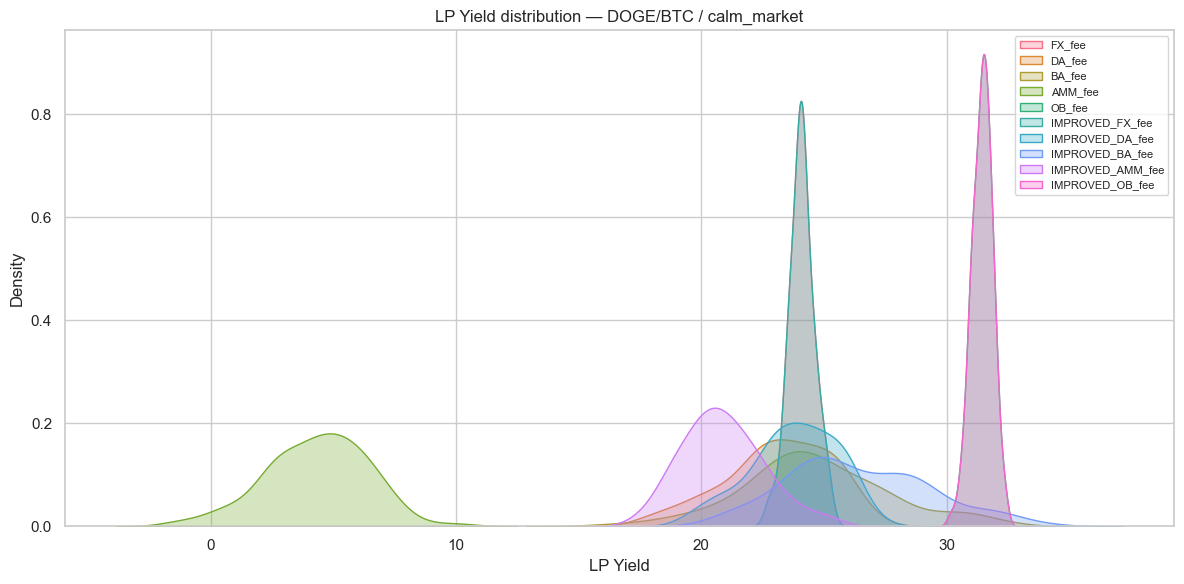

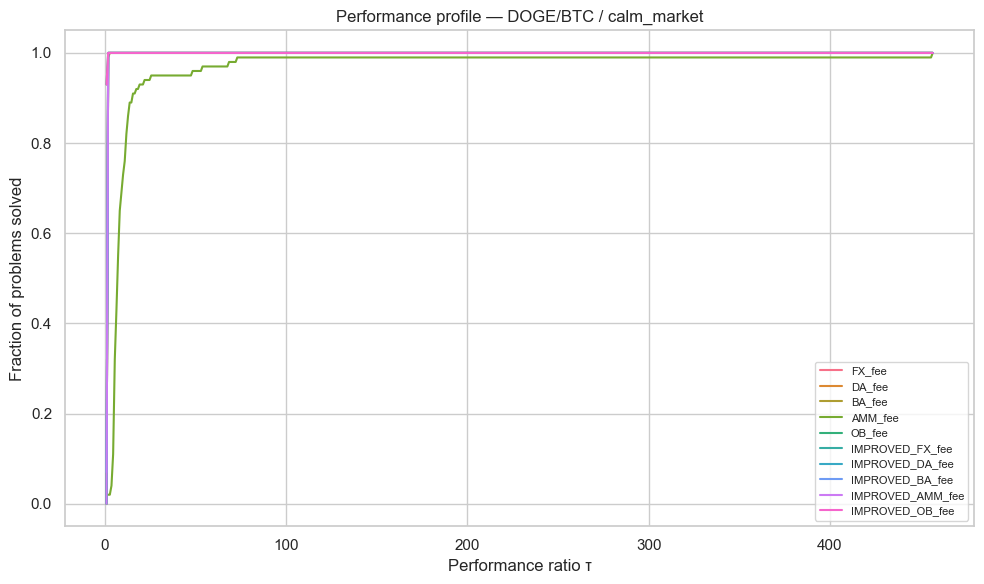

In [52]:
show_stats_for_pair_alias("DOGE/BTC", "calm_market")
plot_yield_stats("DOGE/BTC", "calm_market")
plot_performance_profile("DOGE/BTC", "calm_market")

##### bear_market


=== DOGE/BTC / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,11041.81 ± 878.08,274.88 ± 20.03,18.10 ± 0.57,-8060.90 ± 357.09,721.94 ± 24.20,-57.48 ± 1.48,-4331.45 ± 974.85,-5.74 ± 1.09,16943.29 ± 30171.42
BA_fee,2961.79 ± 408.83,306.29 ± 31.67,7.70 ± 1.11,-8068.30 ± 314.07,723.30 ± 24.02,-57.42 ± 1.22,11840.13 ± 1146.71,22.49 ± 1.84,8095.57 ± 29205.29
DA_fee,2740.71 ± 438.48,334.26 ± 30.30,6.71 ± 0.98,-8066.69 ± 325.91,722.91 ± 24.69,-57.43 ± 1.06,11457.17 ± 1175.24,20.84 ± 1.66,9792.31 ± 31461.75
FX_fee,2027.27 ± 168.14,384.11 ± 24.86,4.85 ± 0.20,-8063.35 ± 323.76,722.80 ± 24.17,-57.41 ± 1.18,12606.58 ± 676.31,22.56 ± 0.18,8606.67 ± 30505.05
IMPROVED_AMM_fee,472.72 ± 90.10,137.75 ± 13.86,1.38 ± 0.27,-8101.73 ± 384.52,722.63 ± 24.68,-57.70 ± 1.80,8621.10 ± 735.51,17.80 ± 1.69,5885.17 ± 30519.72
IMPROVED_BA_fee,1812.50 ± 284.69,293.19 ± 36.77,4.85 ± 0.56,-8083.92 ± 332.07,722.70 ± 24.70,-57.57 ± 1.40,12847.95 ± 1133.78,25.08 ± 2.30,6988.23 ± 29050.74
IMPROVED_DA_fee,2625.10 ± 769.85,328.18 ± 43.10,6.67 ± 2.82,-8070.91 ± 322.12,722.69 ± 24.58,-57.48 ± 1.15,11563.55 ± 1161.61,21.37 ± 1.79,9605.00 ± 31445.99
IMPROVED_FX_fee,2027.27 ± 168.14,384.11 ± 24.86,4.85 ± 0.20,-8063.35 ± 323.76,722.80 ± 24.17,-57.41 ± 1.18,12606.58 ± 676.31,22.56 ± 0.18,8606.67 ± 30505.05
IMPROVED_OB_fee,1481.33 ± 154.13,277.10 ± 25.03,4.89 ± 0.23,-8063.95 ± 313.95,722.42 ± 24.51,-57.45 ± 1.00,14767.88 ± 1030.65,33.32 ± 0.27,7482.81 ± 30217.19


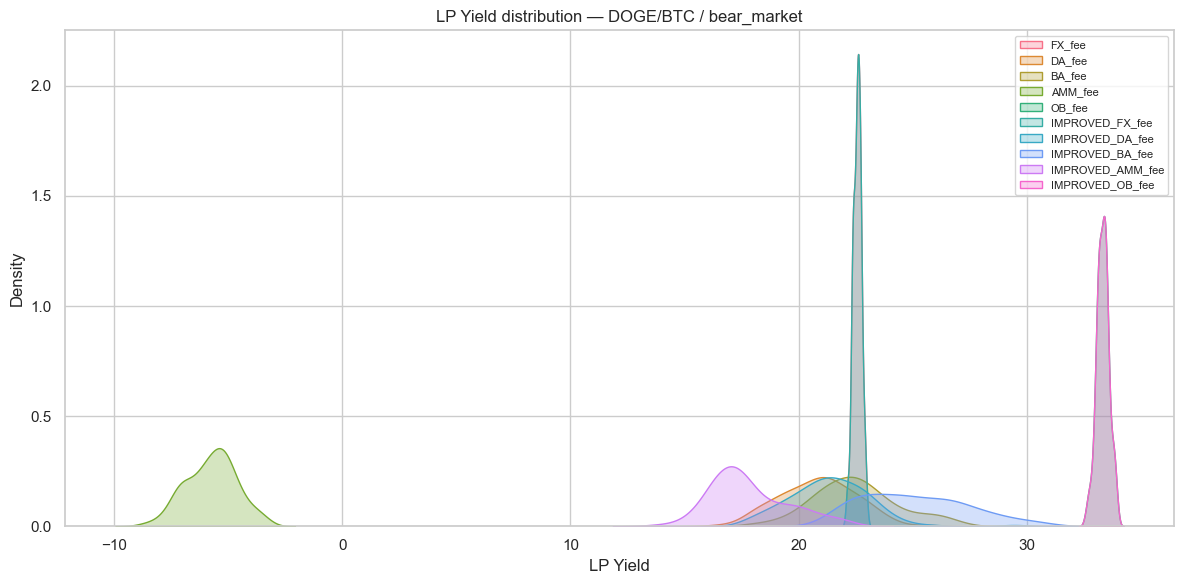

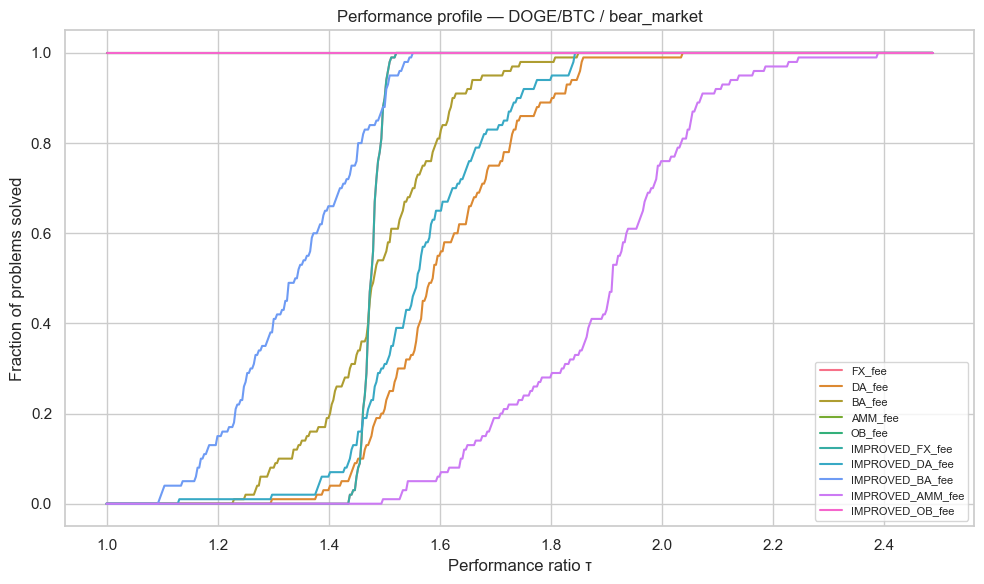

In [53]:
show_stats_for_pair_alias("DOGE/BTC", "bear_market")
plot_yield_stats("DOGE/BTC", "bear_market")
plot_performance_profile("DOGE/BTC", "bear_market")

### Export to CSV

In [54]:
import os

OUTPUT_DIR = "csv_export/synth_data_new_pairs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df.to_csv(f"{OUTPUT_DIR}/all_experiments_raw.csv", index=False)

for pair_name, month_alias in synth_desc.keys():
    safe_name = pair_name.replace("/", "_")
    show_stats_for_pair_alias(
        pair_name, month_alias, f"{OUTPUT_DIR}/{safe_name}_{month_alias}_stats.csv"
    )

print(f"Exported to {OUTPUT_DIR}/")


=== TUSD/USDC / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,73.03 ± 12.73,68.18 ± 5.97,1.23 ± 0.17,-8181.52 ± 322.39,723.36 ± 24.16,-56.74 ± 1.15,3753.12 ± 203.21,18.47 ± 0.90,-4141.12 ± 399.41
BA_fee,15.10 ± 5.51,18.02 ± 5.22,0.98 ± 0.22,-8179.77 ± 277.28,723.91 ± 24.46,-56.69 ± 0.78,4363.53 ± 169.05,27.33 ± 0.47,-4495.46 ± 260.12
DA_fee,9.38 ± 4.94,12.84 ± 4.73,0.83 ± 0.25,-8181.74 ± 282.59,723.29 ± 24.72,-56.75 ± 0.76,4402.95 ± 188.25,28.40 ± 0.52,-4438.60 ± 432.86
FX_fee,11.75 ± 4.98,14.81 ± 4.77,0.93 ± 0.23,-8186.14 ± 281.05,723.42 ± 24.66,-56.77 ± 0.81,4399.63 ± 157.63,28.06 ± 0.13,-4474.27 ± 342.50
IMPROVED_AMM_fee,0.53 ± 0.76,2.81 ± 1.38,0.05 ± 0.06,-8205.17 ± 339.33,723.27 ± 24.05,-56.93 ± 1.53,4167.82 ± 205.66,26.90 ± 1.19,-4541.61 ± 441.00
IMPROVED_BA_fee,13.85 ± 5.03,17.13 ± 4.96,0.93 ± 0.24,-8181.28 ± 278.88,723.56 ± 24.21,-56.73 ± 0.83,4363.76 ± 170.21,27.40 ± 0.49,-4498.94 ± 261.04
IMPROVED_DA_fee,9.24 ± 4.98,12.68 ± 4.76,0.83 ± 0.26,-8182.63 ± 286.50,723.23 ± 24.79,-56.76 ± 0.78,4404.30 ± 194.83,28.44 ± 0.56,-4437.27 ± 448.85
IMPROVED_FX_fee,11.75 ± 4.98,14.81 ± 4.77,0.93 ± 0.23,-8186.14 ± 281.05,723.42 ± 24.66,-56.77 ± 0.81,4399.63 ± 157.63,28.06 ± 0.13,-4474.27 ± 342.50
IMPROVED_OB_fee,7.55 ± 4.35,9.56 ± 4.37,0.91 ± 0.35,-8172.36 ± 286.26,723.35 ± 24.51,-56.68 ± 0.66,4423.31 ± 185.04,29.04 ± 0.41,-4489.31 ± 332.07



=== TUSD/USDC / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,53.74 ± 9.26,57.66 ± 6.14,1.09 ± 0.16,-8189.80 ± 311.23,722.53 ± 24.60,-56.87 ± 1.07,3824.76 ± 195.08,19.78 ± 0.94,-4231.29 ± 331.17
BA_fee,12.90 ± 4.95,15.50 ± 5.03,0.98 ± 0.22,-8173.49 ± 301.56,723.54 ± 24.98,-56.67 ± 0.75,4293.37 ± 161.10,27.27 ± 0.39,-4477.24 ± 249.82
DA_fee,7.26 ± 3.95,10.26 ± 4.66,0.83 ± 0.27,-8171.90 ± 288.22,723.39 ± 24.48,-56.67 ± 0.72,4367.55 ± 175.73,28.57 ± 0.43,-4493.20 ± 327.61
FX_fee,9.43 ± 4.11,12.03 ± 4.53,0.93 ± 0.27,-8173.04 ± 292.46,723.29 ± 24.49,-56.68 ± 0.68,4344.63 ± 155.22,28.14 ± 0.12,-4496.12 ± 276.42
IMPROVED_AMM_fee,0.41 ± 0.59,2.34 ± 1.46,0.04 ± 0.07,-8198.08 ± 348.27,722.80 ± 24.08,-56.91 ± 1.61,4157.77 ± 206.10,27.12 ± 1.25,-4546.46 ± 381.29
IMPROVED_BA_fee,11.92 ± 4.82,14.59 ± 4.85,0.93 ± 0.26,-8178.21 ± 301.01,723.48 ± 24.59,-56.71 ± 0.84,4296.84 ± 161.96,27.34 ± 0.41,-4484.99 ± 257.14
IMPROVED_DA_fee,7.23 ± 3.94,10.22 ± 4.62,0.83 ± 0.27,-8175.02 ± 289.26,723.40 ± 24.48,-56.69 ± 0.72,4370.91 ± 176.89,28.60 ± 0.44,-4497.98 ± 324.90
IMPROVED_FX_fee,9.43 ± 4.11,12.03 ± 4.53,0.93 ± 0.27,-8173.04 ± 292.46,723.29 ± 24.49,-56.68 ± 0.68,4344.63 ± 155.22,28.14 ± 0.12,-4496.12 ± 276.42
IMPROVED_OB_fee,6.64 ± 4.08,8.51 ± 4.68,0.92 ± 0.35,-8182.66 ± 287.60,723.70 ± 24.82,-56.72 ± 0.64,4392.57 ± 173.36,29.00 ± 0.45,-4533.95 ± 258.17



=== TUSD/USDC / calm_market ===


...


=== DOGE/BTC / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,3143.11 ± 458.47,37.22 ± 5.91,26.15 ± 0.66,-8156.34 ± 350.01,723.14 ± 24.39,-56.85 ± 1.54,1107.68 ± 495.36,4.31 ± 2.06,2715.87 ± 8892.55
BA_fee,887.16 ± 252.33,60.50 ± 13.13,10.55 ± 2.38,-8183.15 ± 298.57,723.28 ± 23.50,-57.03 ± 1.19,5600.39 ± 698.39,24.65 ± 2.99,35.16 ± 8104.89
DA_fee,953.69 ± 263.13,56.52 ± 9.31,11.01 ± 2.13,-8168.21 ± 318.43,723.31 ± 24.65,-56.91 ± 1.04,5294.09 ± 514.24,23.10 ± 2.13,712.22 ± 8965.05
FX_fee,891.24 ± 153.28,53.56 ± 8.38,10.17 ± 0.64,-8166.72 ± 300.05,722.95 ± 24.45,-56.94 ± 1.07,5555.91 ± 284.85,24.06 ± 0.52,385.88 ± 8762.46
IMPROVED_AMM_fee,32.65 ± 15.06,29.73 ± 7.21,0.38 ± 0.17,-8170.35 ± 332.24,722.95 ± 24.53,-56.97 ± 1.83,4782.97 ± 335.97,20.85 ± 1.65,-570.15 ± 8411.83
IMPROVED_BA_fee,514.52 ± 208.67,59.60 ± 12.99,6.25 ± 2.50,-8186.53 ± 300.92,723.13 ± 23.67,-57.06 ± 1.24,5968.04 ± 687.22,26.38 ± 2.85,-302.04 ± 8178.09
IMPROVED_DA_fee,803.90 ± 187.85,56.50 ± 9.28,9.31 ± 1.34,-8168.47 ± 319.36,723.28 ± 24.69,-56.91 ± 1.04,5442.79 ± 449.58,23.75 ± 1.76,564.17 ± 8902.89
IMPROVED_FX_fee,891.24 ± 153.28,53.56 ± 8.38,10.17 ± 0.64,-8166.72 ± 300.05,722.95 ± 24.45,-56.94 ± 1.07,5555.91 ± 284.85,24.06 ± 0.52,385.88 ± 8762.46
IMPROVED_OB_fee,167.56 ± 34.27,76.75 ± 14.06,2.33 ± 0.21,-8177.81 ± 306.60,723.60 ± 25.89,-56.96 ± 0.98,6777.68 ± 471.69,31.43 ± 0.42,-264.18 ± 8528.55



=== DOGE/BTC / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,6096.36 ± 627.36,100.61 ± 10.22,22.04 ± 0.66,-8120.94 ± 342.14,722.35 ± 24.90,-56.90 ± 1.61,-1512.28 ± 693.91,-3.54 ± 1.47,2656.50 ± 10196.77
BA_fee,1578.39 ± 262.99,134.12 ± 17.49,9.01 ± 1.37,-8140.58 ± 319.30,722.78 ± 24.70,-56.98 ± 1.08,7304.24 ± 901.41,22.91 ± 2.41,-2132.88 ± 9452.48
DA_fee,1394.46 ± 314.22,147.56 ± 20.93,7.50 ± 1.58,-8148.65 ± 324.13,722.70 ± 24.54,-57.05 ± 1.13,7390.74 ± 765.06,22.43 ± 1.74,-1600.21 ± 10809.71
FX_fee,815.29 ± 141.00,184.46 ± 19.64,4.16 ± 0.68,-8151.08 ± 307.40,723.29 ± 25.01,-57.02 ± 1.04,8229.20 ± 493.72,24.25 ± 0.34,-2195.37 ± 10313.89
IMPROVED_AMM_fee,120.99 ± 34.95,63.77 ± 9.90,0.71 ± 0.20,-8177.53 ± 341.56,722.90 ± 24.76,-57.24 ± 1.77,5851.00 ± 511.52,18.62 ± 1.72,-3527.79 ± 10368.14
IMPROVED_BA_fee,800.45 ± 195.21,131.16 ± 17.27,4.62 ± 0.96,-8160.60 ± 321.53,723.21 ± 24.87,-57.09 ± 1.09,8064.35 ± 870.18,25.55 ± 2.43,-2918.04 ± 9530.59
IMPROVED_DA_fee,1291.52 ± 323.25,146.22 ± 22.64,7.05 ± 2.05,-8152.79 ± 327.67,722.66 ± 24.57,-57.08 ± 1.15,7502.98 ± 720.42,22.87 ± 1.46,-1809.15 ± 10667.98
IMPROVED_FX_fee,815.29 ± 141.00,184.46 ± 19.64,4.16 ± 0.68,-8151.08 ± 307.40,723.29 ± 25.01,-57.02 ± 1.04,8229.20 ± 493.72,24.25 ± 0.34,-2195.37 ± 10313.89
IMPROVED_OB_fee,479.50 ± 69.07,143.83 ± 18.05,3.33 ± 0.25,-8158.09 ± 314.43,723.56 ± 25.19,-57.05 ± 0.94,9362.66 ± 714.59,32.60 ± 0.39,-2807.26 ± 10260.97


Exported to csv_export/synth_data_new_pairs/
